<a href="https://colab.research.google.com/github/maheshisewwandisamaraweera/image-authentication-project/blob/maheshi/notebooks/confidence_score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
base_path = "/content/drive/MyDrive/image-authentication-project/data"

actual_path = base_path + "/actual/actual_images"
edited_path = base_path + "/edited"
ai_path = base_path + "/ai_generated"

In [3]:
import os

print("Actual exists:", os.path.exists(actual_path))
print(actual_path)

Actual exists: False
/content/drive/MyDrive/image-authentication-project/data/actual/actual_images


In [4]:
os.path.exists("/content/drive/MyDrive/image-authentication-project/data/actual/actual_images")
# False

False

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
import os

print(os.path.exists("/content/drive"))
print(os.listdir("/content/drive"))

True
['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [9]:
import os

base = "/content/drive/MyDrive/image-authentication-project"

print(os.listdir(base))

['README.md', '.gitignore', 'train.py', 'src', 'notebooks', '.git', 'data', 'models']


In [10]:
data_path = base + "/data"

print(os.listdir(data_path))

['actual', 'edited', 'ai_generated']


In [11]:
print(os.listdir(data_path + "/actual/actual_images")[:5])

['B011-102.png', 'B004-045.png', 'A018-056.png', 'A024-034.png', 'A025-051.png']


In [13]:
import cv2
import numpy as np

categories = {
    data_path + "/actual/actual_images": 0,   # REAL
    data_path + "/edited": 1,                # EDITED
    data_path + "/ai_generated": 2           # AI
}

X = []
y = []

for folder, label in categories.items():
    for img_name in os.listdir(folder):

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (128, 128))

        X.append(img)
        y.append(label)

X = np.array(X) / 255.0
y = np.array(y)

print("Dataset ready:", X.shape, y.shape)

Dataset ready: (567, 128, 128, 3) (567,)


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X, y, epochs=10, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.3907 - loss: 1.7955 - val_accuracy: 0.0000e+00 - val_loss: 2.2817
Epoch 2/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 13s 832ms/step - accuracy: 0.4305 - loss: 1.0447 - val_accuracy: 0.0000e+00 - val_loss: 1.7891
Epoch 3/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 944ms/step - accuracy: 0.4967 - loss: 0.9040 - val_accuracy: 0.0088 - val_loss: 2.4891
Epoch 4/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 15s 991ms/step - accuracy: 0.6269 - loss: 0.7796 - val_accuracy: 0.0088 - val_loss: 2.6652
Epoch 5/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 943ms/step - accuracy: 0.7682 - loss: 0.6936 - val_accuracy: 0.0702 - val_loss: 1.7178
Epoch 6/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 20s 920ms/step - accuracy: 0.8322 - loss: 0.4628 - val_accuracy: 0.1228 - val_loss: 2.0078
Epoch 7/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 955ms/step - accuracy: 0.8985 - loss: 0.2976 - val_accuracy: 0.0965 - val_loss: 3.5048
Epoch 8/10
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 933ms/step - accuracy: 0.9294 - loss: 0.2015 - val

In [15]:
def predict_image(path):

    img = cv2.imread(path)
    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img)
    class_id = np.argmax(pred)

    labels = ["REAL", "EDITED", "AI GENERATED"]

    print("Prediction:", labels[class_id])

In [17]:
import os

print(os.listdir(data_path + "/ai_generated")[:10])

['B011-102.png', 'B004-045.png', 'A018-056.png', 'A024-034.png', 'A025-051.png', 'A042-459.png', 'A027-106.png', 'B015-017.png', 'A008-229.png', 'A005-023.png']


In [18]:
test_img = os.path.join(data_path + "/ai_generated",
                        os.listdir(data_path + "/ai_generated")[0])

In [19]:
def predict_image(path):

    img = cv2.imread(path)

    if img is None:
        print("Error: Image not found or cannot be read:", path)
        return

    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img)
    class_id = np.argmax(pred)

    labels = ["REAL", "EDITED", "AI GENERATED"]

    print("Prediction:", labels[class_id])

In [20]:
predict_image(test_img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
Prediction: AI GENERATED


In [21]:
import cv2
import numpy as np

def predict_image(path):

    img = cv2.imread(path)

    if img is None:
        print("❌ Cannot read:", path)
        return

    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img)
    class_id = np.argmax(pred)

    labels = ["REAL", "EDITED", "AI GENERATED"]

    print("Image:", path)
    print("Prediction:", labels[class_id])
    print("-"*50)

In [22]:
folders = {
    "REAL": data_path + "/actual/actual_images",
    "EDITED": data_path + "/edited",
    "AI GENERATED": data_path + "/ai_generated"
}

for true_label, folder in folders.items():

    print("\n==============================")
    print("Testing category:", true_label)
    print("==============================\n")

    files = os.listdir(folder)[:3]  # test first 3 images

    for file in files:
        img_path = os.path.join(folder, file)
        predict_image(img_path)


Testing category: REAL

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/actual/actual_images/B011-102.png
Prediction: REAL
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/actual/actual_images/B004-045.png
Prediction: REAL
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/actual/actual_images/A018-056.png
Prediction: REAL
--------------------------------------------------

Testing category: EDITED

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/edited/B011-102.png
Prediction: EDITED
--------------------------------------------------
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Image: /content/drive/MyDrive/image-authentication-project/data/edited/B004-045.png
Prediction: EDITED
---

In [23]:
import cv2
import numpy as np

def predict_image_with_confidence(path):

    img = cv2.imread(path)

    if img is None:
        print("❌ Cannot read image:", path)
        return

    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img)[0]   # probabilities
    class_id = np.argmax(pred)
    confidence = float(np.max(pred)) * 100

    labels = ["REAL", "EDITED", "AI GENERATED"]
    label = labels[class_id]

    print("Prediction:", label)
    print(f"Confidence: {confidence:.2f}%")

    return label, confidence

In [24]:
import matplotlib.pyplot as plt

def show_confidence_bar(label, confidence):

    colors = {
        "REAL": "green",
        "EDITED": "orange",
        "AI GENERATED": "red"
    }

    plt.figure(figsize=(6,3))
    plt.barh([label], [confidence], color=colors[label])
    plt.xlim(0, 100)
    plt.xlabel("Confidence (%)")
    plt.title("Image Authentication Result")
    plt.show()

In [25]:
def predict_and_visualize(path):

    label, confidence = predict_image_with_confidence(path)
    show_confidence_bar(label, confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Prediction: AI GENERATED
Confidence: 94.22%


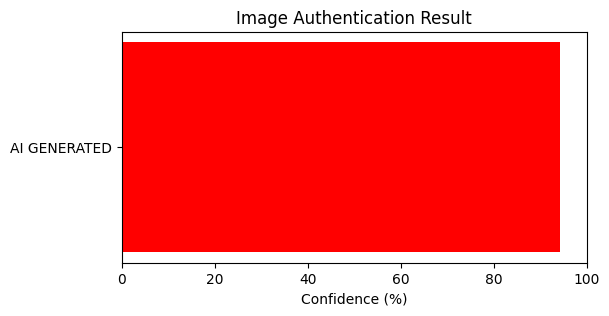

In [26]:
test_img = os.path.join(data_path + "/ai_generated",
                        os.listdir(data_path + "/ai_generated")[0])

predict_and_visualize(test_img)

In [27]:
model
data_path

'/content/drive/MyDrive/image-authentication-project/data'

In [28]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

folders = {
    "REAL": data_path + "/actual/actual_images",
    "EDITED": data_path + "/edited",
    "AI GENERATED": data_path + "/ai_generated"
}

labels = ["REAL", "EDITED", "AI GENERATED"]

def predict_image(img):

    img = cv2.resize(img, (128,128))
    img = np.expand_dims(img/255.0, axis=0)

    pred = model.predict(img, verbose=0)[0]
    class_id = np.argmax(pred)
    confidence = float(np.max(pred)) * 100

    return labels[class_id], confidence

In [29]:
def show_bar(label, confidence):

    color_map = {
        "REAL": "green",
        "EDITED": "orange",
        "AI GENERATED": "red"
    }

    plt.figure(figsize=(5,2))
    plt.barh([label], [confidence], color=color_map[label])
    plt.xlim(0, 100)
    plt.xlabel("Confidence (%)")
    plt.title("Prediction Result")
    plt.show()


ACTUAL CATEGORY: REAL

File: B011-102.png
Predicted: REAL
Confidence: 98.94 %


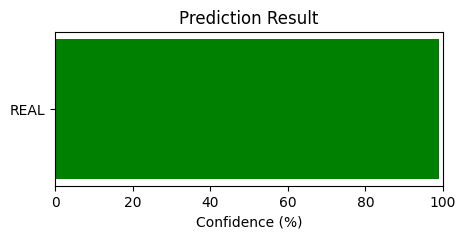

File: B004-045.png
Predicted: REAL
Confidence: 100.0 %


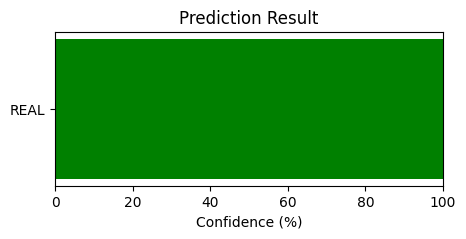

File: A018-056.png
Predicted: REAL
Confidence: 99.92 %


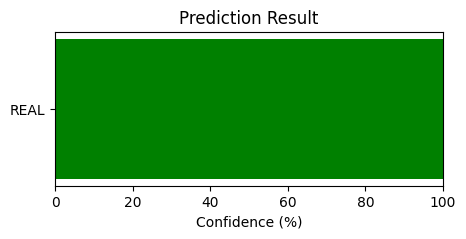

File: A024-034.png
Predicted: REAL
Confidence: 100.0 %


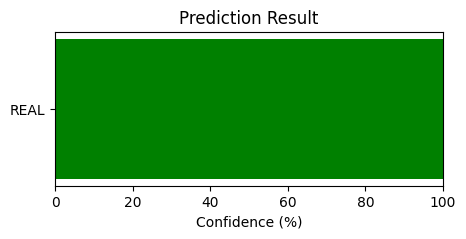

File: A025-051.png
Predicted: REAL
Confidence: 99.87 %


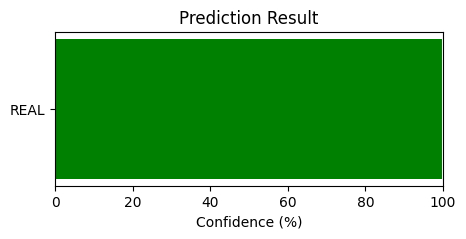

File: A042-459.png
Predicted: REAL
Confidence: 100.0 %


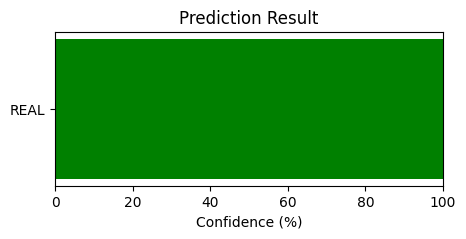

File: A027-106.png
Predicted: REAL
Confidence: 100.0 %


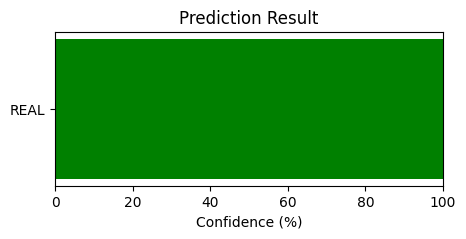

File: B015-017.png
Predicted: REAL
Confidence: 98.57 %


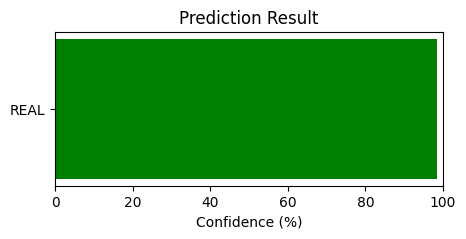

File: A008-229.png
Predicted: REAL
Confidence: 99.57 %


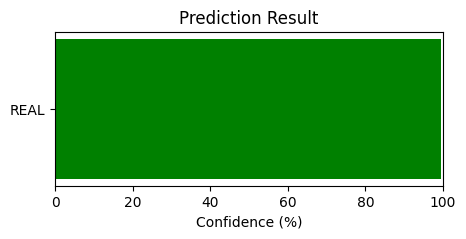

File: A005-023.png
Predicted: REAL
Confidence: 95.55 %


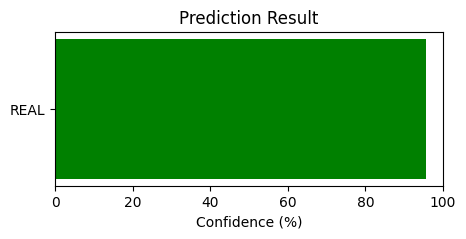

File: B022-045.png
Predicted: REAL
Confidence: 100.0 %


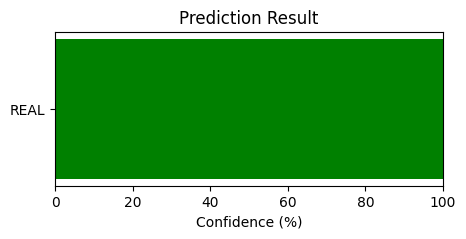

File: B005-051.png
Predicted: REAL
Confidence: 99.18 %


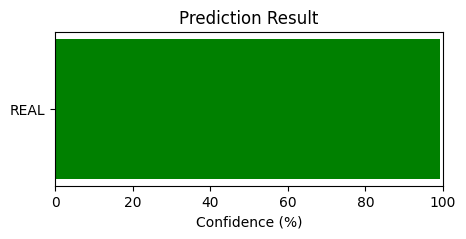

File: A035-116.png
Predicted: REAL
Confidence: 99.91 %


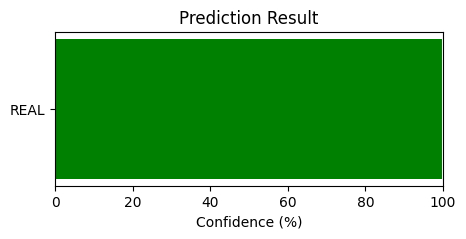

File: A037-005.png
Predicted: REAL
Confidence: 99.84 %


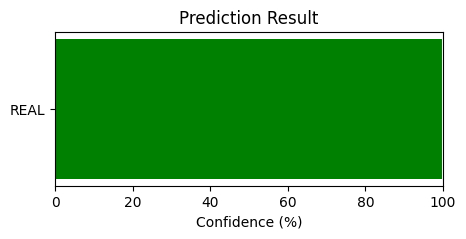

File: A013-004.png
Predicted: REAL
Confidence: 98.36 %


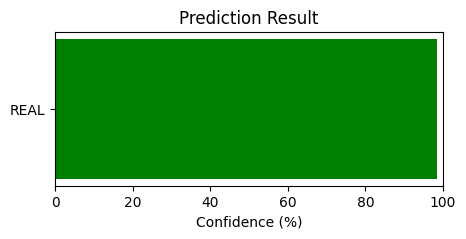

File: A026-008.png
Predicted: EDITED
Confidence: 66.26 %


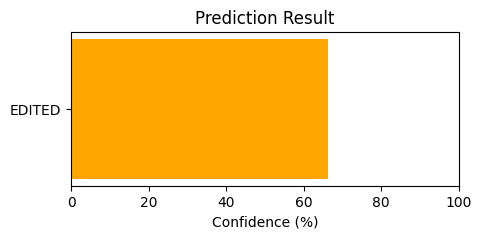

File: A050-200.png
Predicted: REAL
Confidence: 99.3 %


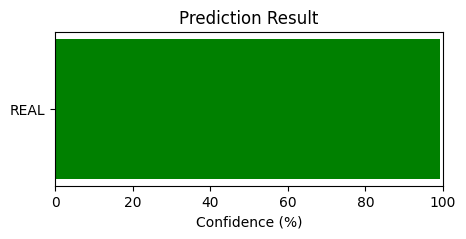

File: A049-021.png
Predicted: REAL
Confidence: 98.79 %


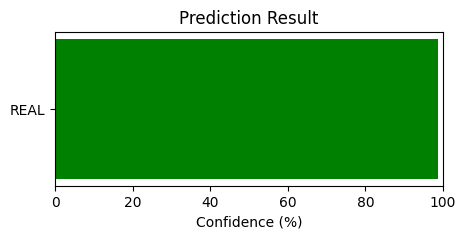

File: A033-052.png
Predicted: REAL
Confidence: 99.91 %


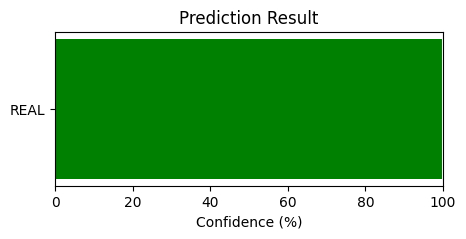

File: A023-033.png
Predicted: REAL
Confidence: 81.09 %


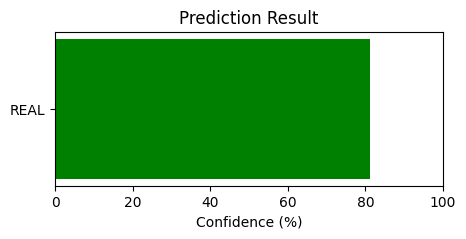

File: A045-215.png
Predicted: REAL
Confidence: 98.57 %


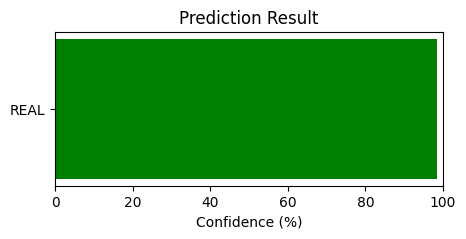

File: B001-047.png
Predicted: REAL
Confidence: 92.72 %


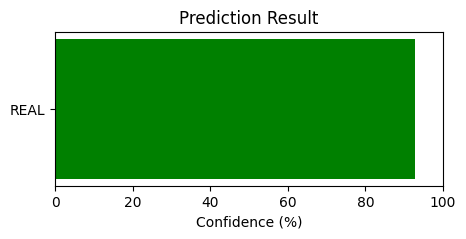

File: A001-010.png
Predicted: REAL
Confidence: 99.57 %


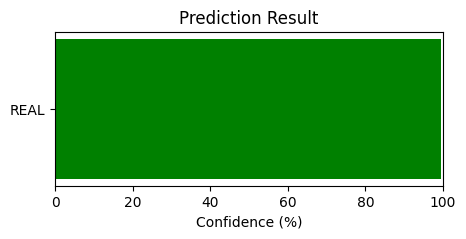

File: A003-032.png
Predicted: REAL
Confidence: 63.9 %


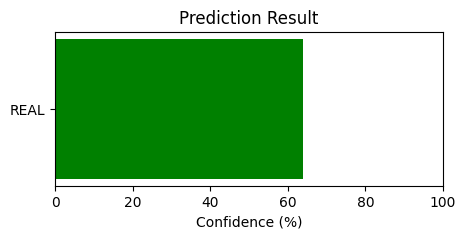

File: A048-135.png
Predicted: REAL
Confidence: 98.33 %


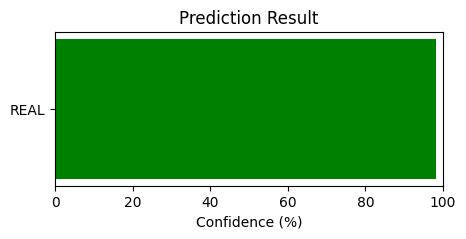

File: A031-024.png
Predicted: REAL
Confidence: 86.41 %


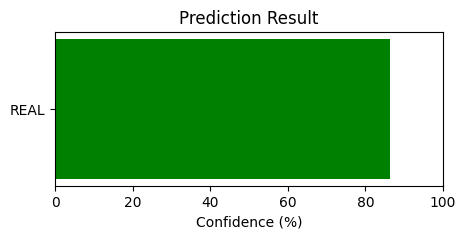

File: B007-056.png
Predicted: REAL
Confidence: 96.05 %


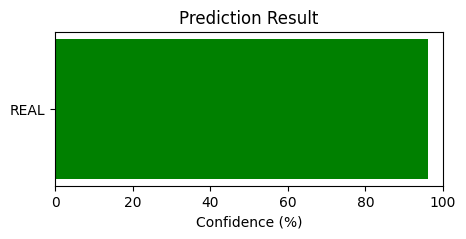

File: B021-354.png
Predicted: REAL
Confidence: 99.32 %


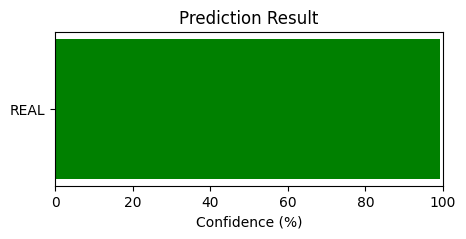

File: A017-047.png
Predicted: REAL
Confidence: 100.0 %


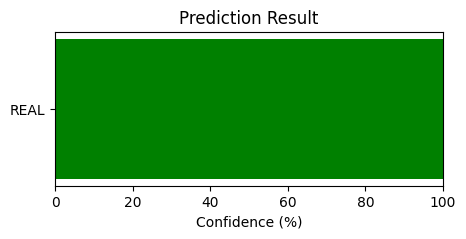

File: B017-110.png
Predicted: REAL
Confidence: 100.0 %


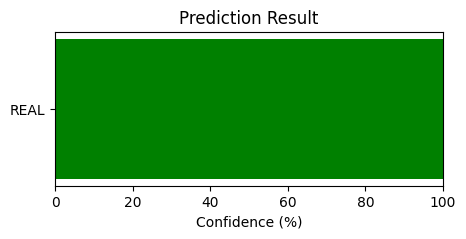

File: A040-126.png
Predicted: REAL
Confidence: 99.93 %


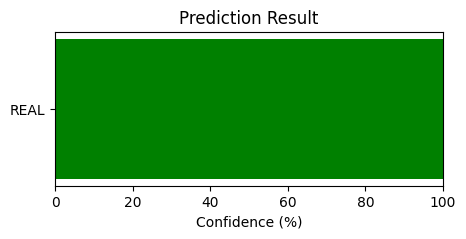

File: B031-053.png
Predicted: REAL
Confidence: 99.86 %


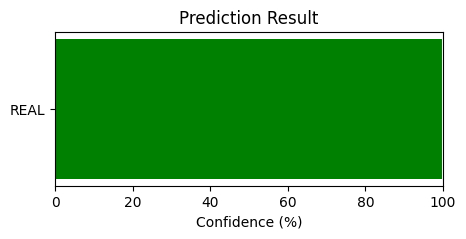

File: C032-006.png
Predicted: REAL
Confidence: 99.99 %


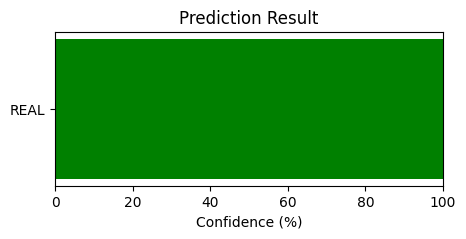

File: C030-033.png
Predicted: REAL
Confidence: 100.0 %


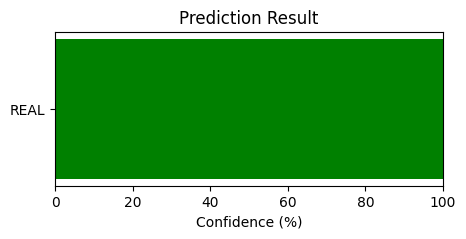

File: B032-047.png
Predicted: REAL
Confidence: 99.96 %


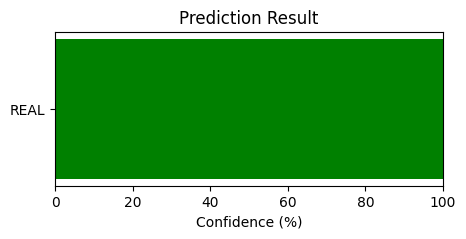

File: C020-055.png
Predicted: AI GENERATED
Confidence: 48.86 %


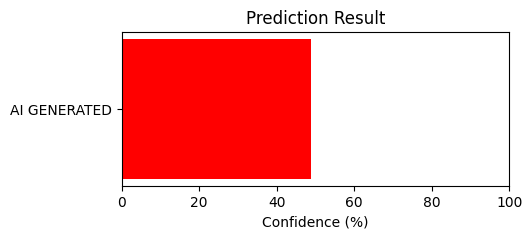

File: C018-017.png
Predicted: REAL
Confidence: 91.02 %


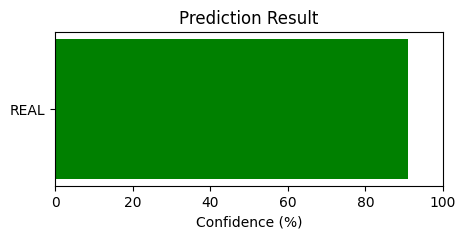

File: C001-103.png
Predicted: REAL
Confidence: 100.0 %


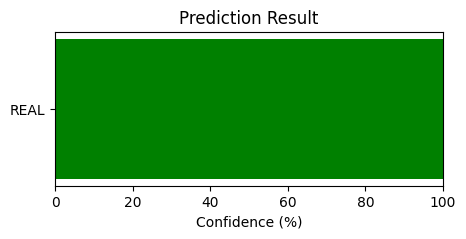

File: C014-038.png
Predicted: REAL
Confidence: 100.0 %


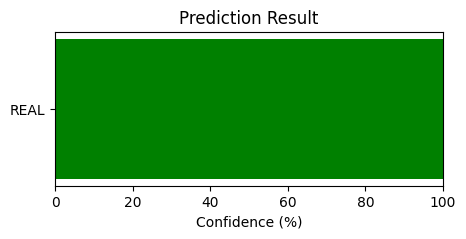

File: C006-121.png
Predicted: REAL
Confidence: 76.32 %


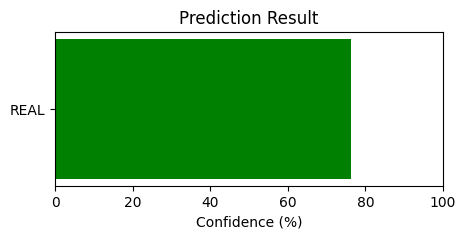

File: C038-004.png
Predicted: REAL
Confidence: 99.6 %


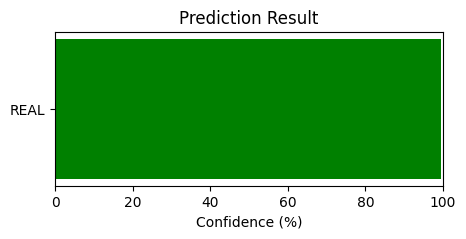

File: C025-040.png
Predicted: REAL
Confidence: 71.25 %


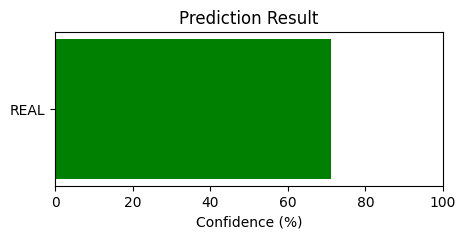

File: B046-304.png
Predicted: REAL
Confidence: 83.35 %


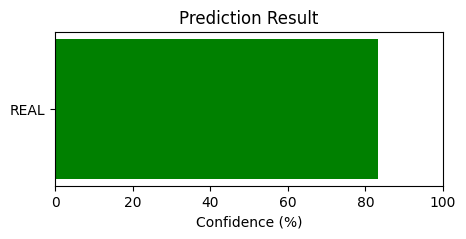

File: B044-136.png
Predicted: REAL
Confidence: 99.83 %


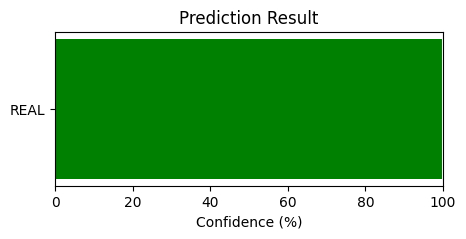

File: B048-131.png
Predicted: REAL
Confidence: 100.0 %


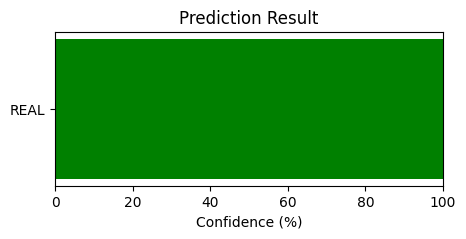

File: C002-134.png
Predicted: REAL
Confidence: 100.0 %


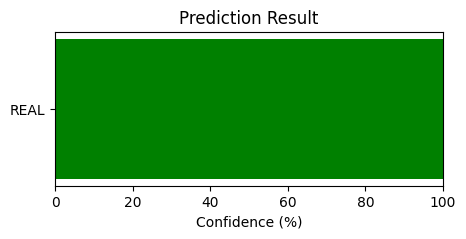

File: C051-022.png
Predicted: REAL
Confidence: 99.93 %


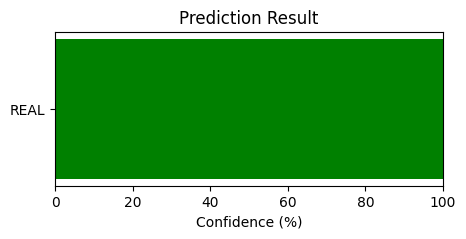

File: B029-357.png
Predicted: REAL
Confidence: 99.94 %


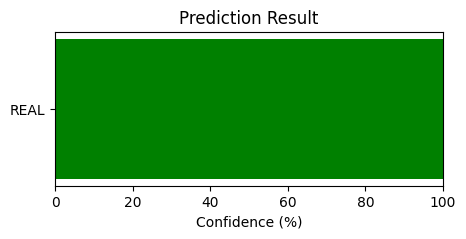

File: C005-005.png
Predicted: AI GENERATED
Confidence: 60.6 %


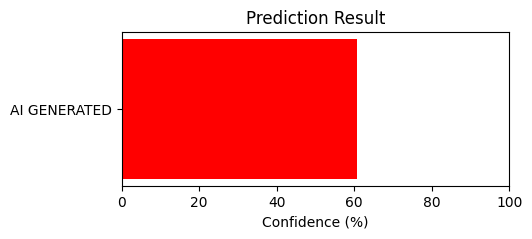

File: C044-034.png
Predicted: REAL
Confidence: 99.82 %


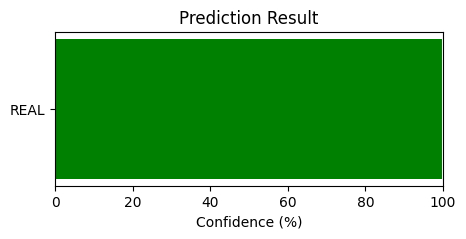

File: B039-500.png
Predicted: REAL
Confidence: 97.53 %


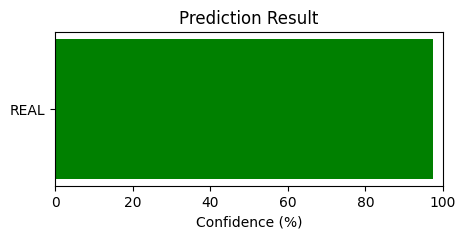

File: B040-037.png
Predicted: REAL
Confidence: 99.78 %


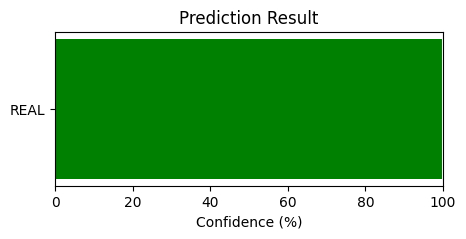

File: C023-016.png
Predicted: REAL
Confidence: 86.15 %


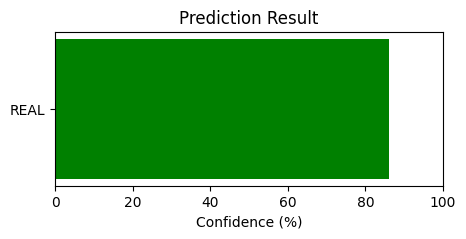

File: B025-024.png
Predicted: REAL
Confidence: 88.74 %


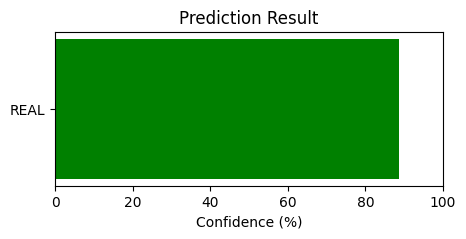

File: C003-005.png
Predicted: REAL
Confidence: 95.47 %


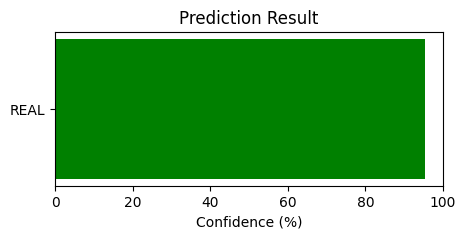

File: C015-355.png
Predicted: REAL
Confidence: 99.66 %


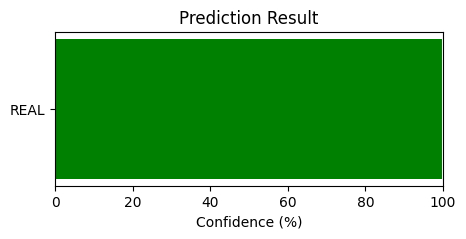

File: C031-041.png
Predicted: REAL
Confidence: 99.68 %


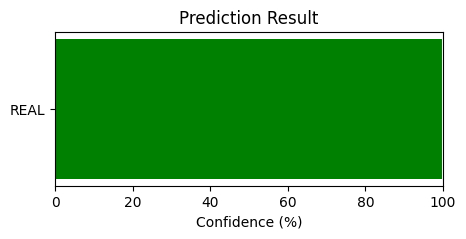

File: C016-039.png
Predicted: REAL
Confidence: 99.67 %


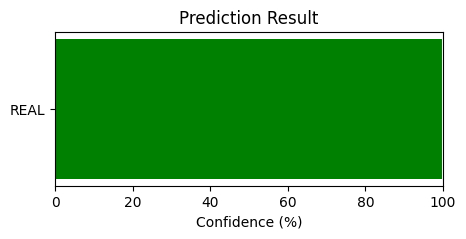

File: C013-302.png
Predicted: REAL
Confidence: 93.25 %


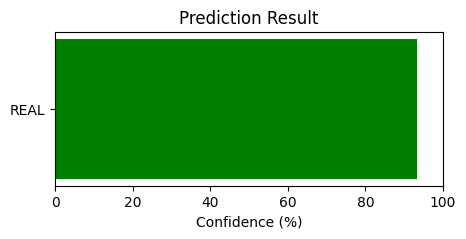

File: B028-034.png
Predicted: REAL
Confidence: 98.92 %


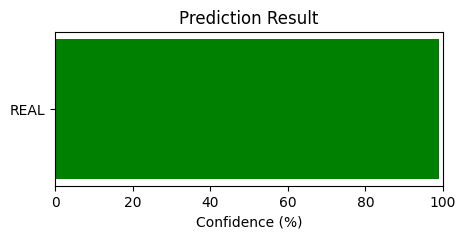

File: C049-005.png
Predicted: REAL
Confidence: 98.5 %


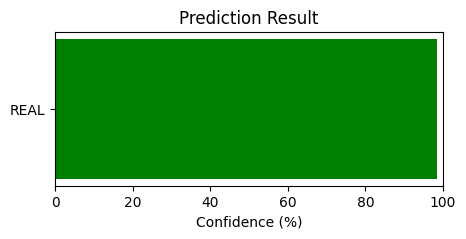

File: B035-247.png
Predicted: REAL
Confidence: 99.99 %


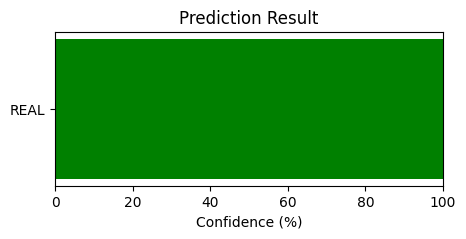

File: C021-038.png
Predicted: REAL
Confidence: 100.0 %


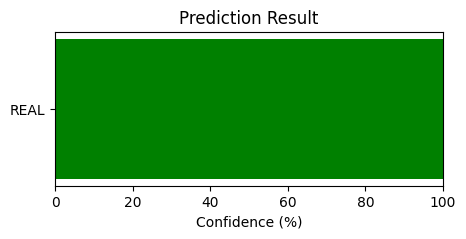

File: B023-048.png
Predicted: REAL
Confidence: 99.22 %


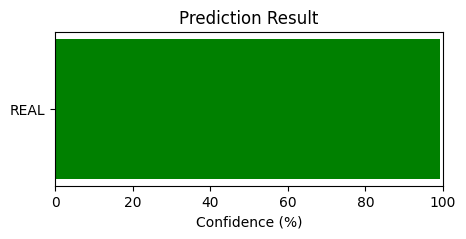

File: C029-029.png
Predicted: REAL
Confidence: 99.99 %


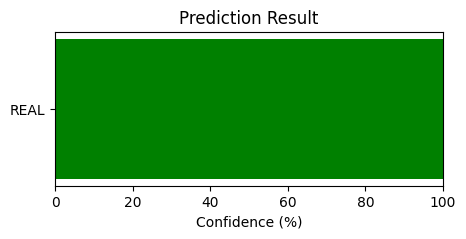

File: C009-009.png
Predicted: REAL
Confidence: 96.72 %


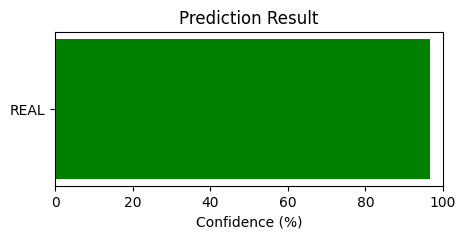

File: B037-012.png
Predicted: REAL
Confidence: 99.97 %


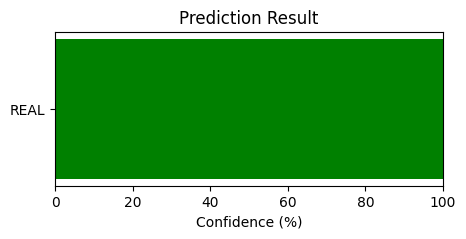

File: B049-327.png
Predicted: EDITED
Confidence: 54.03 %


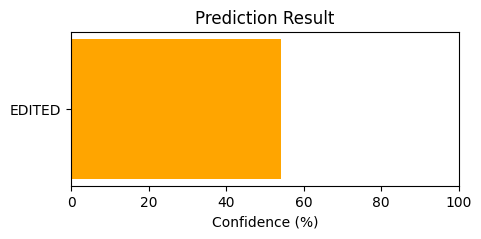

File: C010-120.png
Predicted: REAL
Confidence: 92.97 %


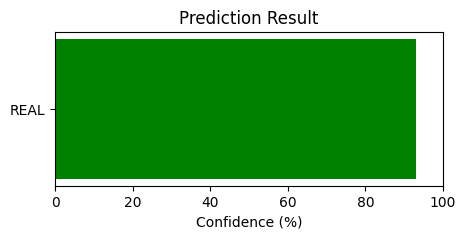

File: C052-041.png
Predicted: REAL
Confidence: 98.47 %


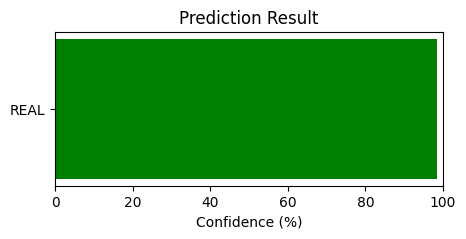

File: B043-118.png
Predicted: REAL
Confidence: 100.0 %


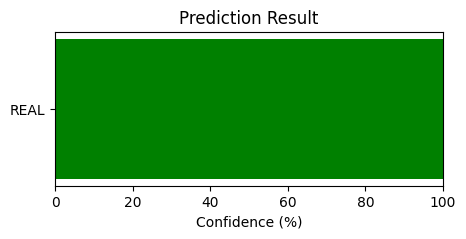

File: C027-105.png
Predicted: REAL
Confidence: 99.99 %


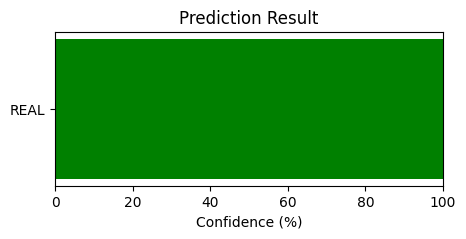

File: C007-209.png
Predicted: REAL
Confidence: 100.0 %


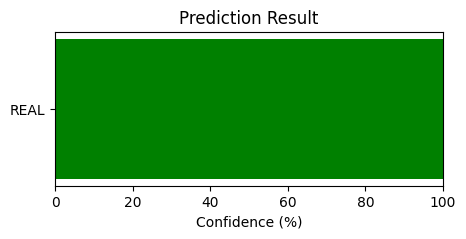

File: B026-215.png
Predicted: REAL
Confidence: 99.77 %


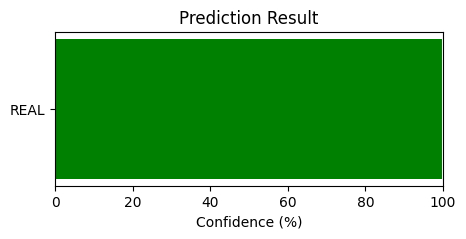

File: C028-106.png
Predicted: REAL
Confidence: 99.85 %


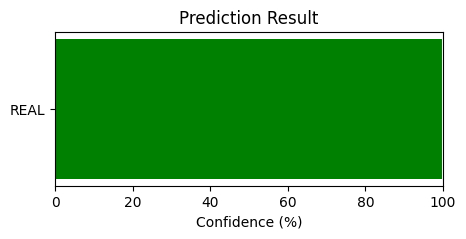

File: C022-159.png
Predicted: REAL
Confidence: 100.0 %


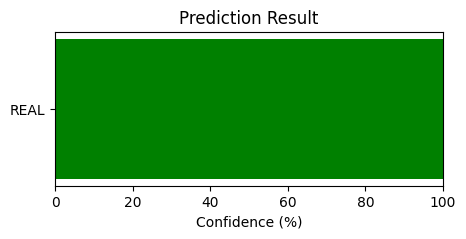

File: C042-301.png
Predicted: REAL
Confidence: 100.0 %


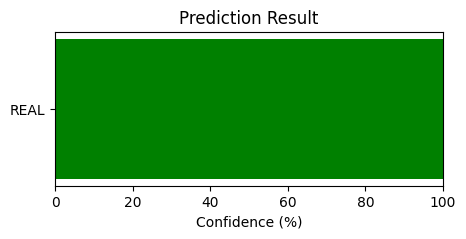

File: C008-011.png
Predicted: REAL
Confidence: 90.88 %


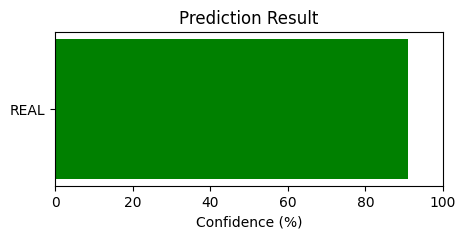

File: E029-004.png
Predicted: REAL
Confidence: 99.84 %


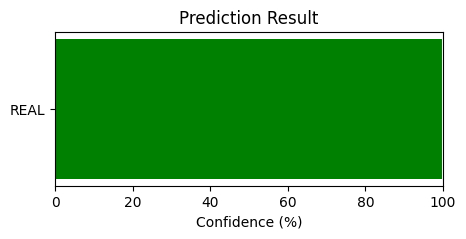

File: D010-142.png
Predicted: REAL
Confidence: 97.49 %


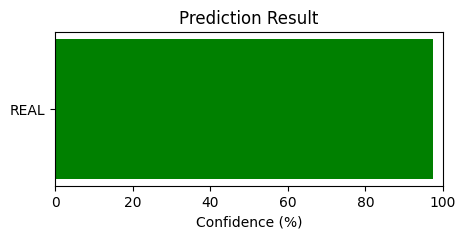

File: D020-114.png
Predicted: REAL
Confidence: 100.0 %


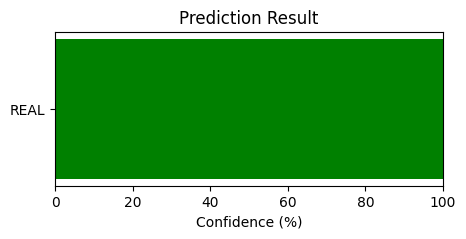

File: E032-020.png
Predicted: REAL
Confidence: 91.34 %


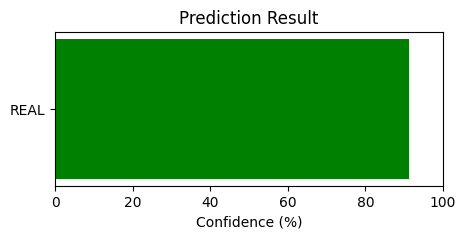

File: D016-121.png
Predicted: REAL
Confidence: 97.55 %


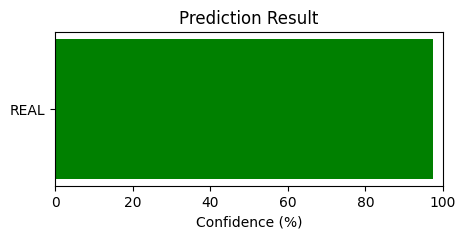

File: E030-036.png
Predicted: REAL
Confidence: 99.83 %


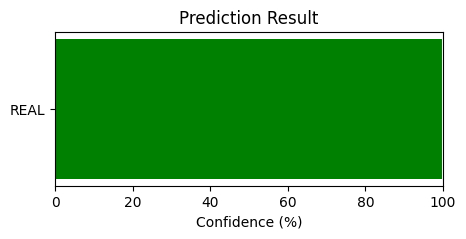

File: D031-112.png
Predicted: REAL
Confidence: 100.0 %


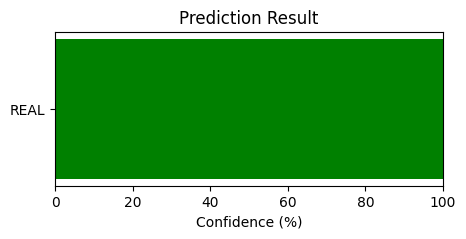

File: E004-005.png
Predicted: REAL
Confidence: 84.41 %


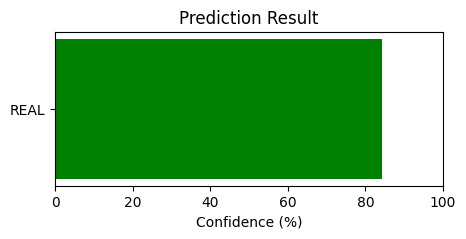

File: D004-015.png
Predicted: REAL
Confidence: 99.6 %


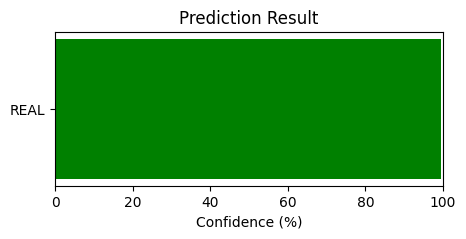

File: E002-010.png
Predicted: REAL
Confidence: 100.0 %


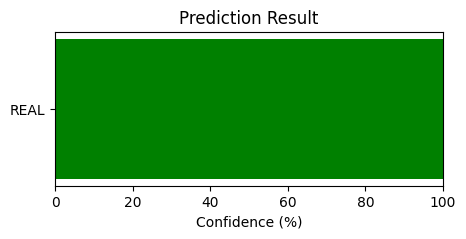

File: D027-036.png
Predicted: REAL
Confidence: 100.0 %


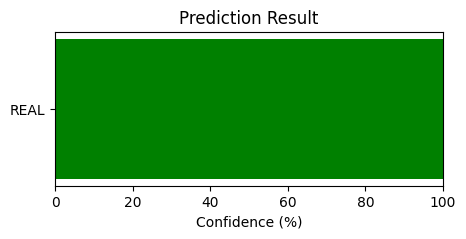

File: D012-025.png
Predicted: REAL
Confidence: 99.99 %


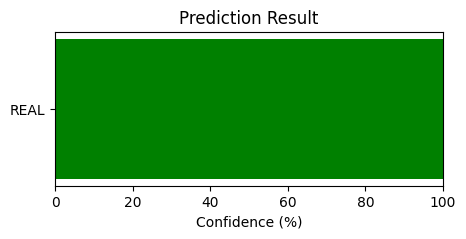

File: D048-025.png
Predicted: REAL
Confidence: 99.61 %


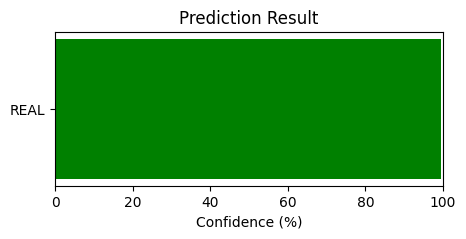

File: D022-114.png
Predicted: REAL
Confidence: 95.03 %


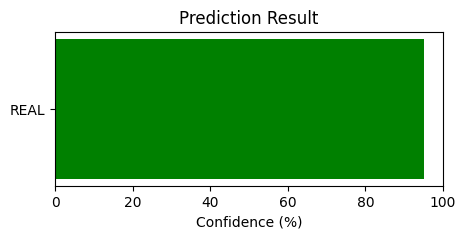

File: E011-009.png
Predicted: REAL
Confidence: 100.0 %


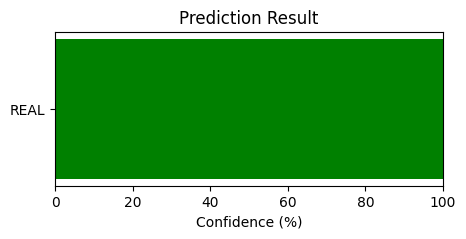

File: D019-008.png
Predicted: REAL
Confidence: 99.98 %


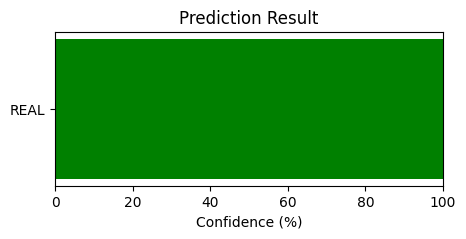

File: D006-331.png
Predicted: REAL
Confidence: 100.0 %


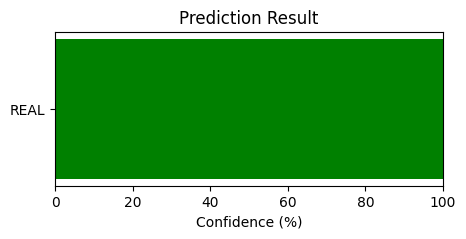

File: D007-030.png
Predicted: REAL
Confidence: 99.93 %


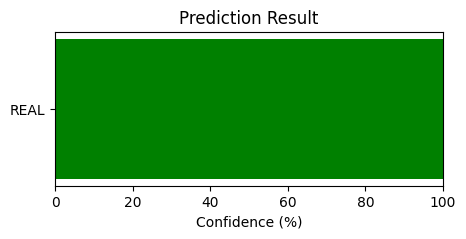

File: D017-047.png
Predicted: REAL
Confidence: 100.0 %


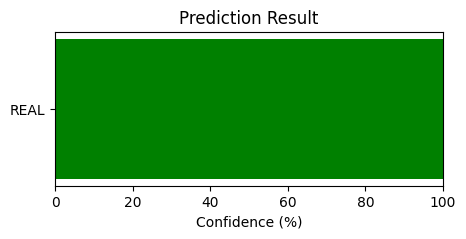

File: D045-215.png
Predicted: REAL
Confidence: 100.0 %


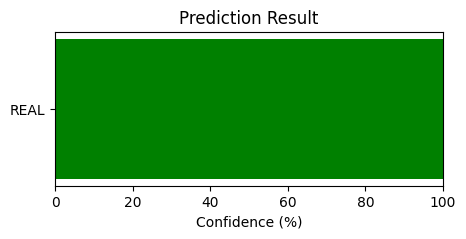

File: E012-009.png
Predicted: REAL
Confidence: 97.85 %


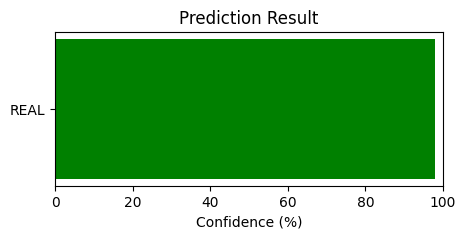

File: D046-053.png
Predicted: REAL
Confidence: 99.83 %


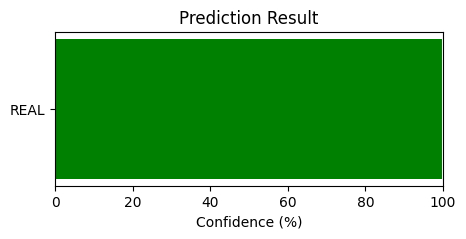

File: E019-027.png
Predicted: REAL
Confidence: 100.0 %


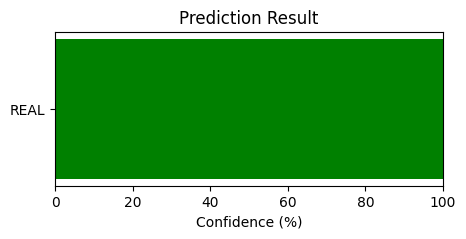

File: D026-037.png
Predicted: REAL
Confidence: 98.64 %


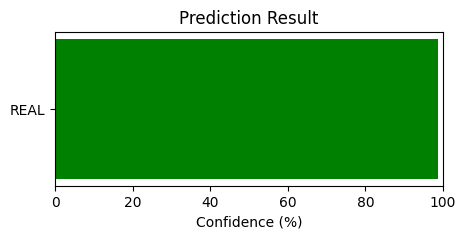

File: E013-015.png
Predicted: REAL
Confidence: 99.66 %


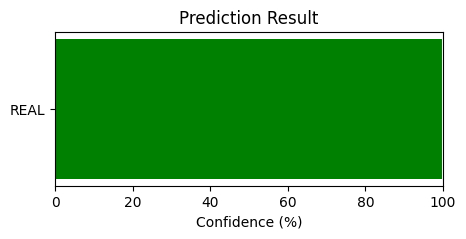

File: E027-003.png
Predicted: REAL
Confidence: 99.99 %


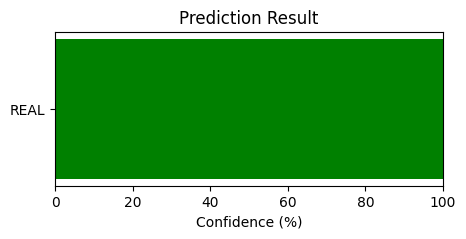

File: D013-029.png
Predicted: REAL
Confidence: 100.0 %


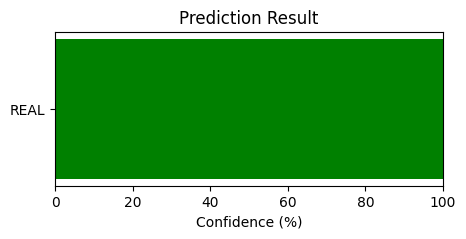

File: D021-040.png
Predicted: REAL
Confidence: 99.96 %


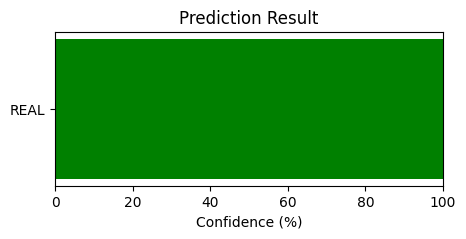

File: D009-033.png
Predicted: REAL
Confidence: 100.0 %


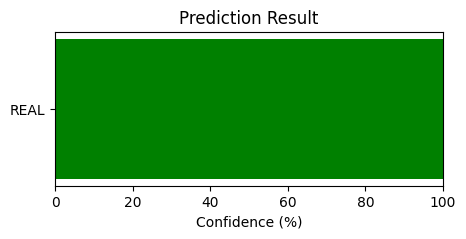

File: E020-022.png
Predicted: REAL
Confidence: 99.43 %


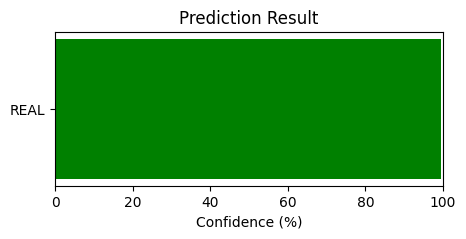

File: D002-128.png
Predicted: REAL
Confidence: 99.94 %


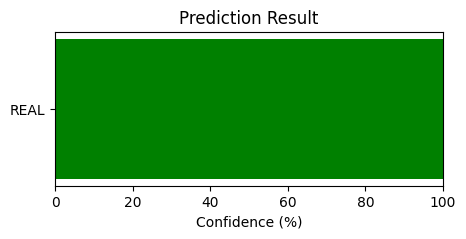

File: D001-049.png
Predicted: REAL
Confidence: 99.97 %


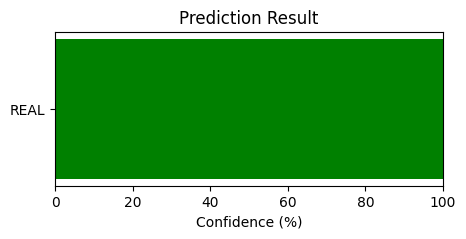

File: E028-016.png
Predicted: REAL
Confidence: 99.96 %


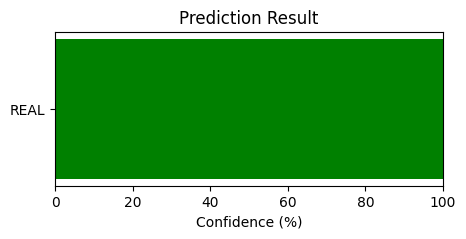

File: E021-002.png
Predicted: REAL
Confidence: 99.56 %


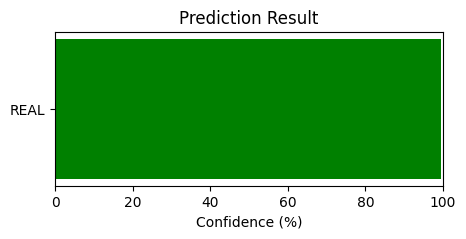

File: E010-008.png
Predicted: REAL
Confidence: 99.98 %


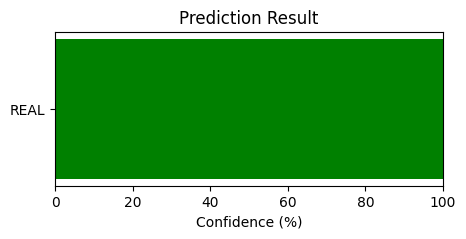

File: E031-002.png
Predicted: REAL
Confidence: 99.99 %


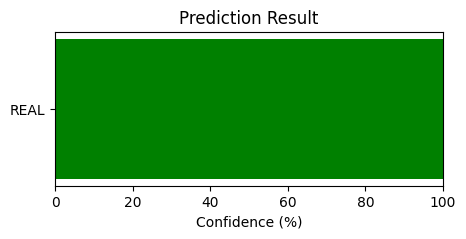

File: G010-028.png
Predicted: REAL
Confidence: 100.0 %


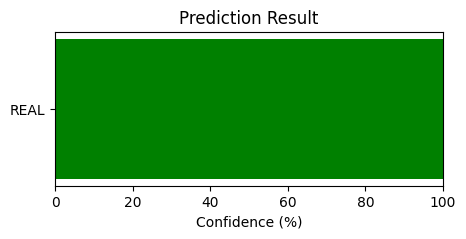

File: F028-009.png
Predicted: REAL
Confidence: 97.93 %


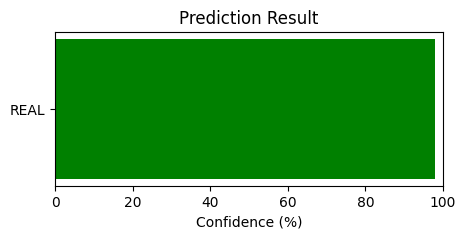

File: F023-012.png
Predicted: REAL
Confidence: 98.07 %


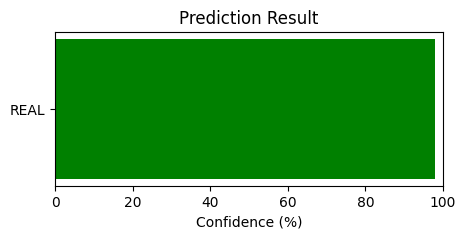

File: F031-045.png
Predicted: REAL
Confidence: 100.0 %


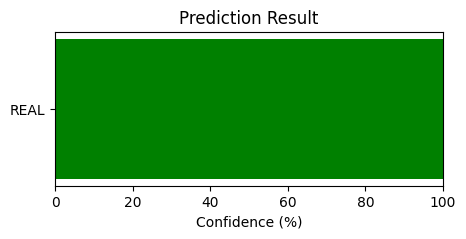

File: F017-021.png
Predicted: REAL
Confidence: 92.64 %


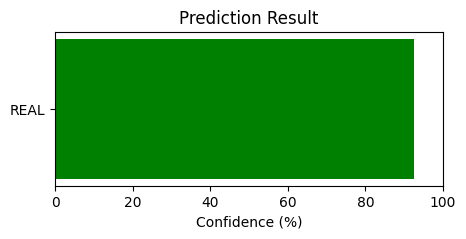

File: F039-023.png
Predicted: REAL
Confidence: 98.89 %


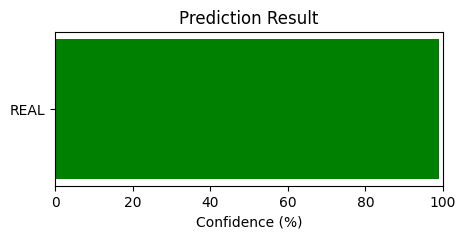

File: G016-023.png
Predicted: REAL
Confidence: 95.29 %


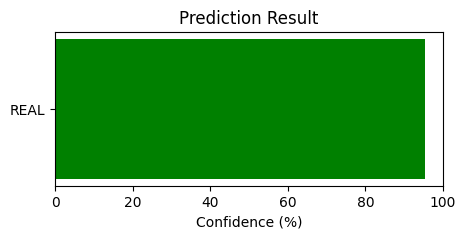

File: G008-253.png
Predicted: REAL
Confidence: 100.0 %


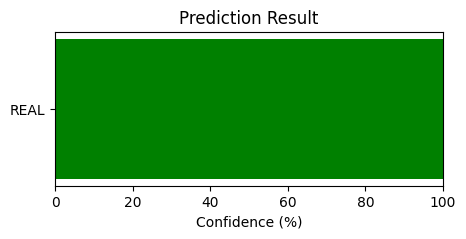

File: G020-119.png
Predicted: REAL
Confidence: 99.98 %


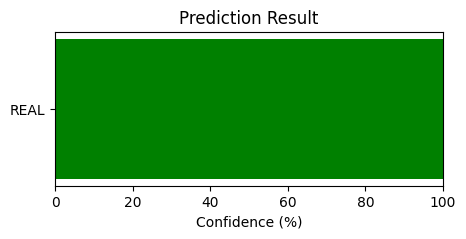

File: E035-002.png
Predicted: REAL
Confidence: 74.12 %


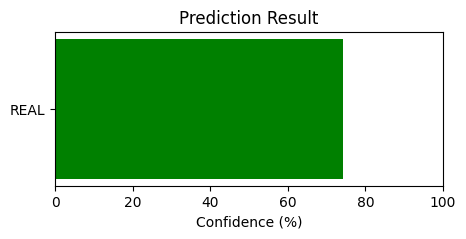

File: E146-014.png
Predicted: REAL
Confidence: 100.0 %


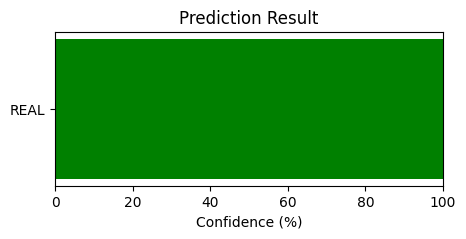

File: F041-019.png
Predicted: REAL
Confidence: 100.0 %


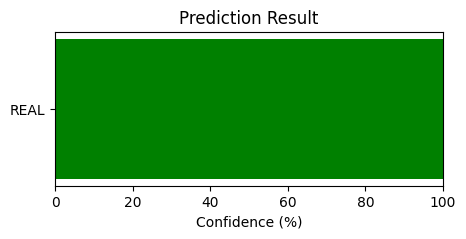

File: E127-113.png
Predicted: REAL
Confidence: 99.73 %


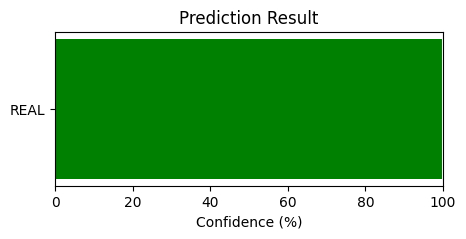

File: G001-101.png
Predicted: REAL
Confidence: 100.0 %


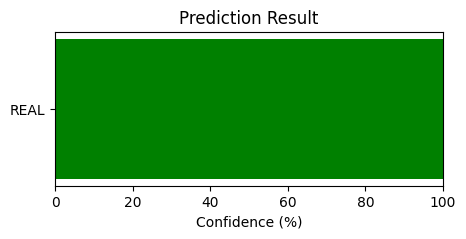

File: F014-310.png
Predicted: REAL
Confidence: 100.0 %


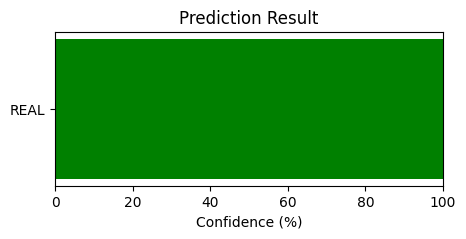

File: F019-037.png
Predicted: REAL
Confidence: 100.0 %


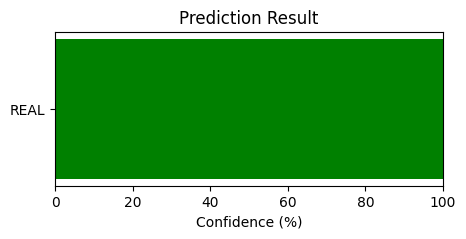

File: F011-109.png
Predicted: REAL
Confidence: 99.98 %


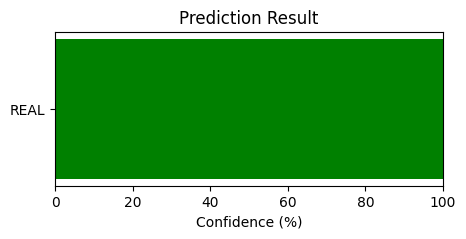

File: F026-002.png
Predicted: REAL
Confidence: 93.45 %


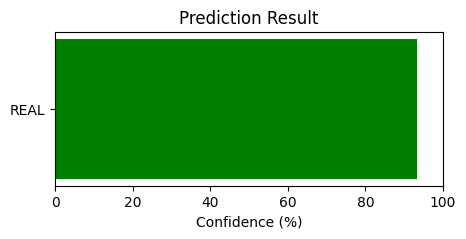

File: G009-227.png
Predicted: REAL
Confidence: 100.0 %


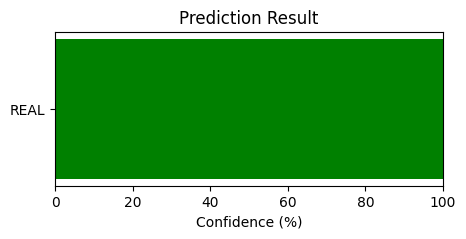

File: F030-024.png
Predicted: REAL
Confidence: 99.99 %


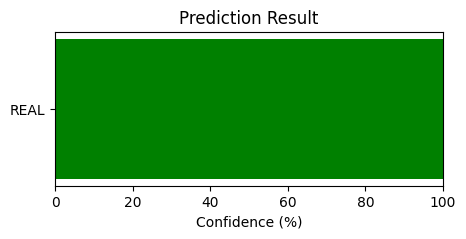

File: F013-030.png
Predicted: REAL
Confidence: 99.76 %


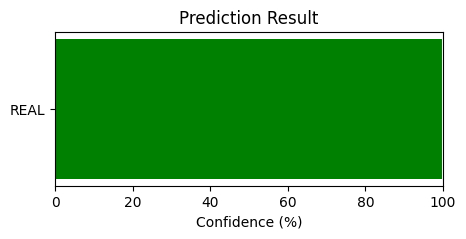

File: E034-008.png
Predicted: REAL
Confidence: 99.68 %


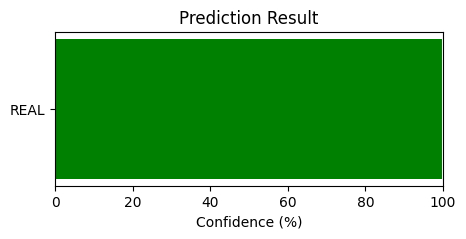

File: F054-005.png
Predicted: REAL
Confidence: 100.0 %


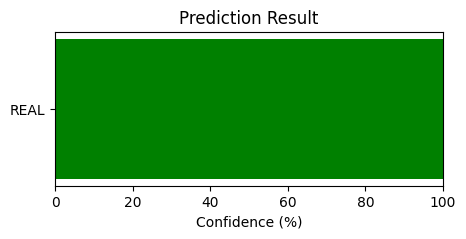

File: F004-022.png
Predicted: REAL
Confidence: 84.34 %


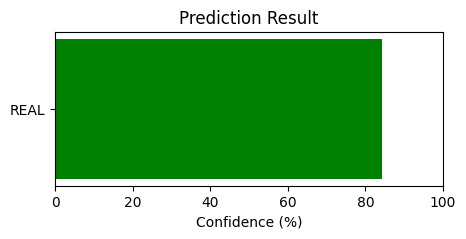

File: F020-208.png
Predicted: REAL
Confidence: 100.0 %


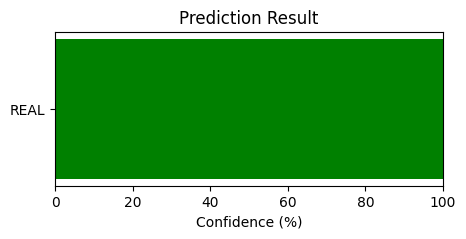

File: G005-028.png
Predicted: REAL
Confidence: 100.0 %


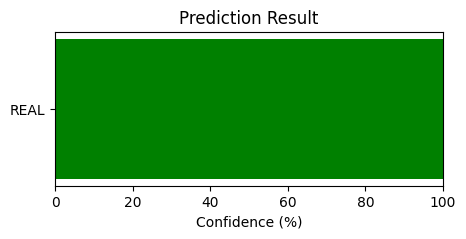

File: E039-002.png
Predicted: REAL
Confidence: 100.0 %


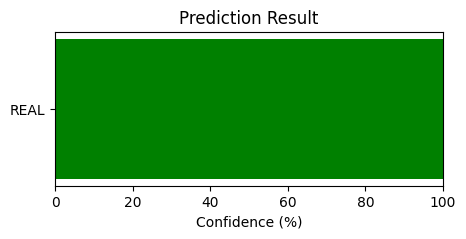

File: F025-045.png
Predicted: REAL
Confidence: 100.0 %


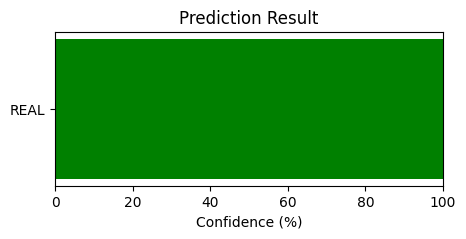

File: F048-048.png
Predicted: REAL
Confidence: 100.0 %


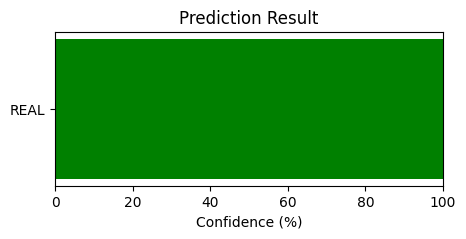

File: G015-110.png
Predicted: REAL
Confidence: 99.91 %


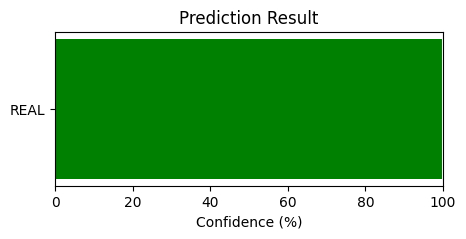

File: F022-137.png
Predicted: REAL
Confidence: 100.0 %


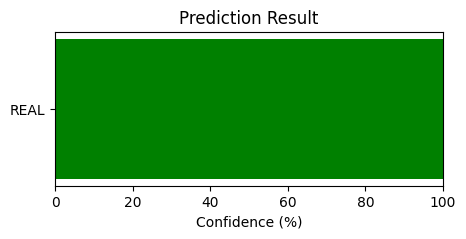

File: E145-014.png
Predicted: REAL
Confidence: 96.75 %


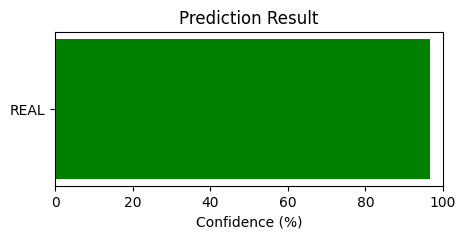

File: F036-121.png
Predicted: REAL
Confidence: 99.93 %


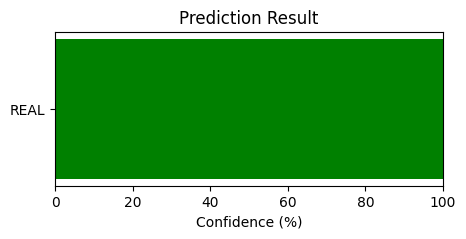

File: G019-009.png
Predicted: REAL
Confidence: 100.0 %


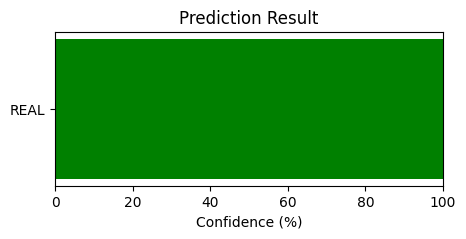

File: F018-029.png
Predicted: REAL
Confidence: 100.0 %


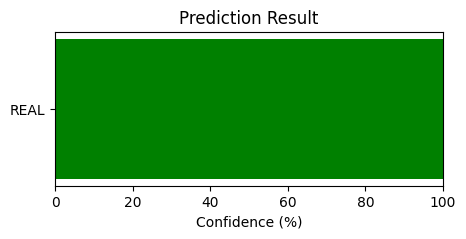

File: G017-013.png
Predicted: REAL
Confidence: 99.92 %


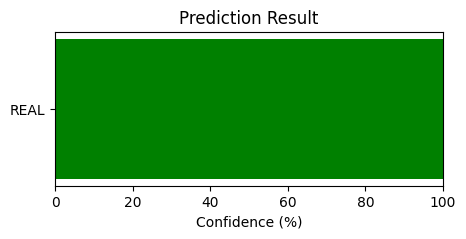

File: E075-004.png
Predicted: REAL
Confidence: 96.46 %


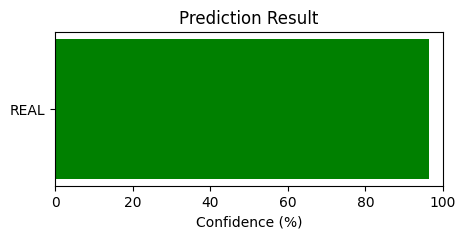

File: F033-430.png
Predicted: REAL
Confidence: 99.2 %


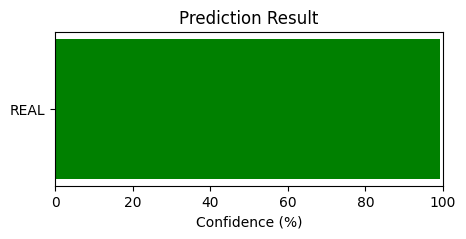

File: F050-056.png
Predicted: REAL
Confidence: 99.36 %


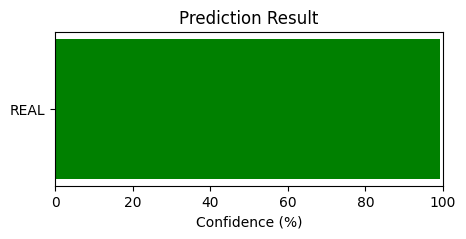

File: H022-144.png
Predicted: REAL
Confidence: 99.98 %


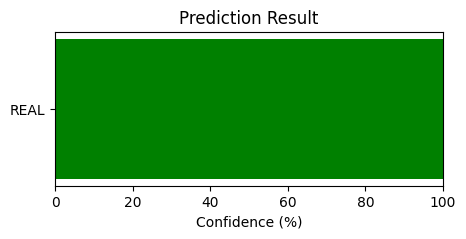

File: G021-111.png
Predicted: REAL
Confidence: 99.72 %


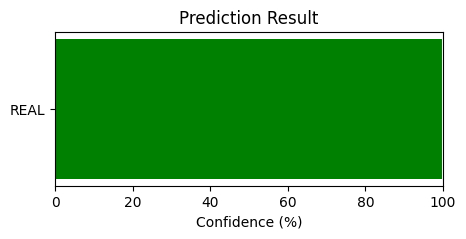

File: G029-038.png
Predicted: REAL
Confidence: 100.0 %


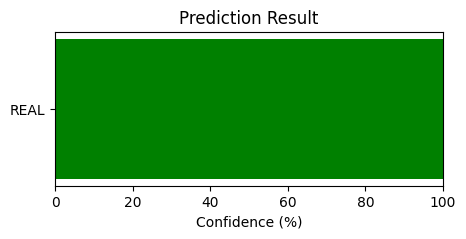

File: G040-445.png
Predicted: REAL
Confidence: 100.0 %


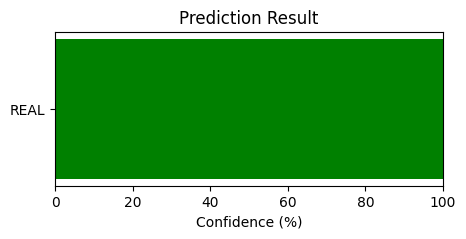

File: H013-115.png
Predicted: REAL
Confidence: 99.93 %


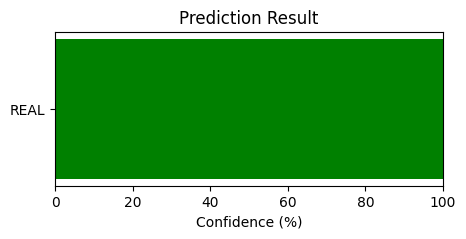

File: G048-008.png
Predicted: REAL
Confidence: 100.0 %


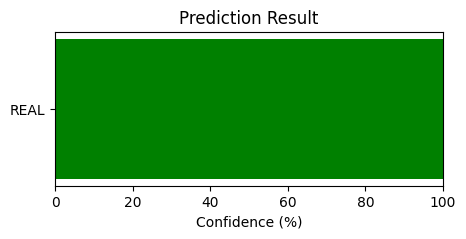

File: H031-028.png
Predicted: REAL
Confidence: 100.0 %


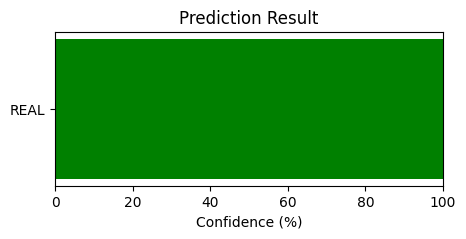

File: G052-133.png
Predicted: REAL
Confidence: 100.0 %


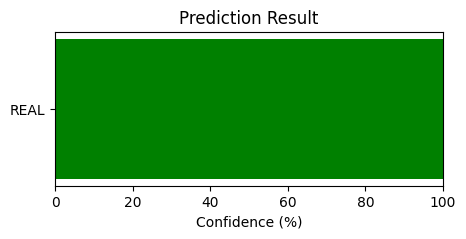

File: G042-129.png
Predicted: REAL
Confidence: 100.0 %


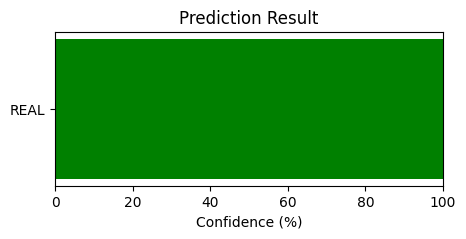

File: H018-037.png
Predicted: REAL
Confidence: 95.83 %


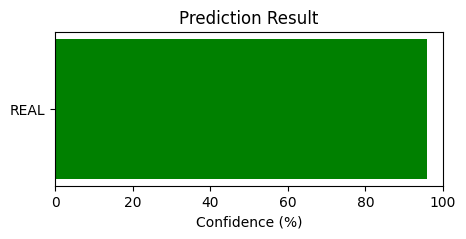

File: H035-013.png
Predicted: REAL
Confidence: 99.67 %


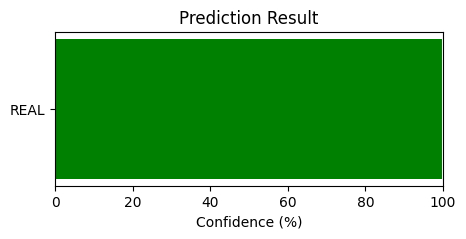

File: H027-015.png
Predicted: REAL
Confidence: 100.0 %


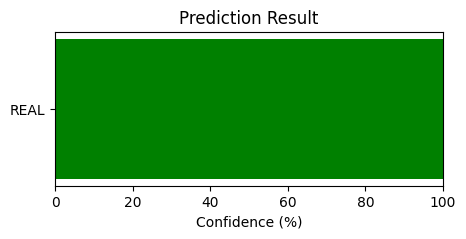

File: H043-140.png
Predicted: REAL
Confidence: 100.0 %


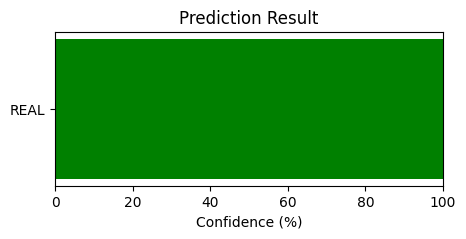

File: H026-018.png
Predicted: REAL
Confidence: 51.31 %


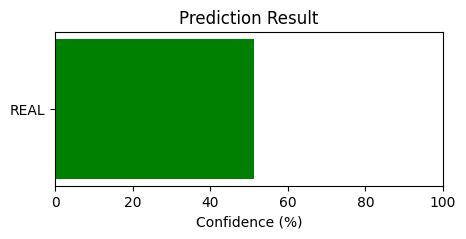

File: H049-208.png
Predicted: REAL
Confidence: 100.0 %


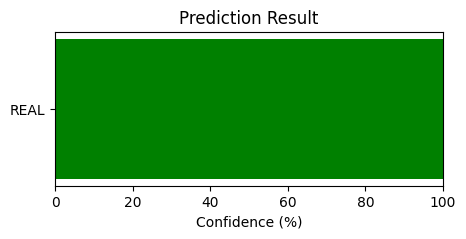

File: H023-301.png
Predicted: REAL
Confidence: 100.0 %


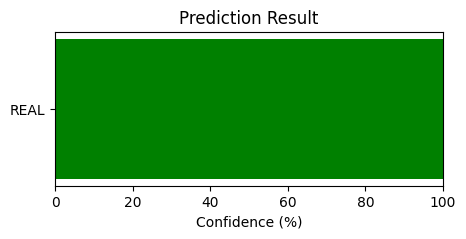

File: H011-037.png
Predicted: REAL
Confidence: 99.91 %


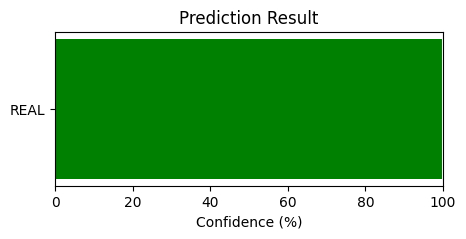

File: H008-146.png
Predicted: REAL
Confidence: 100.0 %


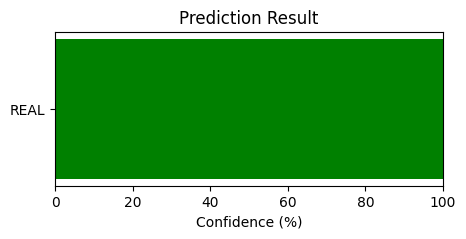

File: H042-138.png
Predicted: REAL
Confidence: 99.81 %


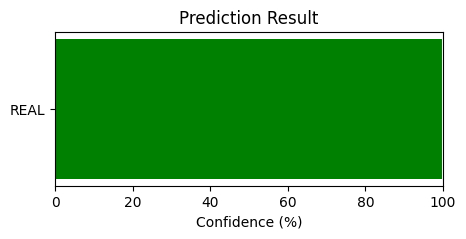

File: H014-005.png
Predicted: REAL
Confidence: 97.97 %


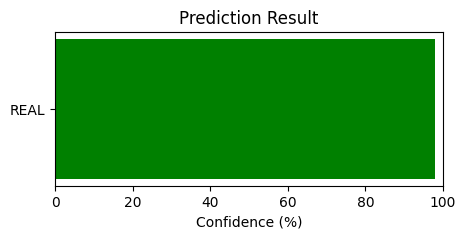

File: H048-206.png
Predicted: REAL
Confidence: 100.0 %


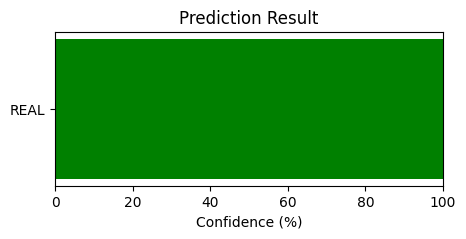

File: H036-022.png
Predicted: REAL
Confidence: 100.0 %


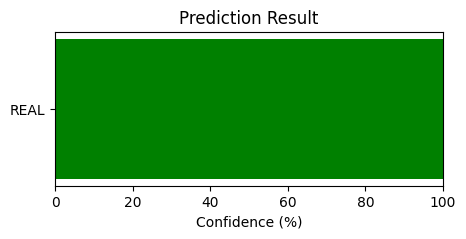

File: G044-612.png
Predicted: REAL
Confidence: 100.0 %


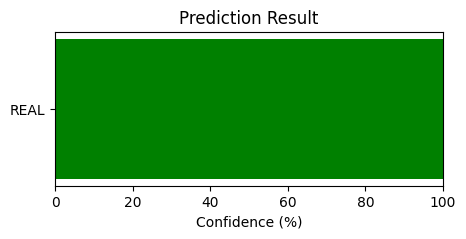

File: H010-113.png
Predicted: REAL
Confidence: 100.0 %


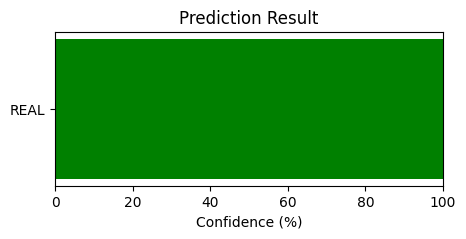

File: H040-008.png
Predicted: REAL
Confidence: 100.0 %


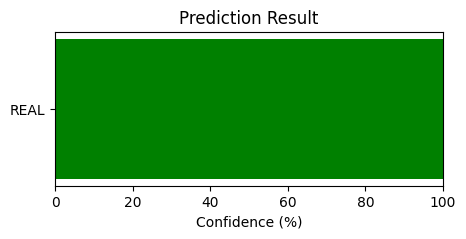

File: H024-023.png
Predicted: REAL
Confidence: 99.99 %


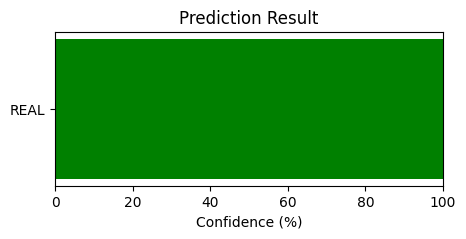

File: H028-123.png
Predicted: REAL
Confidence: 98.76 %


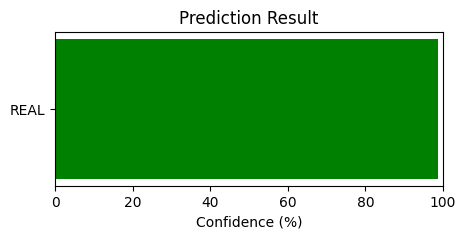

File: H017-011.png
Predicted: REAL
Confidence: 100.0 %


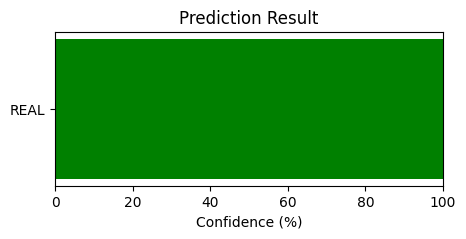

File: H015-113.png
Predicted: REAL
Confidence: 94.35 %


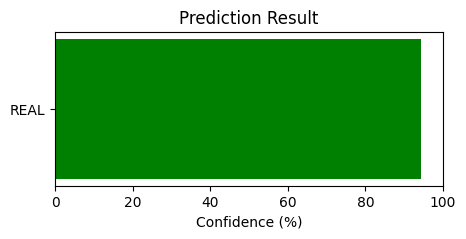

File: H033-019.png
Predicted: REAL
Confidence: 100.0 %


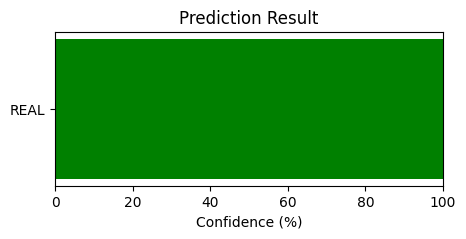

File: H020-018.png
Predicted: REAL
Confidence: 98.36 %


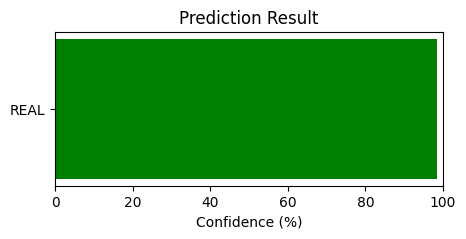

File: G031-007.png
Predicted: REAL
Confidence: 100.0 %


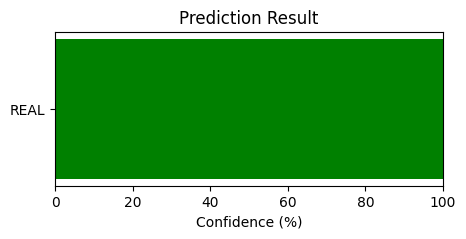

File: G049-036.png
Predicted: REAL
Confidence: 100.0 %


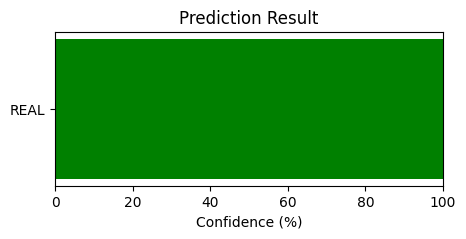

File: H034-044.png
Predicted: REAL
Confidence: 99.17 %


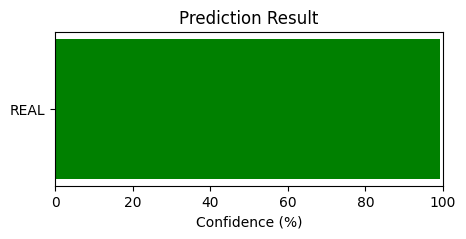

File: H001-042.png
Predicted: REAL
Confidence: 100.0 %


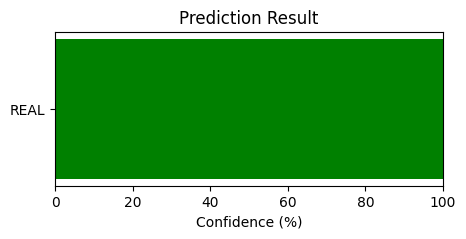

File: H012-020.png
Predicted: REAL
Confidence: 100.0 %


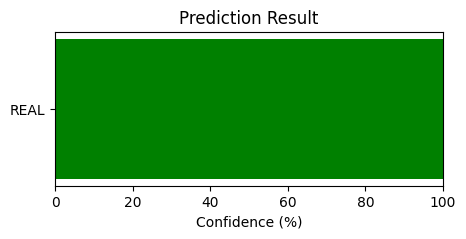


ACTUAL CATEGORY: EDITED

File: B011-102.png
Predicted: EDITED
Confidence: 97.21 %


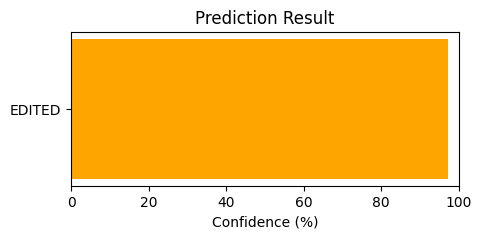

File: B004-045.png
Predicted: EDITED
Confidence: 99.77 %


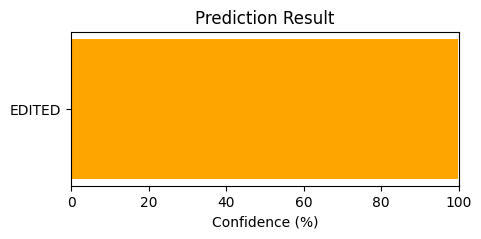

File: A018-056.png
Predicted: EDITED
Confidence: 99.81 %


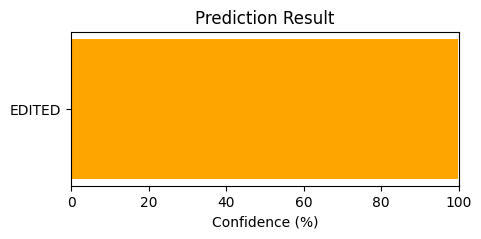

File: A024-034.png
Predicted: EDITED
Confidence: 99.94 %


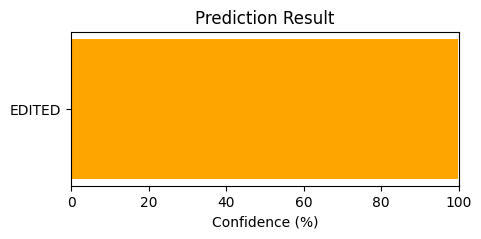

File: A025-051.png
Predicted: EDITED
Confidence: 99.98 %


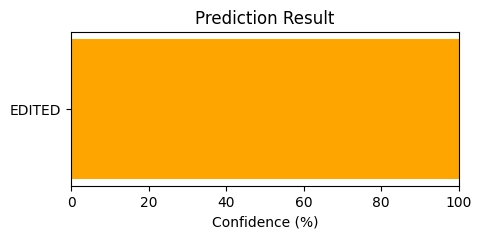

File: A042-459.png
Predicted: EDITED
Confidence: 99.89 %


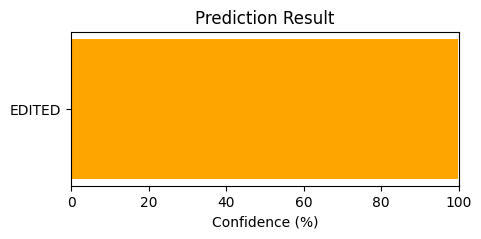

File: A027-106.png
Predicted: EDITED
Confidence: 97.41 %


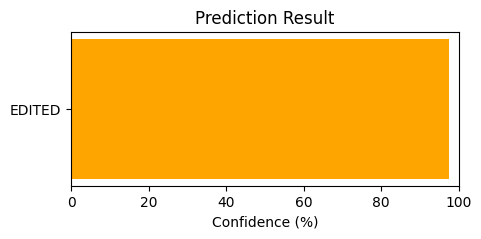

File: B015-017.png
Predicted: EDITED
Confidence: 98.93 %


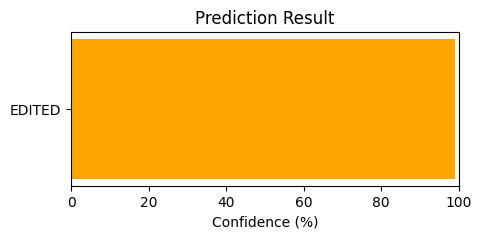

File: A008-229.png
Predicted: EDITED
Confidence: 99.96 %


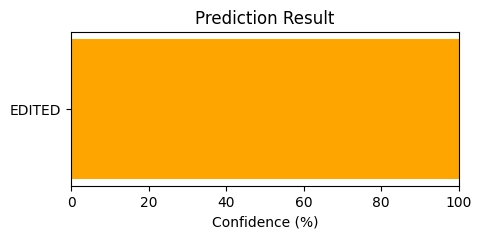

File: A005-023.png
Predicted: EDITED
Confidence: 99.82 %


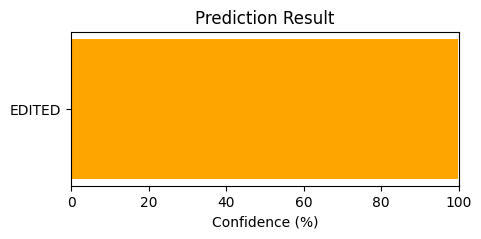

File: B022-045.png
Predicted: EDITED
Confidence: 99.95 %


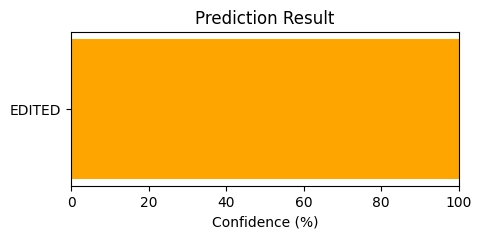

File: B005-051.png
Predicted: EDITED
Confidence: 99.25 %


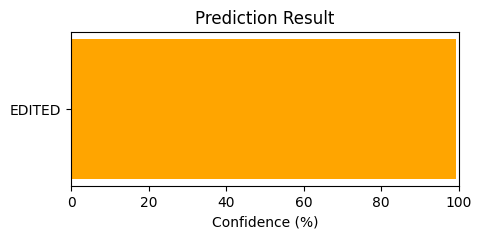

File: A035-116.png
Predicted: EDITED
Confidence: 99.87 %


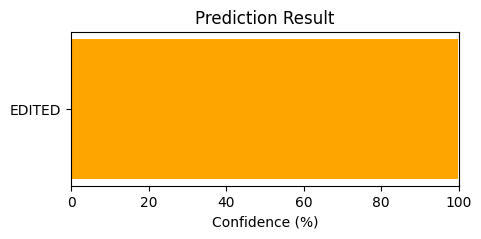

File: A037-005.png
Predicted: EDITED
Confidence: 99.76 %


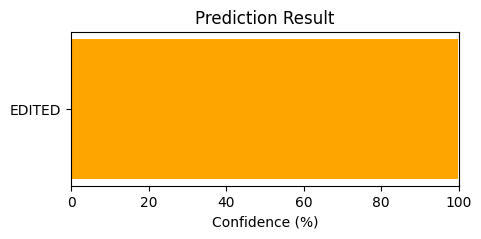

File: A013-004.png
Predicted: EDITED
Confidence: 99.95 %


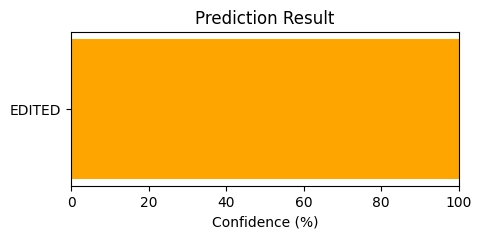

File: A026-008.png
Predicted: EDITED
Confidence: 98.67 %


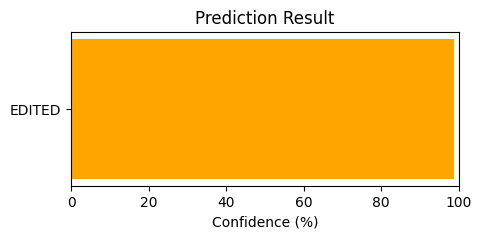

File: A050-200.png
Predicted: EDITED
Confidence: 99.68 %


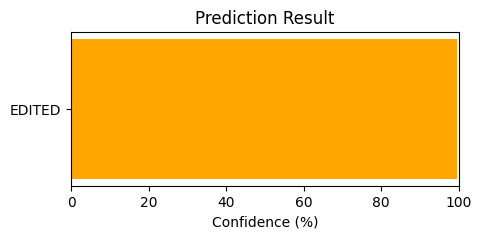

File: A049-021.png
Predicted: EDITED
Confidence: 99.8 %


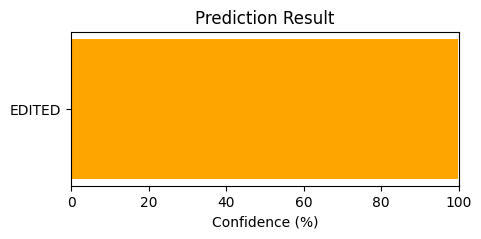

File: A033-052.png
Predicted: EDITED
Confidence: 99.87 %


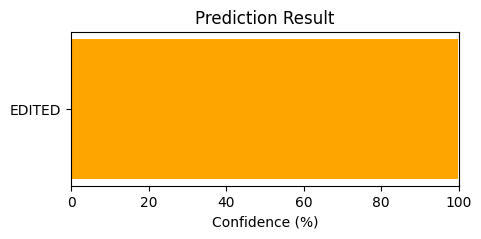

File: A023-033.png
Predicted: EDITED
Confidence: 98.83 %


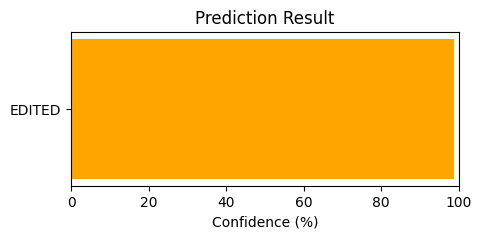

File: A045-215.png
Predicted: EDITED
Confidence: 79.05 %


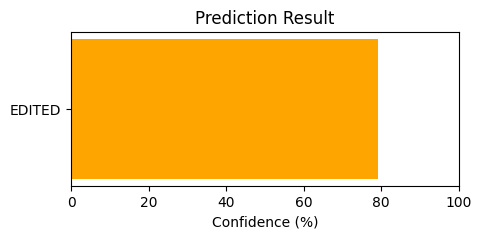

File: B001-047.png
Predicted: EDITED
Confidence: 97.31 %


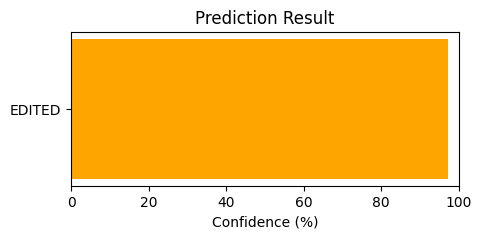

File: A001-010.png
Predicted: EDITED
Confidence: 99.97 %


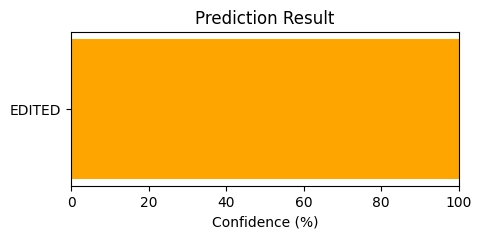

File: A003-032.png
Predicted: EDITED
Confidence: 99.62 %


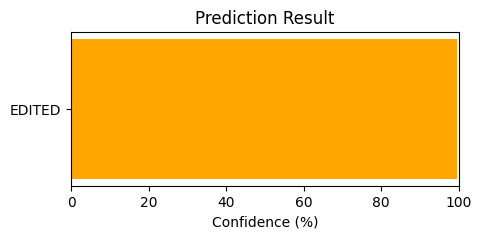

File: A048-135.png
Predicted: EDITED
Confidence: 98.2 %


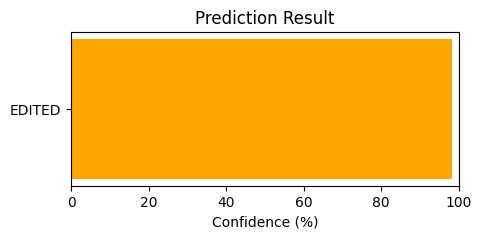

File: A031-024.png
Predicted: EDITED
Confidence: 99.95 %


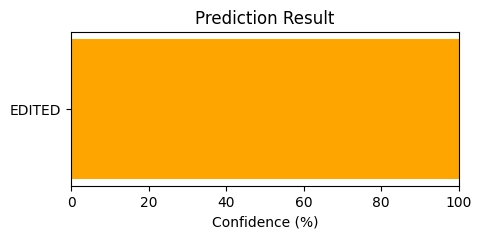

File: B007-056.png
Predicted: EDITED
Confidence: 99.46 %


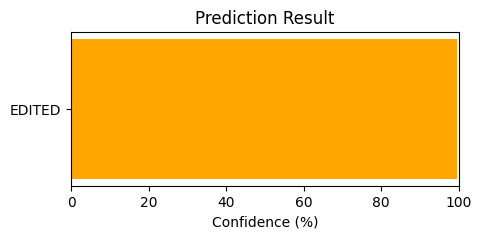

File: B021-354.png
Predicted: EDITED
Confidence: 97.65 %


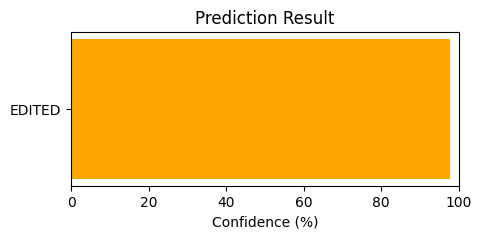

File: A017-047.png
Predicted: EDITED
Confidence: 99.86 %


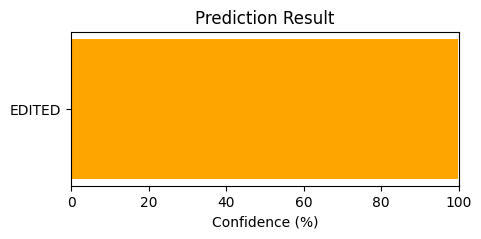

File: B017-110.png
Predicted: EDITED
Confidence: 99.74 %


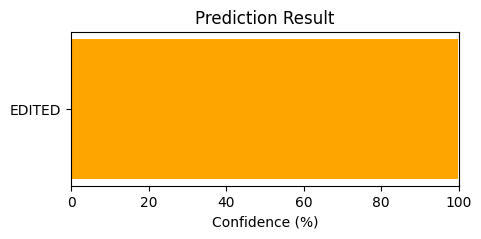

File: A040-126.png
Predicted: EDITED
Confidence: 99.51 %


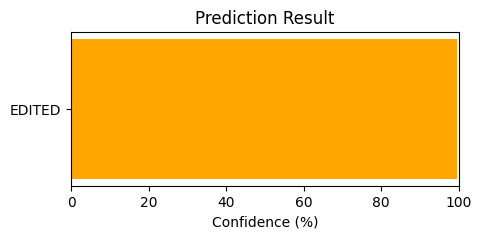

File: B031-053.png
Predicted: EDITED
Confidence: 99.35 %


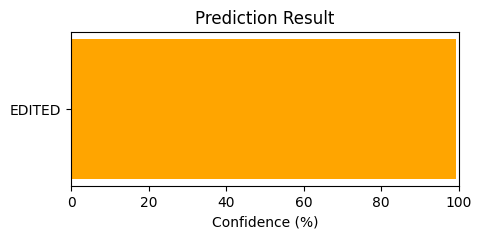

File: C032-006.png
Predicted: EDITED
Confidence: 99.47 %


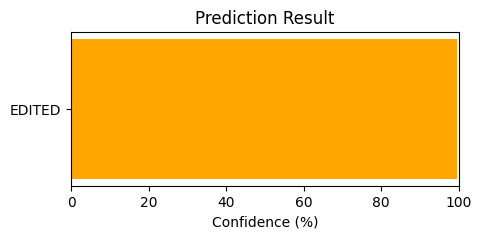

File: C030-033.png
Predicted: EDITED
Confidence: 99.57 %


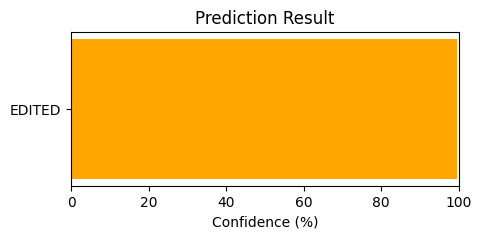

File: B032-047.png
Predicted: EDITED
Confidence: 99.58 %


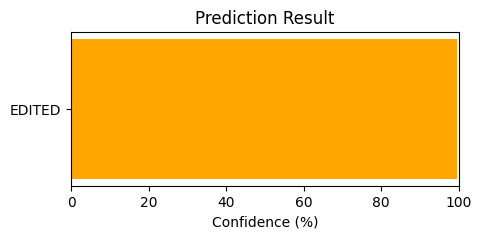

File: C020-055.png
Predicted: EDITED
Confidence: 99.55 %


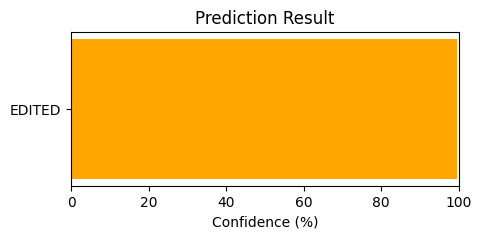

File: C018-017.png
Predicted: EDITED
Confidence: 99.97 %


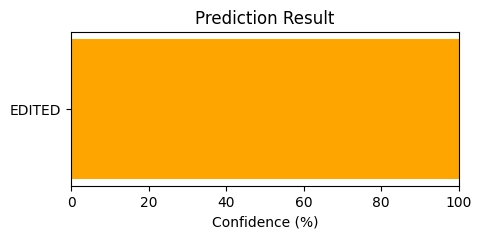

File: C001-103.png
Predicted: EDITED
Confidence: 99.52 %


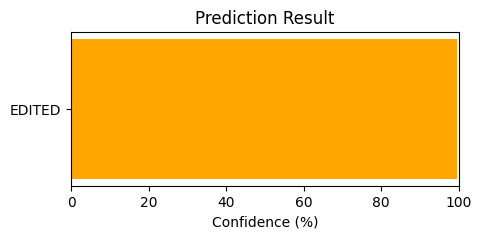

File: C014-038.png
Predicted: EDITED
Confidence: 99.87 %


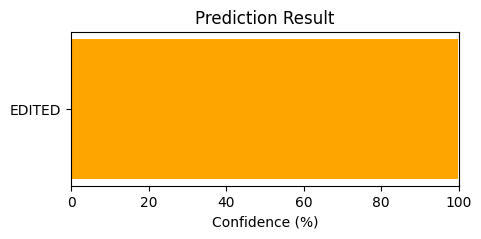

File: C006-121.png
Predicted: EDITED
Confidence: 99.48 %


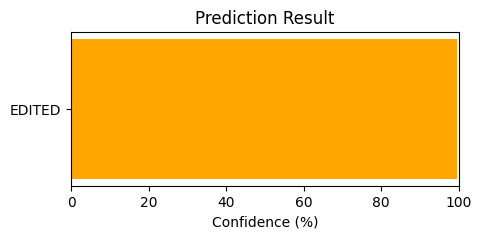

File: C038-004.png
Predicted: EDITED
Confidence: 99.13 %


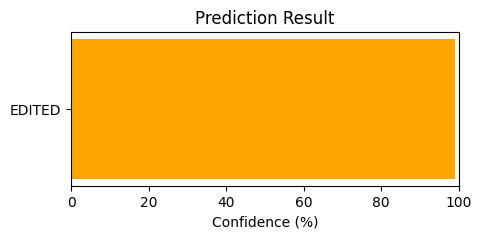

File: C025-040.png
Predicted: EDITED
Confidence: 99.42 %


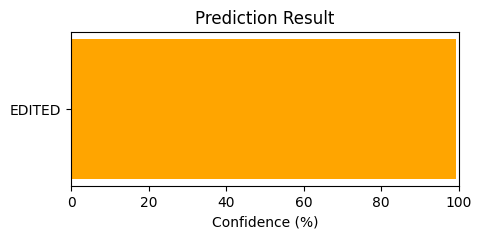

File: B046-304.png
Predicted: EDITED
Confidence: 95.62 %


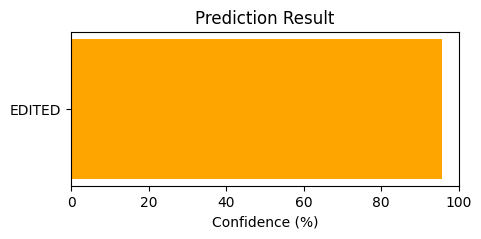

File: B044-136.png
Predicted: EDITED
Confidence: 94.04 %


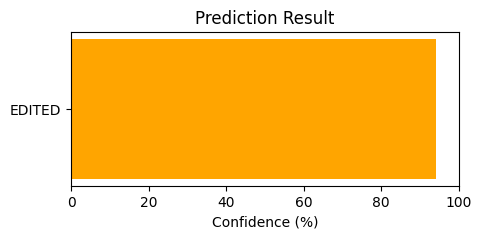

File: B048-131.png
Predicted: EDITED
Confidence: 99.69 %


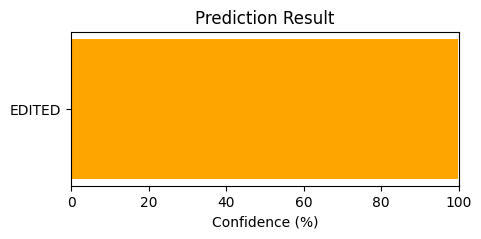

File: C002-134.png
Predicted: EDITED
Confidence: 96.1 %


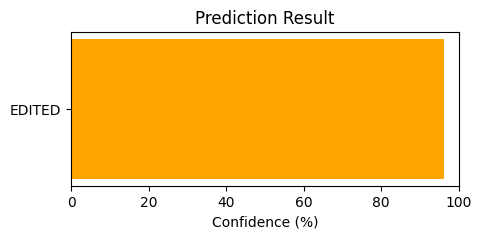

File: C051-022.png
Predicted: EDITED
Confidence: 99.63 %


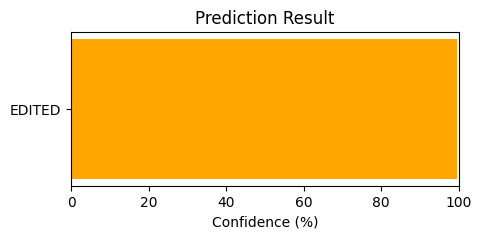

File: B029-357.png
Predicted: EDITED
Confidence: 99.98 %


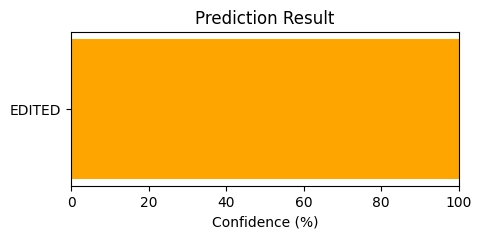

File: C005-005.png
Predicted: EDITED
Confidence: 94.3 %


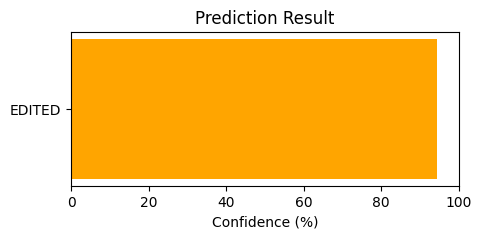

File: C044-034.png
Predicted: EDITED
Confidence: 97.99 %


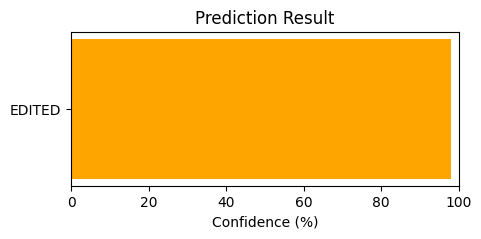

File: B039-500.png
Predicted: EDITED
Confidence: 90.44 %


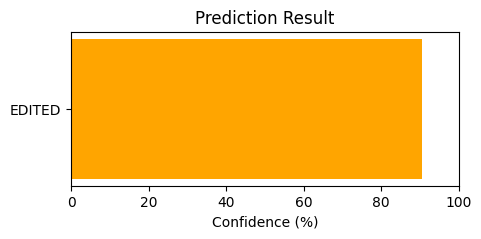

File: B040-037.png
Predicted: EDITED
Confidence: 98.5 %


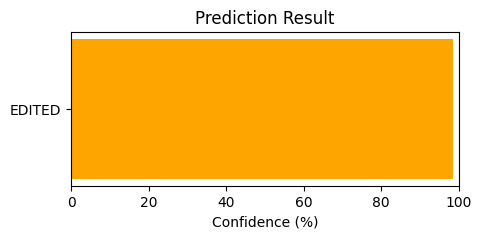

File: C023-016.png
Predicted: EDITED
Confidence: 98.57 %


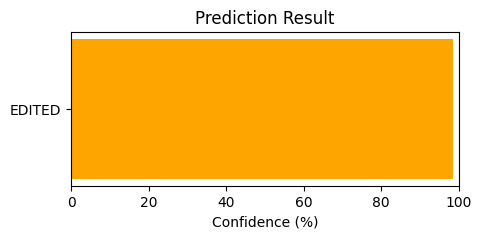

File: B025-024.png
Predicted: EDITED
Confidence: 99.33 %


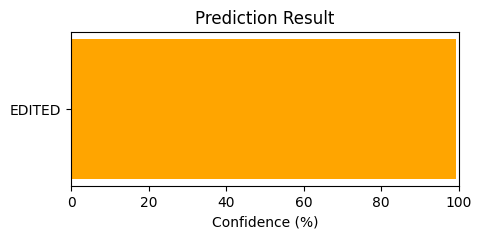

File: C003-005.png
Predicted: EDITED
Confidence: 99.76 %


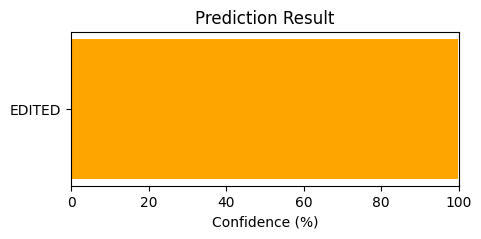

File: C015-355.png
Predicted: EDITED
Confidence: 98.89 %


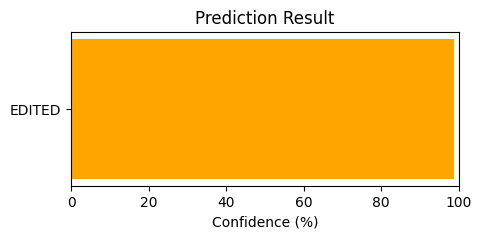

File: C031-041.png
Predicted: EDITED
Confidence: 99.97 %


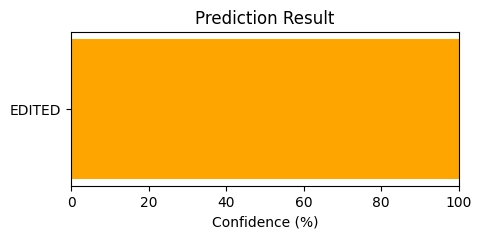

File: C016-039.png
Predicted: EDITED
Confidence: 99.88 %


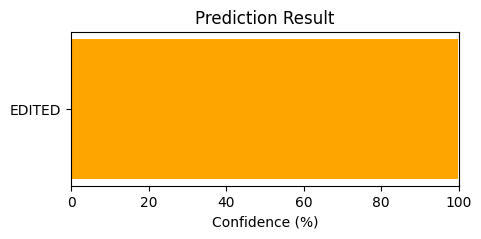

File: C013-302.png
Predicted: EDITED
Confidence: 99.3 %


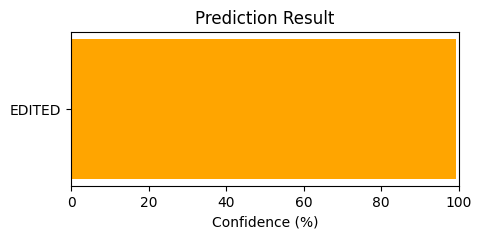

File: B028-034.png
Predicted: EDITED
Confidence: 97.63 %


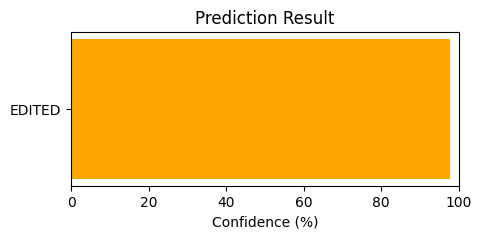

File: C049-005.png
Predicted: EDITED
Confidence: 98.33 %


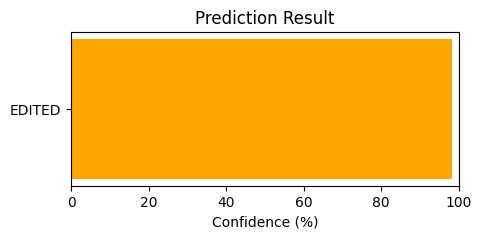

File: B035-247.png
Predicted: EDITED
Confidence: 99.83 %


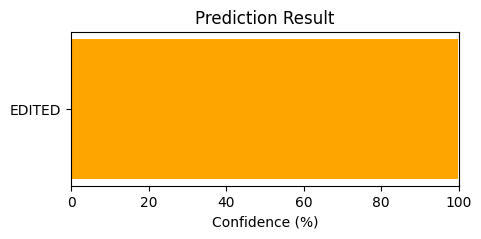

File: C021-038.png
Predicted: EDITED
Confidence: 97.54 %


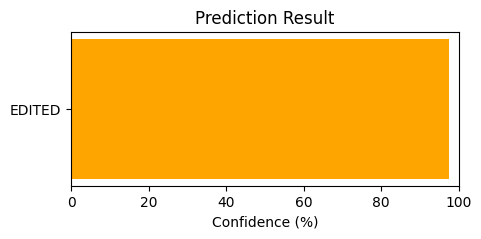

File: B023-048.png
Predicted: EDITED
Confidence: 99.89 %


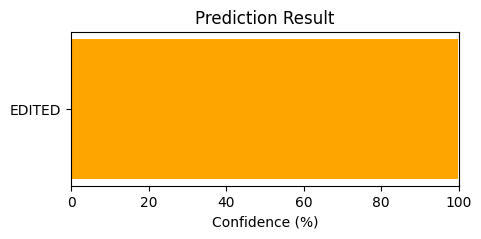

File: C029-029.png
Predicted: EDITED
Confidence: 99.71 %


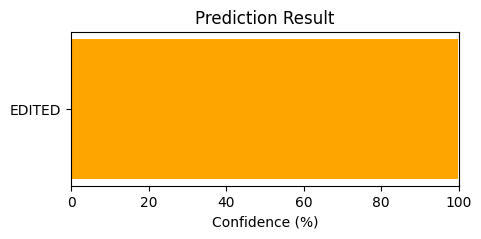

File: C009-009.png
Predicted: EDITED
Confidence: 99.01 %


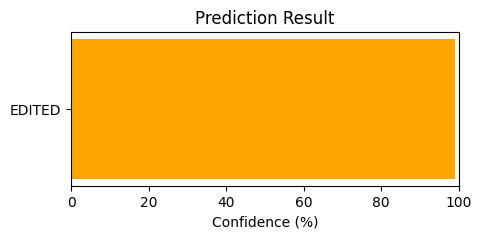

File: B037-012.png
Predicted: EDITED
Confidence: 99.27 %


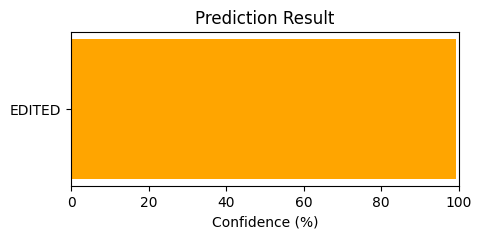

File: B049-327.png
Predicted: EDITED
Confidence: 98.02 %


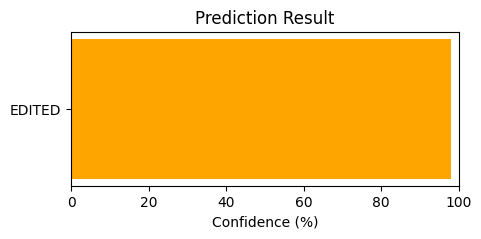

File: C010-120.png
Predicted: EDITED
Confidence: 97.56 %


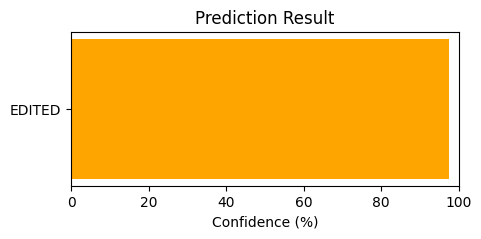

File: C052-041.png
Predicted: EDITED
Confidence: 99.62 %


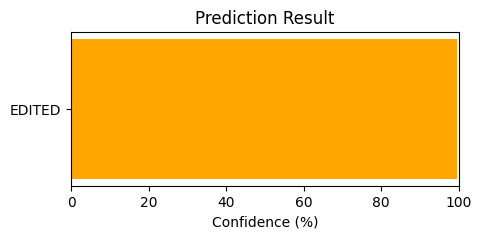

File: B043-118.png
Predicted: EDITED
Confidence: 97.02 %


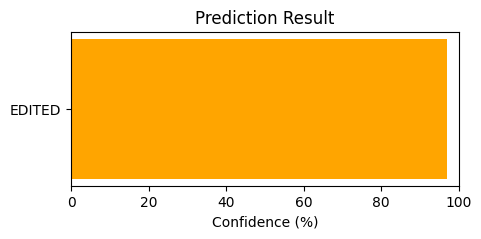

File: C027-105.png
Predicted: EDITED
Confidence: 99.4 %


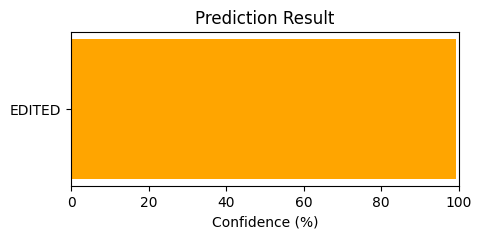

File: C007-209.png
Predicted: EDITED
Confidence: 99.86 %


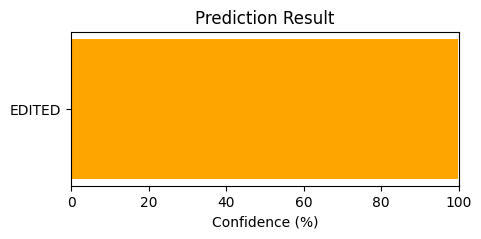

File: B026-215.png
Predicted: EDITED
Confidence: 99.93 %


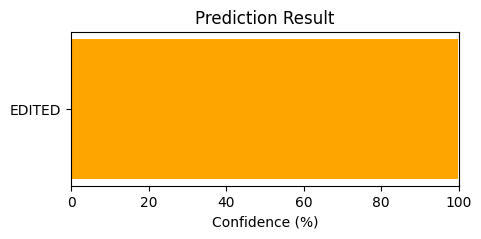

File: C028-106.png
Predicted: EDITED
Confidence: 98.81 %


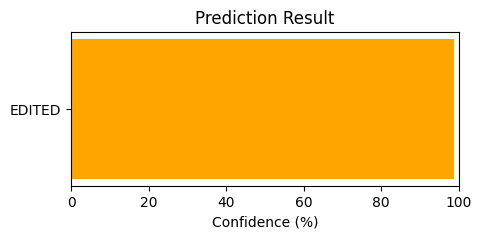

File: C022-159.png
Predicted: EDITED
Confidence: 99.99 %


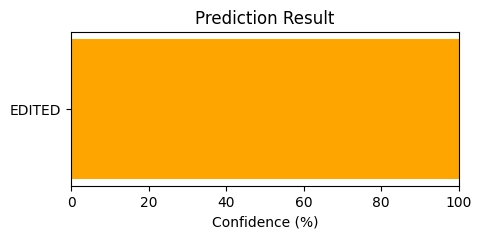

File: C042-301.png
Predicted: EDITED
Confidence: 99.87 %


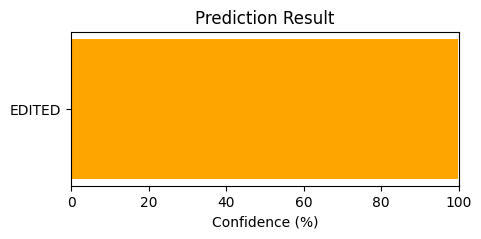

File: C008-011.png
Predicted: EDITED
Confidence: 96.78 %


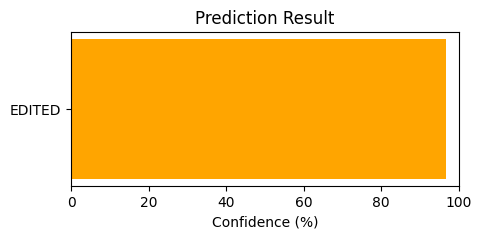

File: E029-004.png
Predicted: EDITED
Confidence: 99.45 %


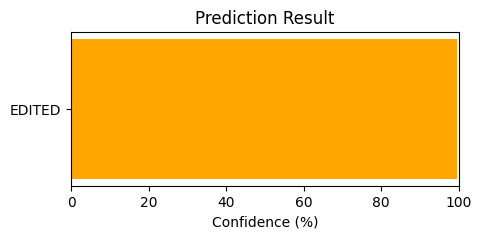

File: D010-142.png
Predicted: EDITED
Confidence: 98.27 %


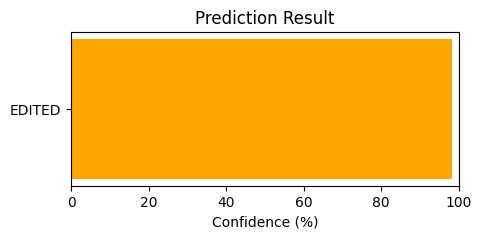

File: D020-114.png
Predicted: EDITED
Confidence: 99.22 %


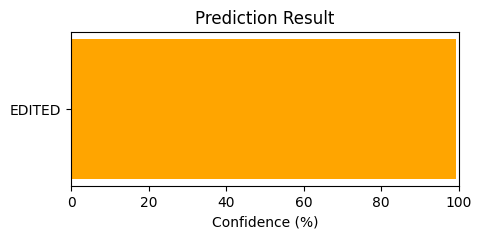

File: E032-020.png
Predicted: EDITED
Confidence: 99.8 %


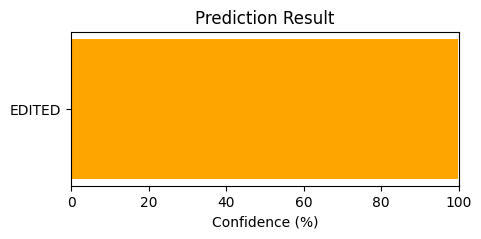

File: D016-121.png
Predicted: EDITED
Confidence: 99.77 %


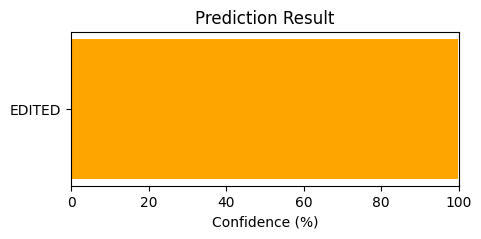

File: E030-036.png
Predicted: EDITED
Confidence: 99.55 %


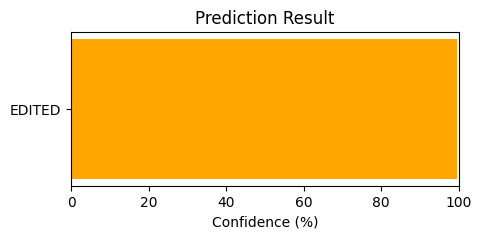

File: D031-112.png
Predicted: EDITED
Confidence: 99.9 %


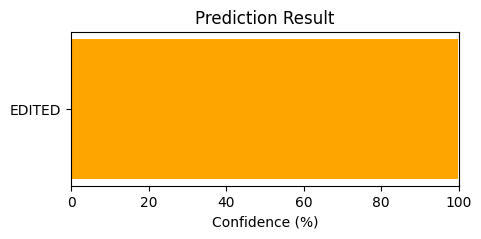

File: E004-005.png
Predicted: EDITED
Confidence: 99.02 %


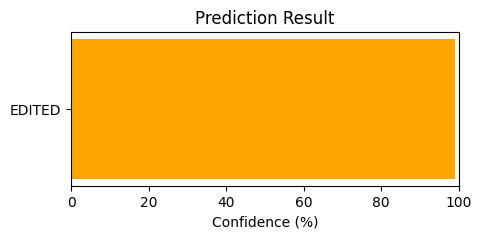

File: D004-015.png
Predicted: EDITED
Confidence: 100.0 %


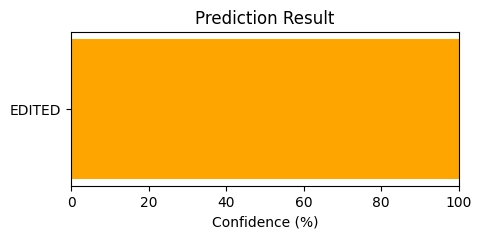

File: E002-010.png
Predicted: EDITED
Confidence: 99.88 %


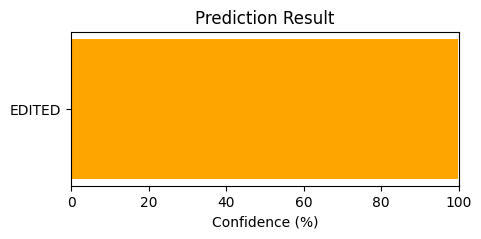

File: D027-036.png
Predicted: EDITED
Confidence: 99.71 %


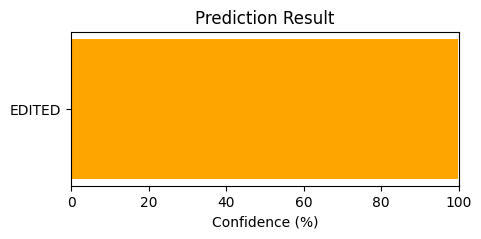

File: D012-025.png
Predicted: EDITED
Confidence: 99.42 %


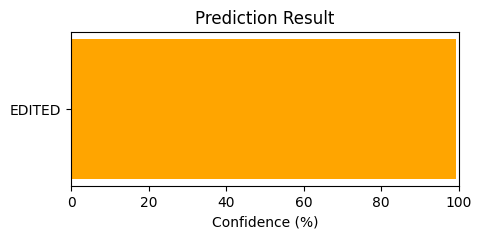

File: D048-025.png
Predicted: EDITED
Confidence: 98.24 %


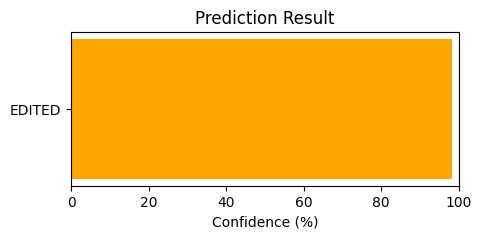

File: D022-114.png
Predicted: EDITED
Confidence: 96.54 %


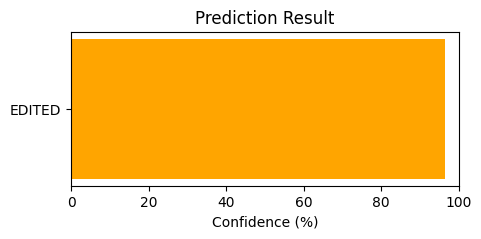

File: E011-009.png
Predicted: EDITED
Confidence: 99.9 %


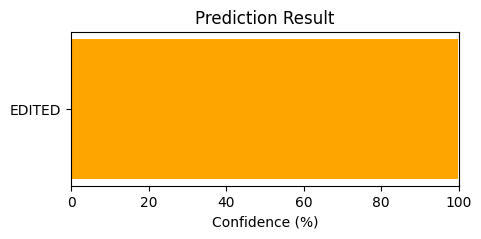

File: D019-008.png
Predicted: EDITED
Confidence: 99.57 %


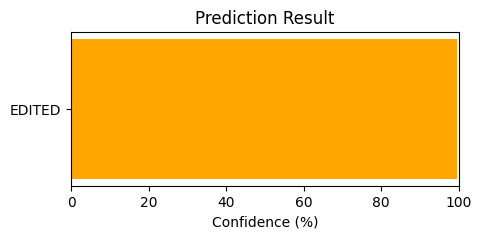

File: D006-331.png
Predicted: EDITED
Confidence: 99.85 %


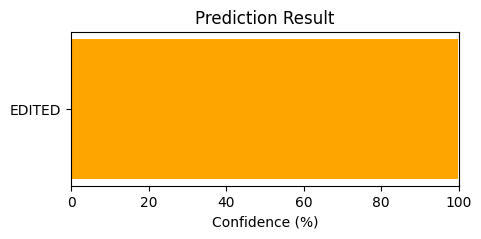

File: D007-030.png
Predicted: EDITED
Confidence: 99.93 %


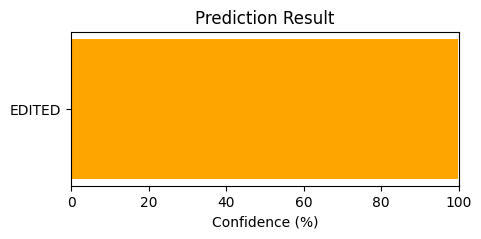

File: D017-047.png
Predicted: EDITED
Confidence: 99.36 %


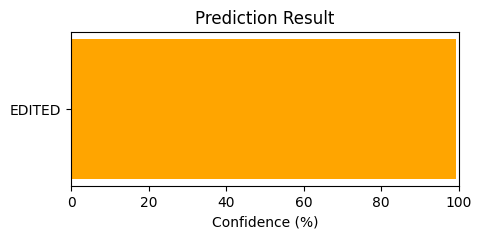

File: D045-215.png
Predicted: EDITED
Confidence: 99.99 %


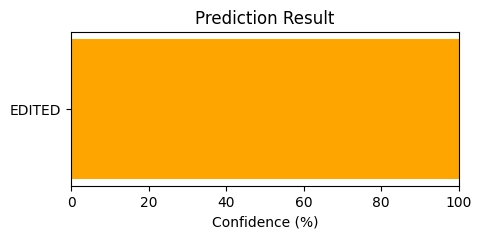

File: E012-009.png
Predicted: EDITED
Confidence: 99.19 %


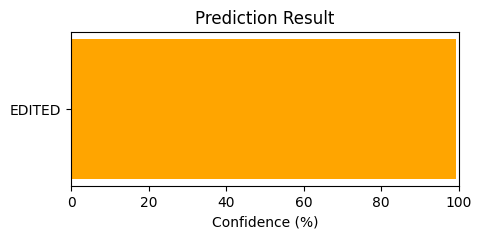

File: D046-053.png
Predicted: EDITED
Confidence: 99.99 %


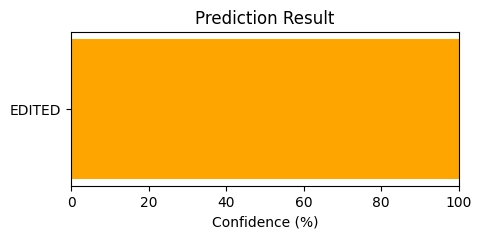

File: E019-027.png
Predicted: EDITED
Confidence: 99.62 %


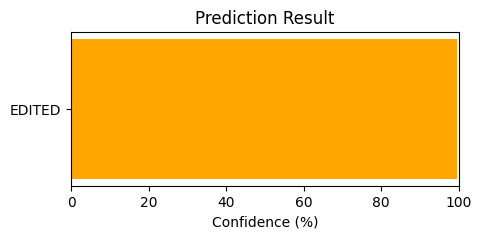

File: D026-037.png
Predicted: EDITED
Confidence: 99.36 %


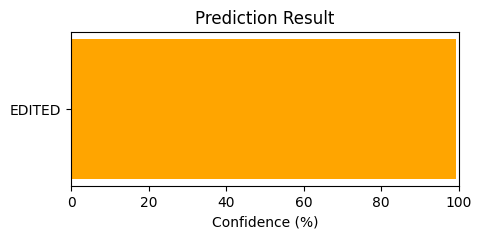

File: E013-015.png
Predicted: EDITED
Confidence: 93.36 %


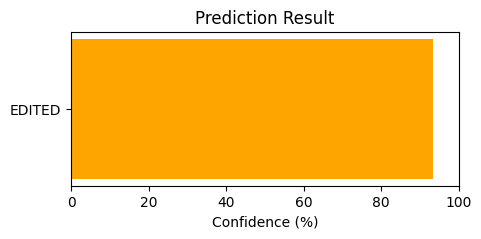

File: E027-003.png
Predicted: EDITED
Confidence: 94.66 %


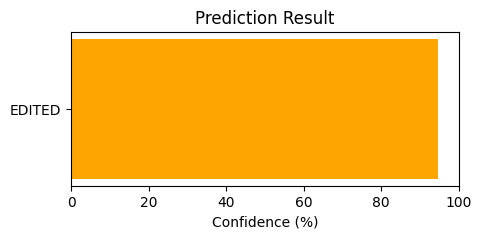

File: D013-029.png
Predicted: EDITED
Confidence: 84.06 %


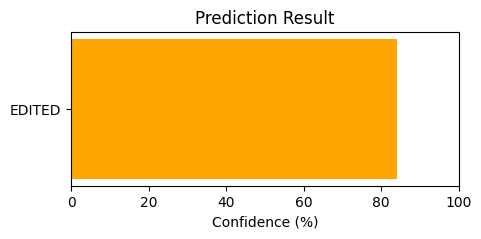

File: D021-040.png
Predicted: EDITED
Confidence: 99.55 %


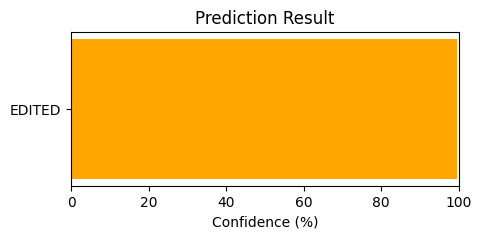

File: D009-033.png
Predicted: EDITED
Confidence: 99.75 %


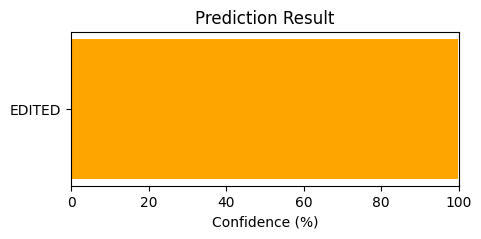

File: E020-022.png
Predicted: EDITED
Confidence: 98.94 %


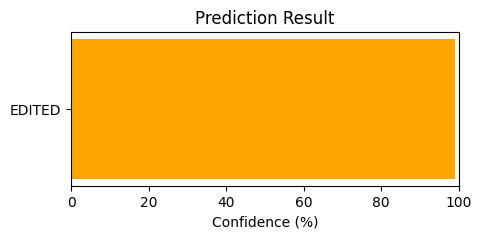

File: D002-128.png
Predicted: EDITED
Confidence: 99.94 %


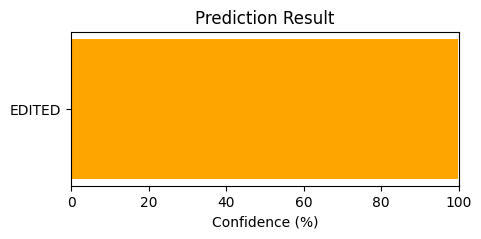

File: D001-049.png
Predicted: EDITED
Confidence: 99.98 %


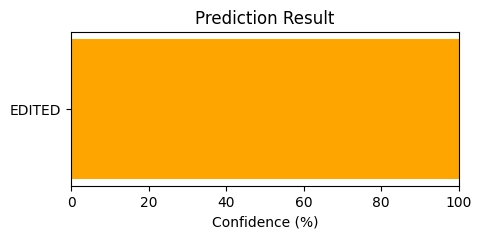

File: E028-016.png
Predicted: EDITED
Confidence: 99.25 %


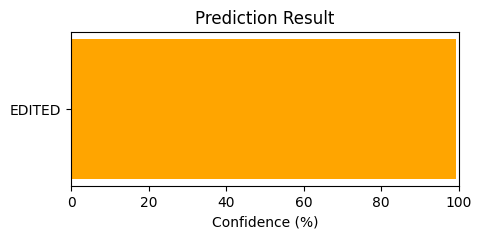

File: E021-002.png
Predicted: EDITED
Confidence: 99.59 %


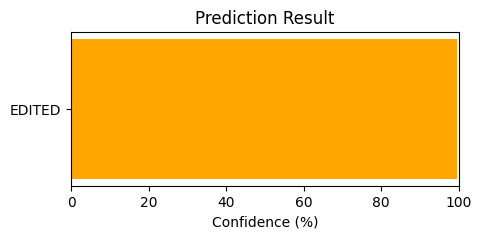

File: E010-008.png
Predicted: EDITED
Confidence: 98.85 %


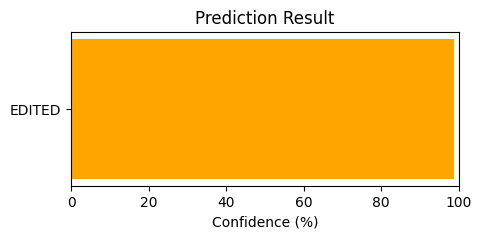

File: E031-002.png
Predicted: EDITED
Confidence: 99.82 %


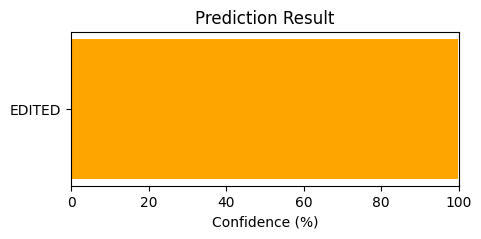

File: G010-028.png
Predicted: EDITED
Confidence: 99.52 %


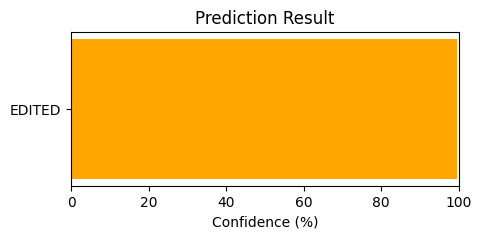

File: F028-009.png
Predicted: EDITED
Confidence: 99.91 %


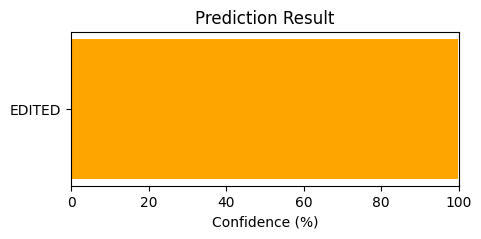

File: F023-012.png
Predicted: EDITED
Confidence: 99.33 %


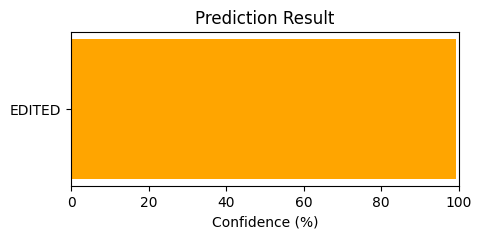

File: F031-045.png
Predicted: EDITED
Confidence: 98.7 %


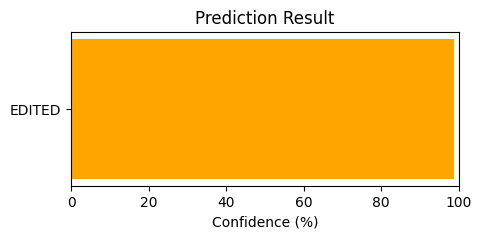

File: F017-021.png
Predicted: EDITED
Confidence: 92.17 %


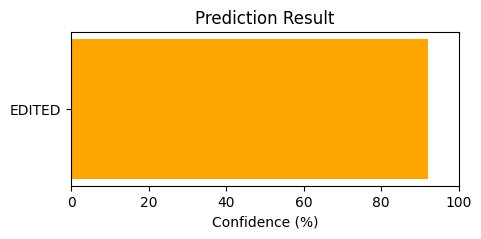

File: F039-023.png
Predicted: EDITED
Confidence: 99.84 %


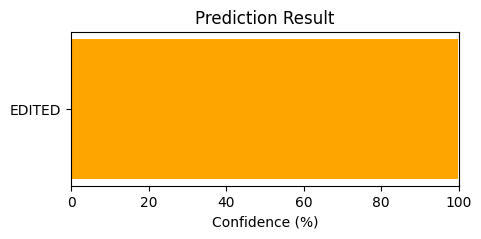

File: G016-023.png
Predicted: EDITED
Confidence: 99.08 %


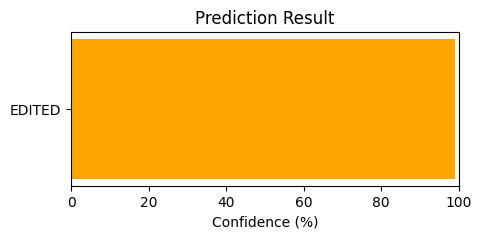

File: G008-253.png
Predicted: EDITED
Confidence: 97.88 %


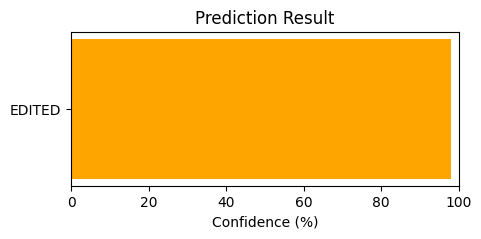

File: G020-119.png
Predicted: EDITED
Confidence: 99.74 %


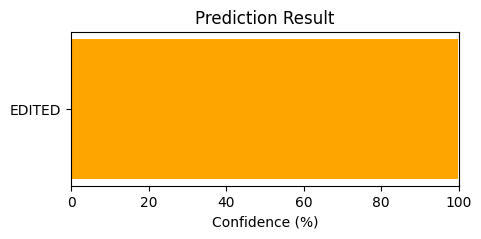

File: E035-002.png
Predicted: EDITED
Confidence: 99.53 %


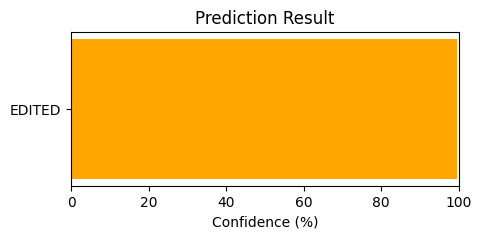

File: E146-014.png
Predicted: EDITED
Confidence: 99.98 %


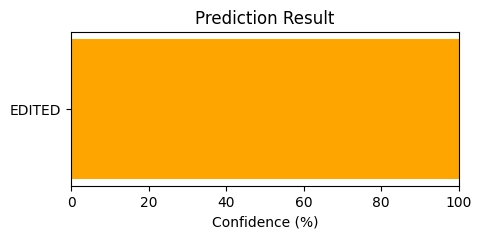

File: F041-019.png
Predicted: EDITED
Confidence: 98.55 %


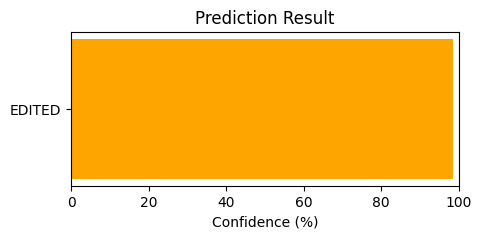

File: E127-113.png
Predicted: EDITED
Confidence: 99.84 %


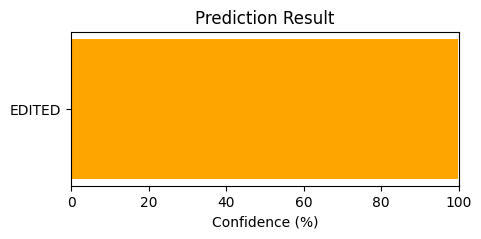

File: G001-101.png
Predicted: EDITED
Confidence: 99.78 %


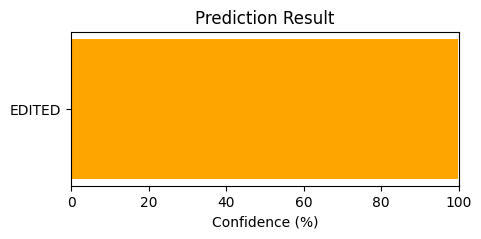

File: F014-310.png
Predicted: EDITED
Confidence: 99.87 %


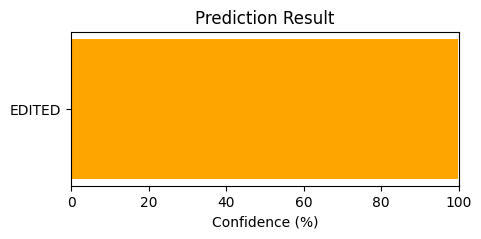

File: F019-037.png
Predicted: EDITED
Confidence: 91.75 %


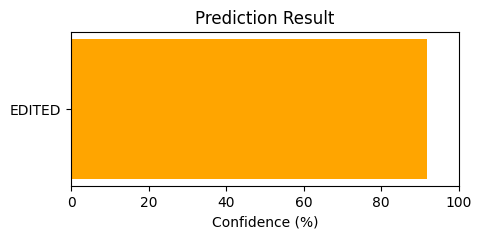

File: F011-109.png
Predicted: EDITED
Confidence: 99.42 %


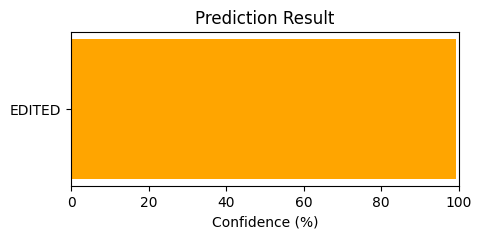

File: F026-002.png
Predicted: EDITED
Confidence: 99.26 %


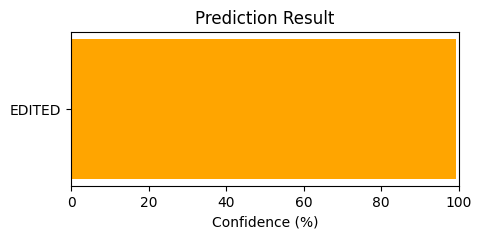

File: G009-227.png
Predicted: EDITED
Confidence: 99.87 %


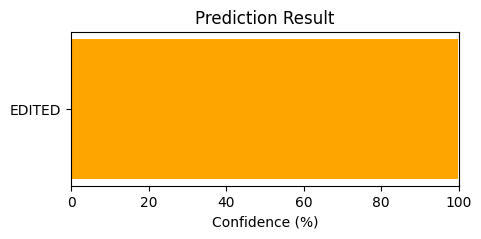

File: F030-024.png
Predicted: EDITED
Confidence: 99.87 %


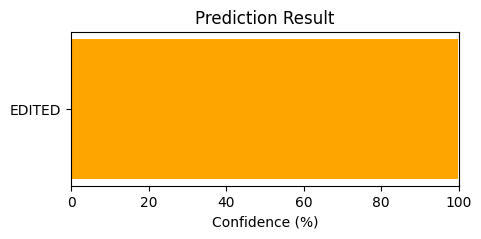

File: F013-030.png
Predicted: EDITED
Confidence: 97.8 %


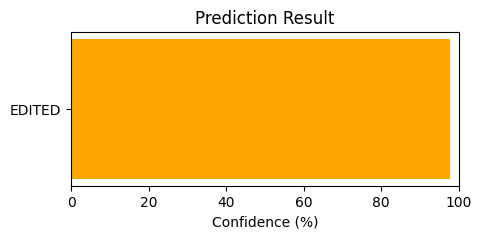

File: E034-008.png
Predicted: EDITED
Confidence: 95.92 %


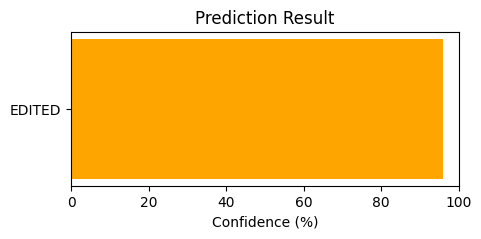

File: F054-005.png
Predicted: EDITED
Confidence: 99.51 %


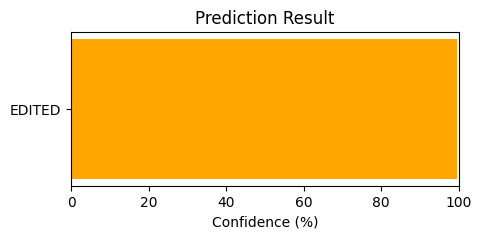

File: F004-022.png
Predicted: EDITED
Confidence: 99.16 %


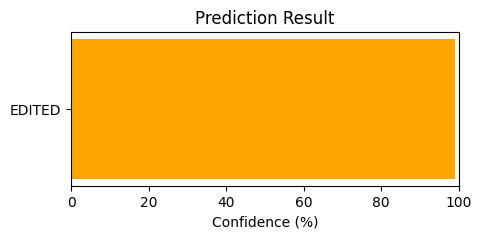

File: F020-208.png
Predicted: EDITED
Confidence: 99.94 %


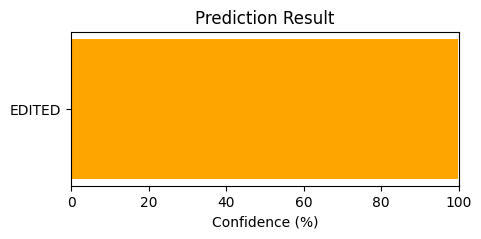

File: G005-028.png
Predicted: EDITED
Confidence: 99.48 %


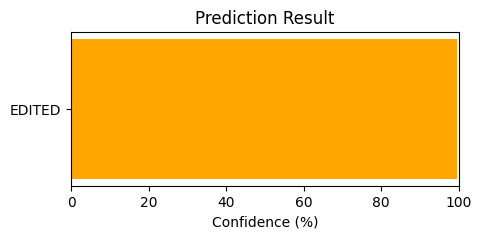

File: E039-002.png
Predicted: EDITED
Confidence: 99.82 %


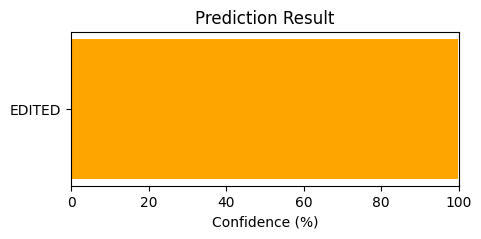

File: F025-045.png
Predicted: EDITED
Confidence: 98.73 %


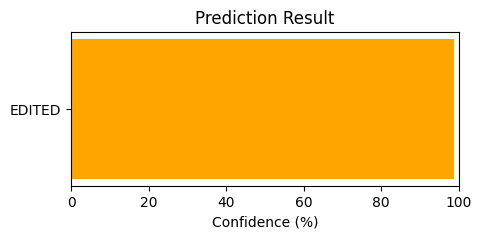

File: F048-048.png
Predicted: EDITED
Confidence: 99.69 %


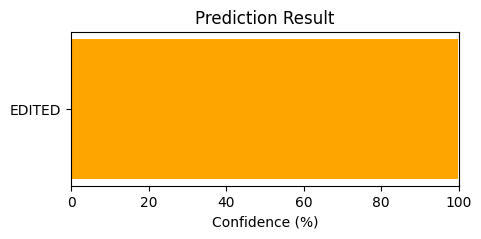

File: G015-110.png
Predicted: EDITED
Confidence: 99.69 %


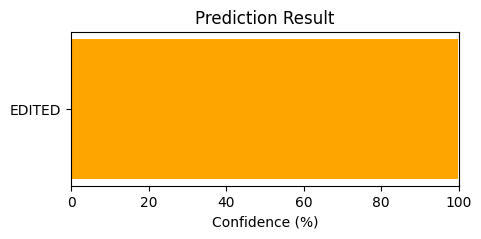

File: F022-137.png
Predicted: EDITED
Confidence: 99.77 %


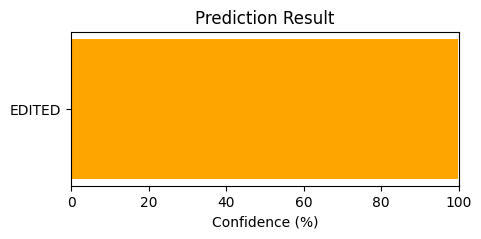

File: E145-014.png
Predicted: EDITED
Confidence: 99.23 %


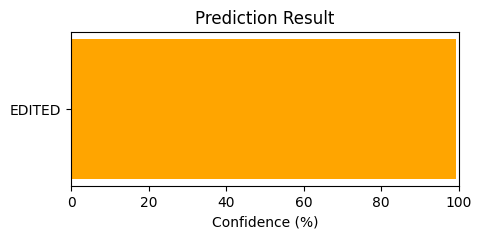

File: F036-121.png
Predicted: EDITED
Confidence: 99.9 %


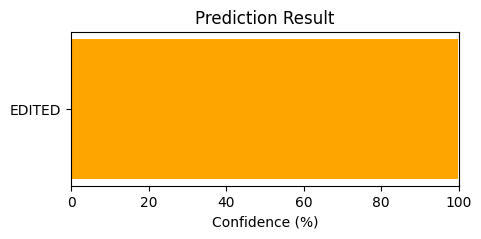

File: G019-009.png
Predicted: EDITED
Confidence: 99.93 %


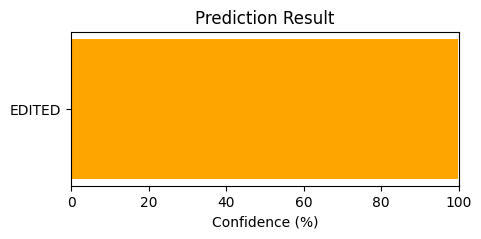

File: F018-029.png
Predicted: EDITED
Confidence: 99.83 %


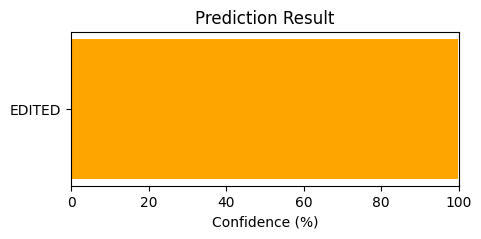

File: G017-013.png
Predicted: EDITED
Confidence: 99.88 %


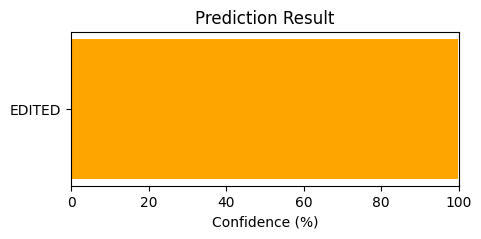

File: E075-004.png
Predicted: EDITED
Confidence: 99.9 %


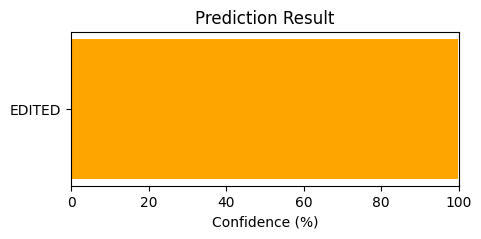

File: F033-430.png
Predicted: EDITED
Confidence: 99.45 %


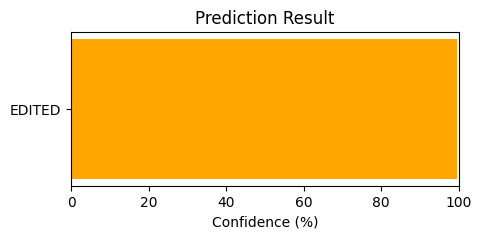

File: F050-056.png
Predicted: EDITED
Confidence: 98.63 %


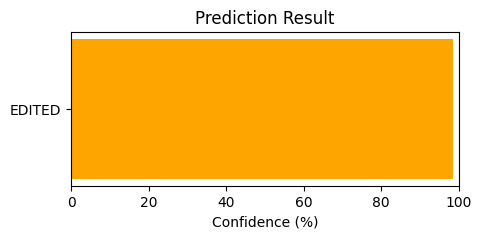

File: H022-144.png
Predicted: EDITED
Confidence: 99.47 %


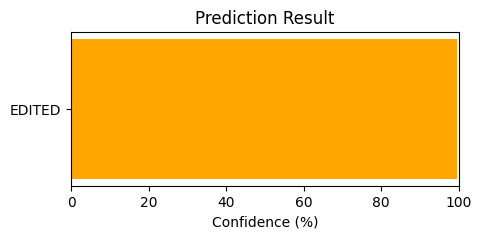

File: G021-111.png
Predicted: EDITED
Confidence: 98.95 %


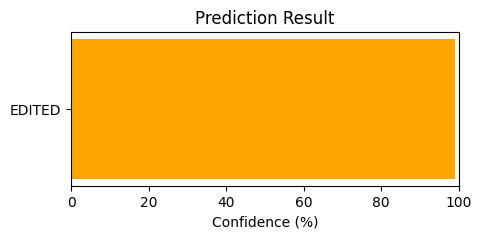

File: G029-038.png
Predicted: EDITED
Confidence: 99.98 %


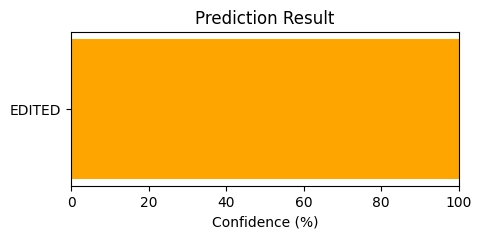

File: G040-445.png
Predicted: EDITED
Confidence: 99.74 %


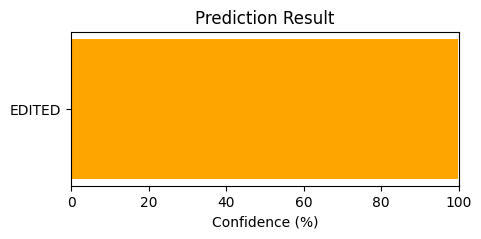

File: H013-115.png
Predicted: EDITED
Confidence: 99.74 %


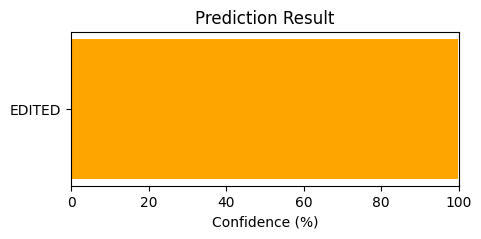

File: G048-008.png
Predicted: EDITED
Confidence: 99.9 %


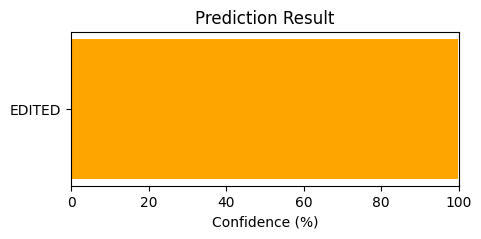

File: H031-028.png
Predicted: EDITED
Confidence: 99.99 %


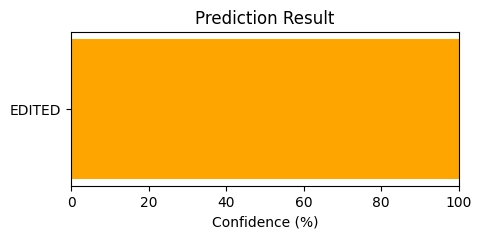

File: G052-133.png
Predicted: EDITED
Confidence: 99.86 %


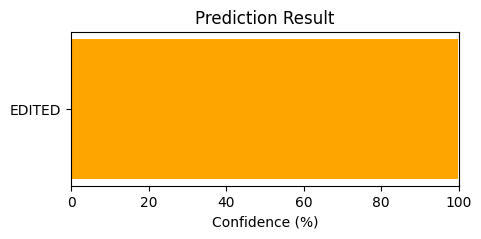

File: G042-129.png
Predicted: EDITED
Confidence: 99.64 %


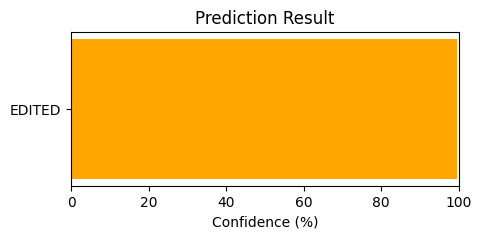

File: H018-037.png
Predicted: EDITED
Confidence: 97.95 %


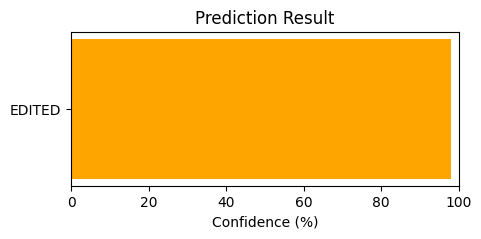

File: H035-013.png
Predicted: EDITED
Confidence: 98.09 %


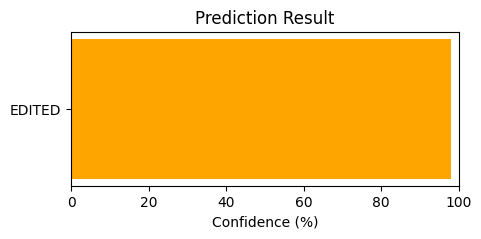

File: H027-015.png
Predicted: EDITED
Confidence: 99.58 %


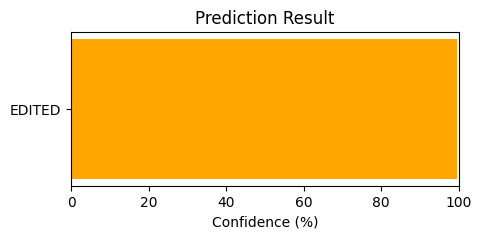

File: H043-140.png
Predicted: EDITED
Confidence: 99.99 %


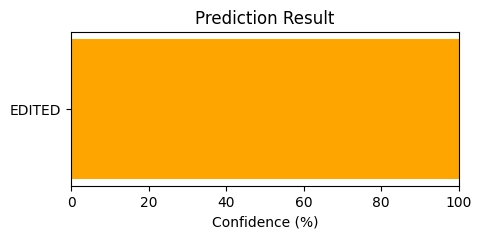

File: H026-018.png
Predicted: EDITED
Confidence: 97.26 %


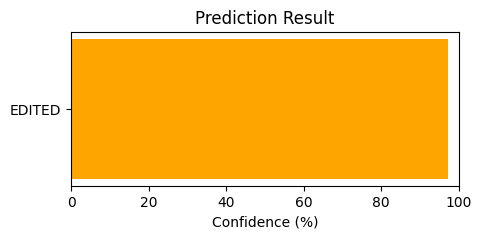

File: H049-208.png
Predicted: EDITED
Confidence: 99.89 %


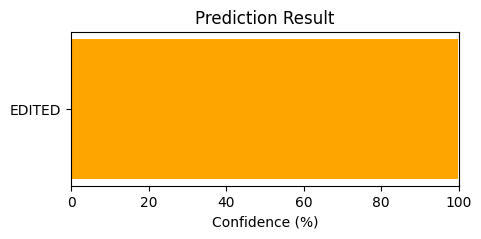

File: H023-301.png
Predicted: EDITED
Confidence: 99.2 %


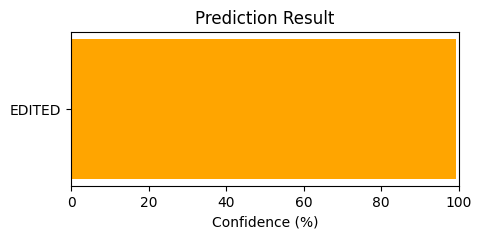

File: H011-037.png
Predicted: EDITED
Confidence: 99.66 %


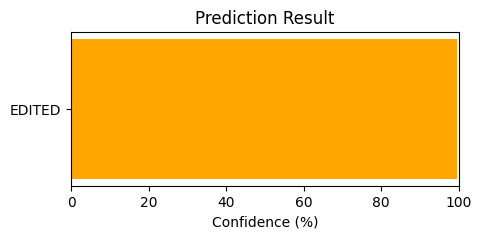

File: H008-146.png
Predicted: EDITED
Confidence: 100.0 %


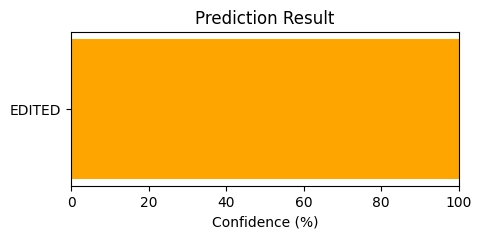

File: H042-138.png
Predicted: EDITED
Confidence: 98.28 %


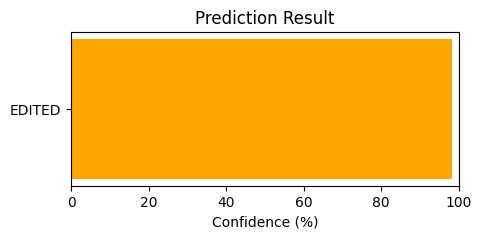

File: H014-005.png
Predicted: EDITED
Confidence: 97.66 %


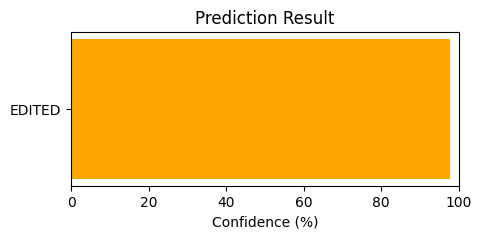

File: H048-206.png
Predicted: EDITED
Confidence: 99.6 %


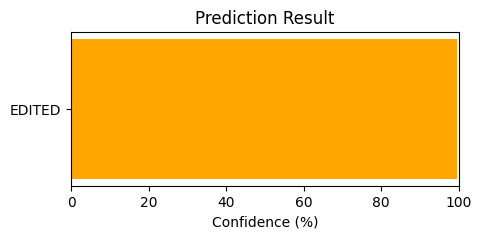

File: H036-022.png
Predicted: EDITED
Confidence: 99.43 %


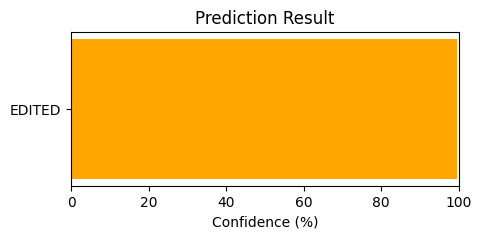

File: G044-612.png
Predicted: EDITED
Confidence: 99.91 %


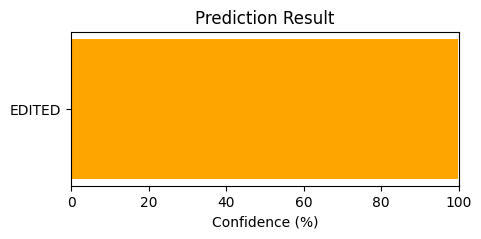

File: H010-113.png
Predicted: EDITED
Confidence: 99.81 %


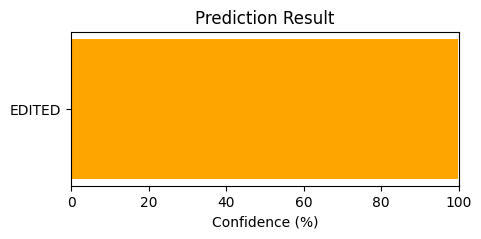

File: H040-008.png
Predicted: EDITED
Confidence: 99.98 %


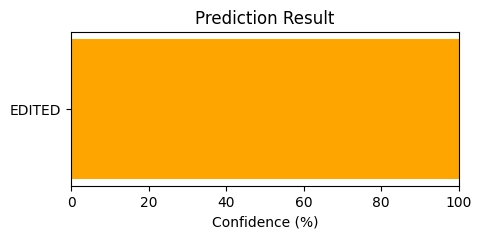

File: H024-023.png
Predicted: EDITED
Confidence: 99.21 %


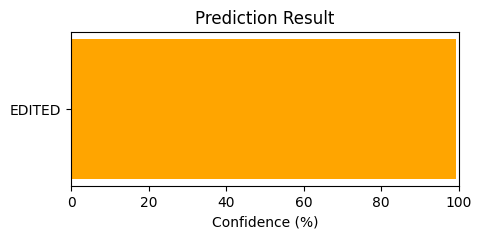

File: H028-123.png
Predicted: EDITED
Confidence: 88.9 %


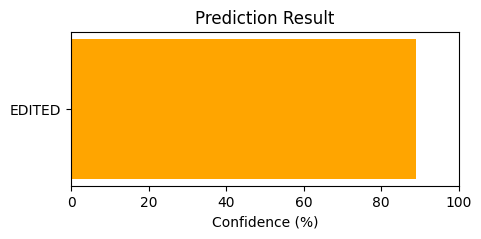

File: H017-011.png
Predicted: EDITED
Confidence: 99.89 %


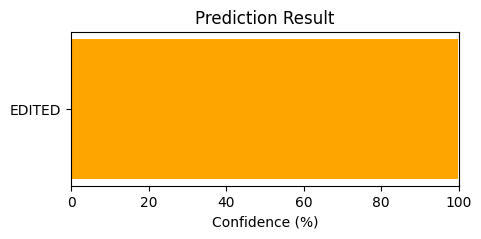

File: H015-113.png
Predicted: EDITED
Confidence: 97.76 %


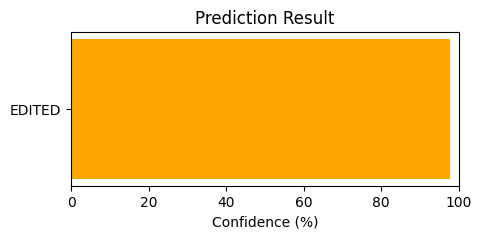

File: H033-019.png
Predicted: EDITED
Confidence: 99.27 %


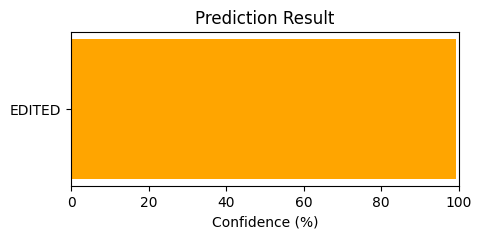

File: H020-018.png
Predicted: EDITED
Confidence: 99.26 %


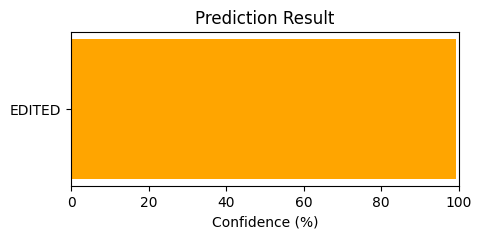

File: G031-007.png
Predicted: EDITED
Confidence: 99.81 %


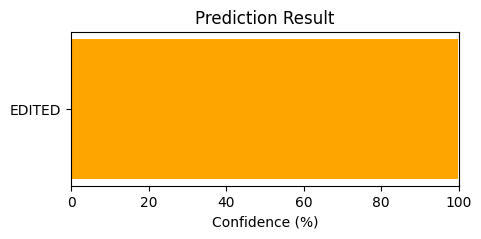

File: G049-036.png
Predicted: EDITED
Confidence: 99.89 %


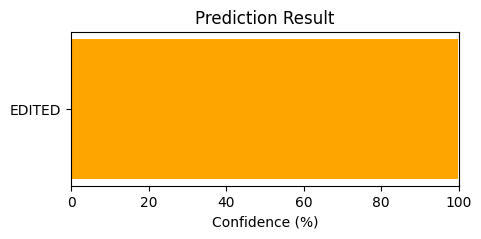

File: H034-044.png
Predicted: EDITED
Confidence: 97.17 %


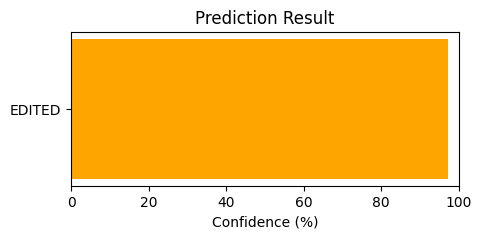

File: H001-042.png
Predicted: EDITED
Confidence: 99.71 %


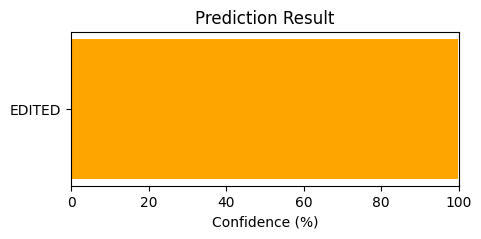

File: H012-020.png
Predicted: EDITED
Confidence: 99.93 %


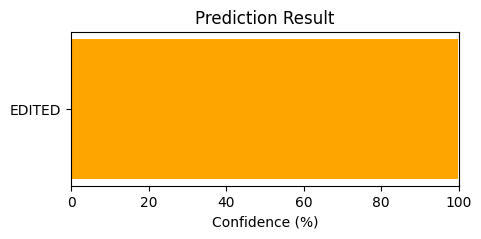


ACTUAL CATEGORY: AI GENERATED

File: B011-102.png
Predicted: AI GENERATED
Confidence: 94.22 %


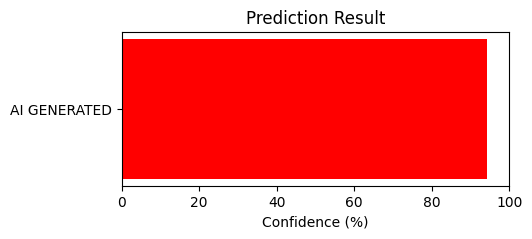

File: B004-045.png
Predicted: AI GENERATED
Confidence: 97.83 %


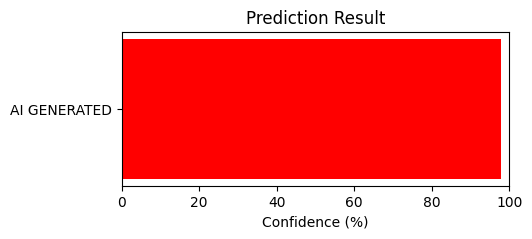

File: A018-056.png
Predicted: AI GENERATED
Confidence: 92.21 %


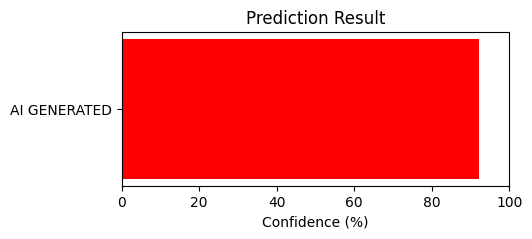

File: A024-034.png
Predicted: AI GENERATED
Confidence: 98.71 %


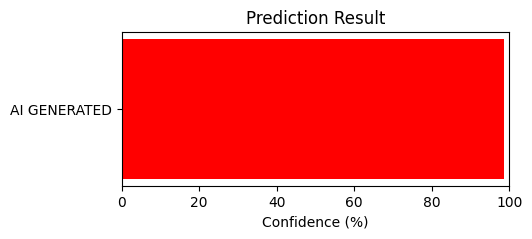

File: A025-051.png
Predicted: AI GENERATED
Confidence: 67.22 %


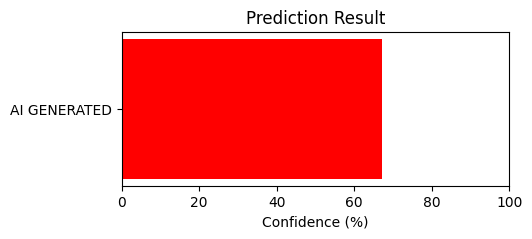

File: A042-459.png
Predicted: AI GENERATED
Confidence: 99.59 %


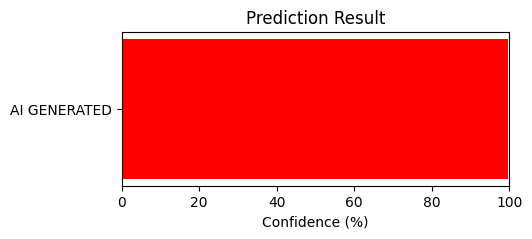

File: A027-106.png
Predicted: AI GENERATED
Confidence: 99.99 %


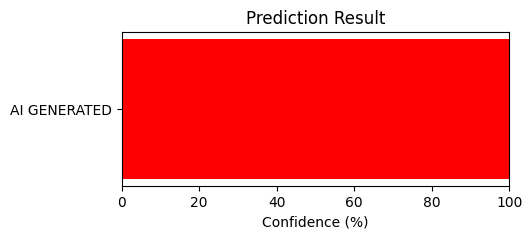

File: B015-017.png
Predicted: AI GENERATED
Confidence: 98.87 %


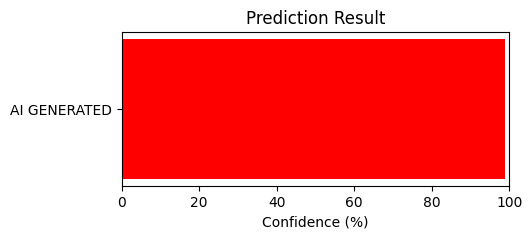

File: A008-229.png
Predicted: AI GENERATED
Confidence: 96.43 %


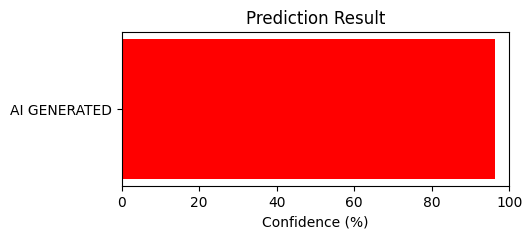

File: A005-023.png
Predicted: AI GENERATED
Confidence: 99.81 %


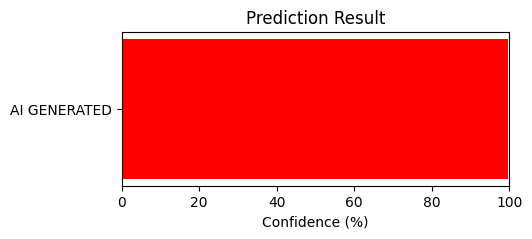

File: B022-045.png
Predicted: AI GENERATED
Confidence: 85.58 %


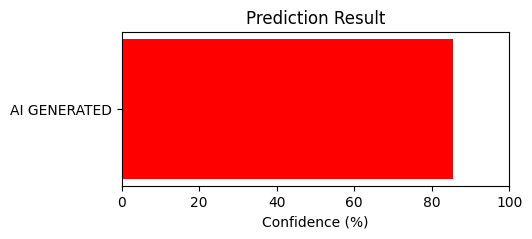

File: B005-051.png
Predicted: AI GENERATED
Confidence: 99.86 %


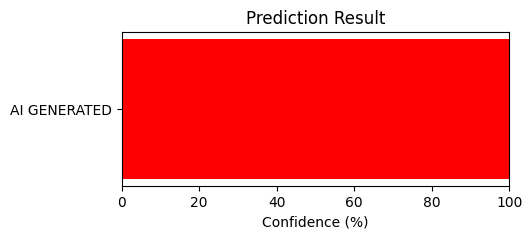

File: A035-116.png
Predicted: AI GENERATED
Confidence: 99.51 %


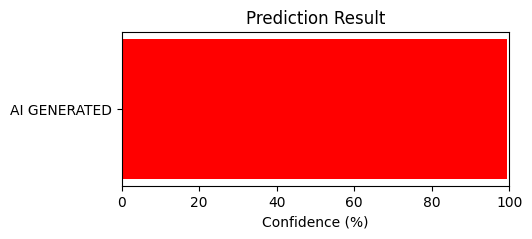

File: A037-005.png
Predicted: AI GENERATED
Confidence: 87.89 %


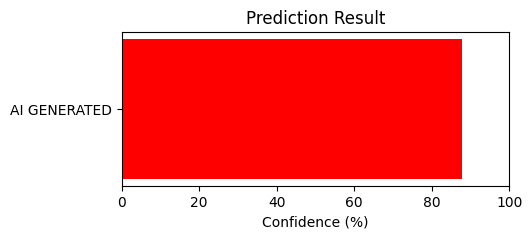

File: A013-004.png
Predicted: AI GENERATED
Confidence: 99.99 %


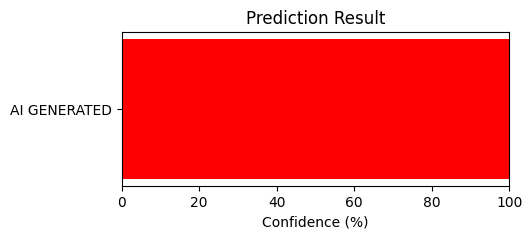

File: A026-008.png
Predicted: AI GENERATED
Confidence: 83.52 %


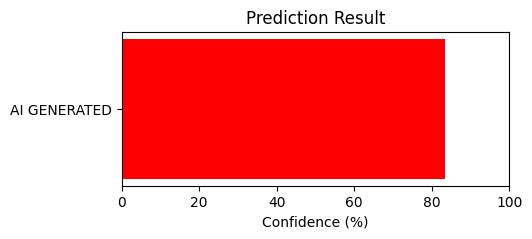

File: A050-200.png
Predicted: AI GENERATED
Confidence: 98.79 %


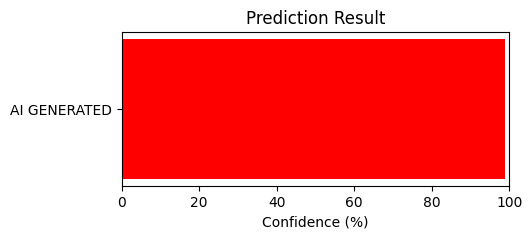

File: A049-021.png
Predicted: AI GENERATED
Confidence: 99.74 %


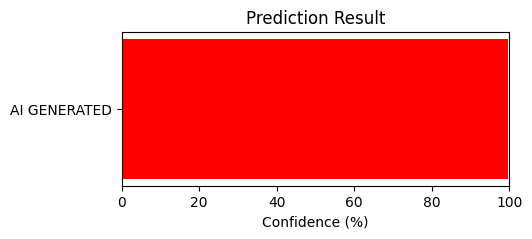

File: A033-052.png
Predicted: AI GENERATED
Confidence: 99.94 %


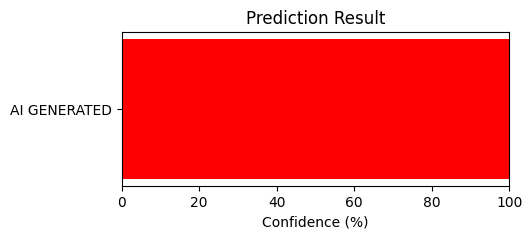

File: A023-033.png
Predicted: AI GENERATED
Confidence: 99.33 %


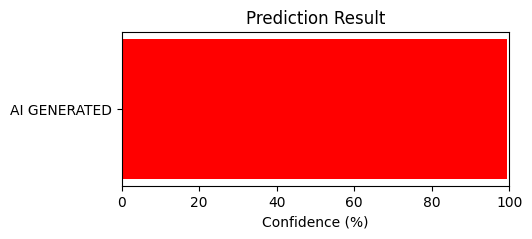

File: A045-215.png
Predicted: AI GENERATED
Confidence: 92.08 %


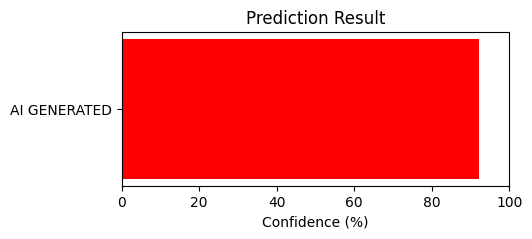

File: B001-047.png
Predicted: AI GENERATED
Confidence: 75.02 %


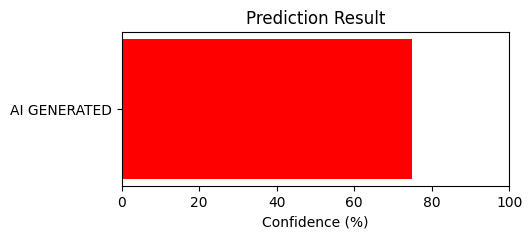

File: A001-010.png
Predicted: AI GENERATED
Confidence: 99.8 %


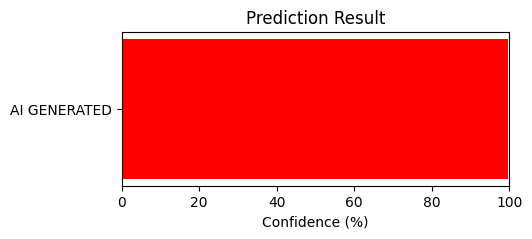

File: A003-032.png
Predicted: AI GENERATED
Confidence: 92.75 %


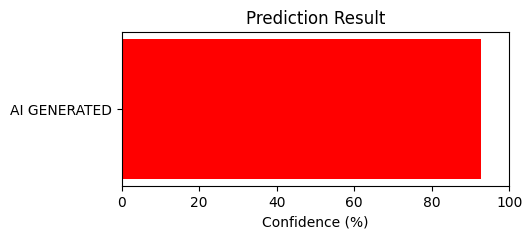

File: A048-135.png
Predicted: AI GENERATED
Confidence: 99.11 %


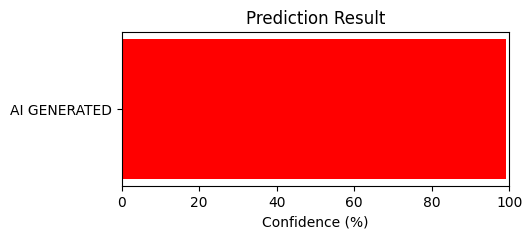

File: A031-024.png
Predicted: AI GENERATED
Confidence: 73.01 %


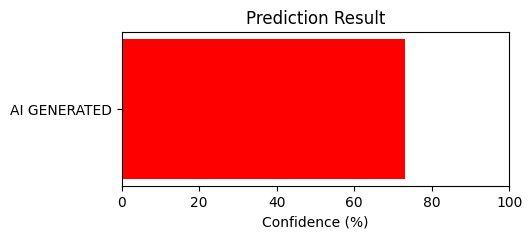

File: B007-056.png
Predicted: AI GENERATED
Confidence: 96.88 %


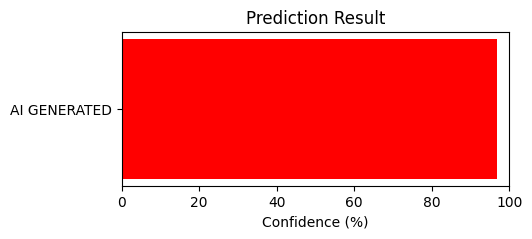

File: B021-354.png
Predicted: AI GENERATED
Confidence: 90.77 %


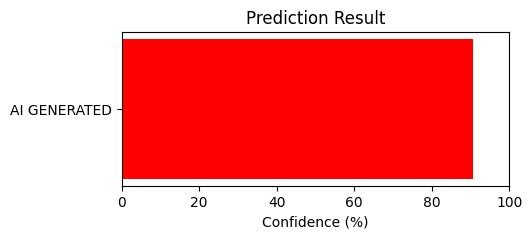

File: A017-047.png
Predicted: AI GENERATED
Confidence: 97.06 %


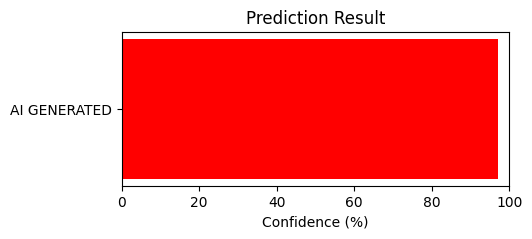

File: B017-110.png
Predicted: AI GENERATED
Confidence: 99.93 %


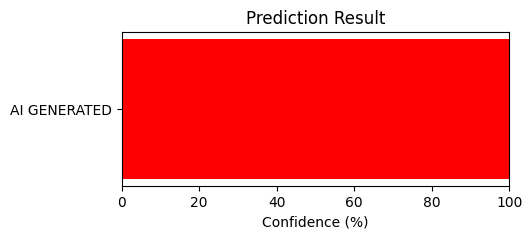

File: A040-126.png
Predicted: AI GENERATED
Confidence: 99.16 %


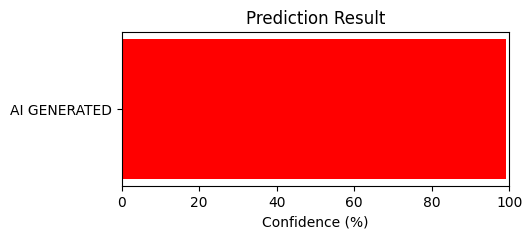

File: B031-053.png
Predicted: AI GENERATED
Confidence: 99.96 %


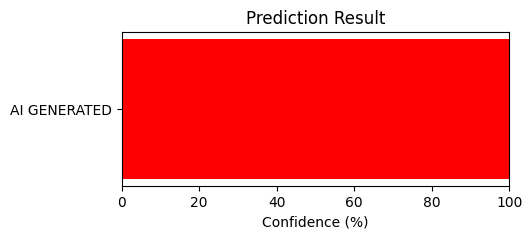

File: C032-006.png
Predicted: AI GENERATED
Confidence: 98.19 %


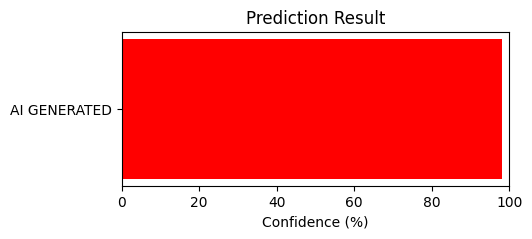

File: C030-033.png
Predicted: AI GENERATED
Confidence: 99.96 %


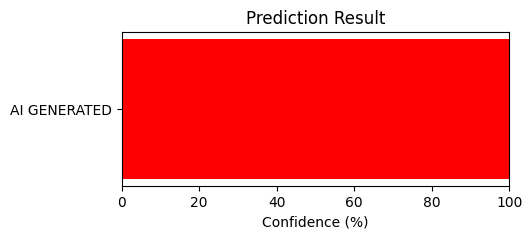

File: B032-047.png
Predicted: AI GENERATED
Confidence: 93.64 %


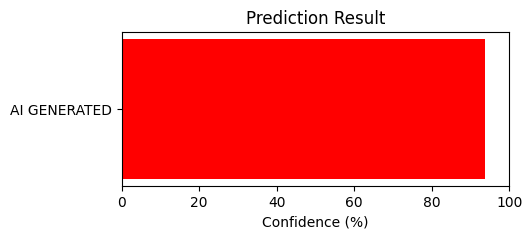

File: C020-055.png
Predicted: AI GENERATED
Confidence: 77.48 %


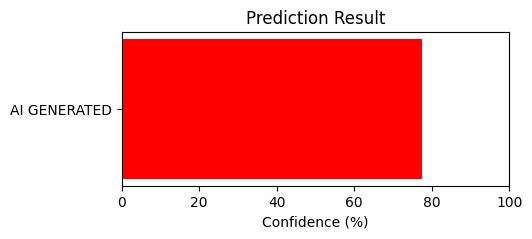

File: C018-017.png
Predicted: AI GENERATED
Confidence: 98.95 %


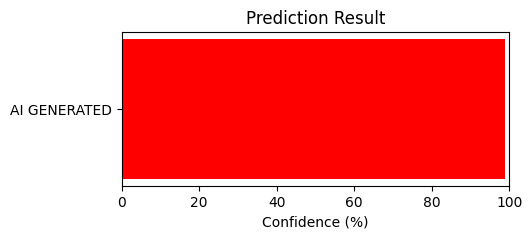

File: C001-103.png
Predicted: AI GENERATED
Confidence: 99.99 %


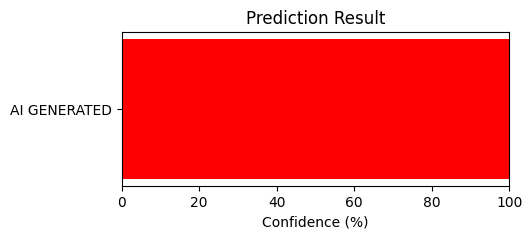

File: C014-038.png
Predicted: AI GENERATED
Confidence: 95.04 %


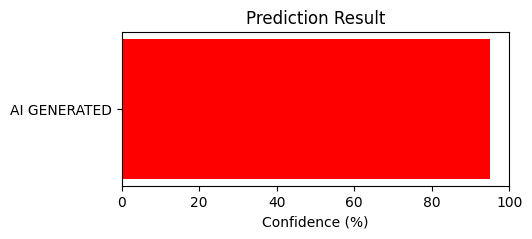

File: C006-121.png
Predicted: AI GENERATED
Confidence: 96.76 %


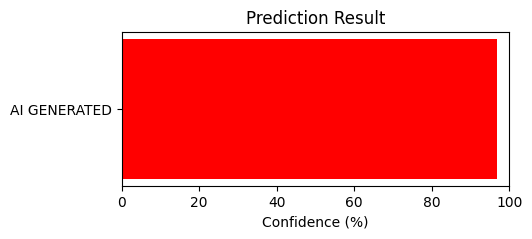

File: C038-004.png
Predicted: AI GENERATED
Confidence: 99.5 %


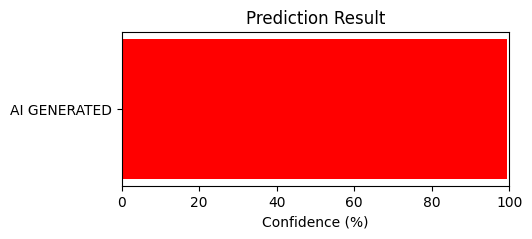

File: C025-040.png
Predicted: EDITED
Confidence: 90.11 %


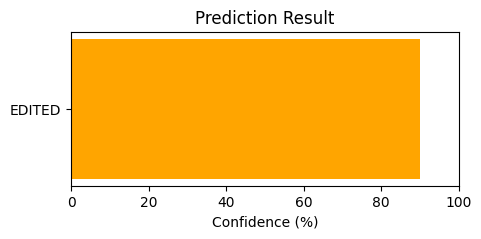

File: B046-304.png
Predicted: AI GENERATED
Confidence: 49.18 %


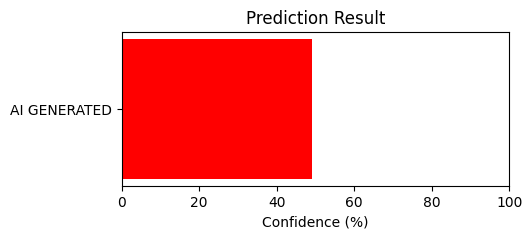

File: B044-136.png
Predicted: AI GENERATED
Confidence: 99.82 %


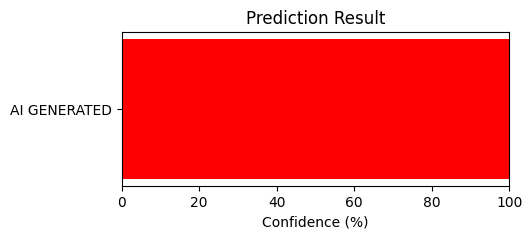

File: B048-131.png
Predicted: AI GENERATED
Confidence: 92.28 %


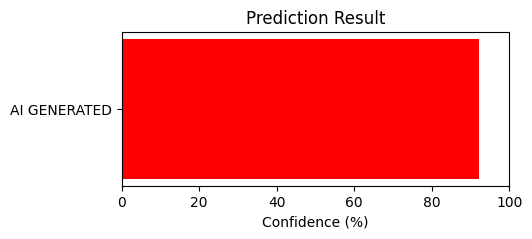

File: C002-134.png
Predicted: AI GENERATED
Confidence: 99.99 %


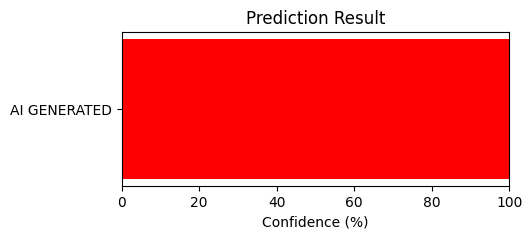

File: C051-022.png
Predicted: AI GENERATED
Confidence: 81.53 %


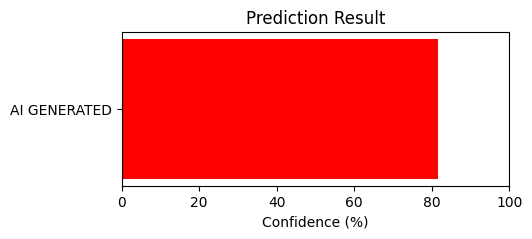

File: B029-357.png
Predicted: AI GENERATED
Confidence: 99.84 %


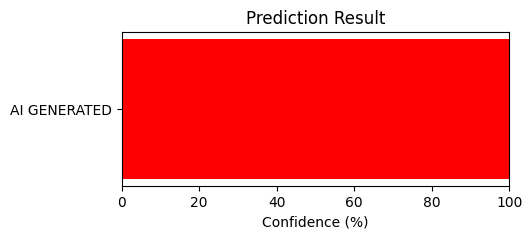

File: C005-005.png
Predicted: AI GENERATED
Confidence: 82.59 %


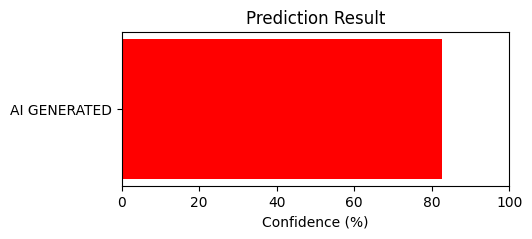

File: C044-034.png
Predicted: AI GENERATED
Confidence: 97.24 %


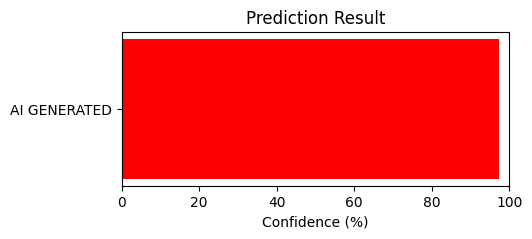

File: B039-500.png
Predicted: AI GENERATED
Confidence: 94.42 %


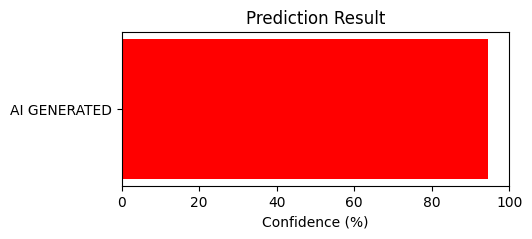

File: B040-037.png
Predicted: AI GENERATED
Confidence: 99.06 %


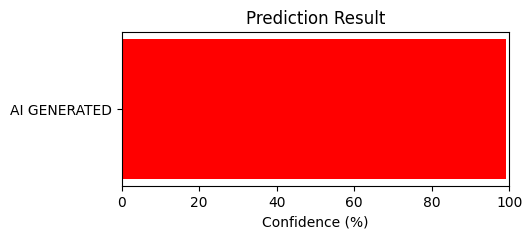

File: C023-016.png
Predicted: AI GENERATED
Confidence: 99.13 %


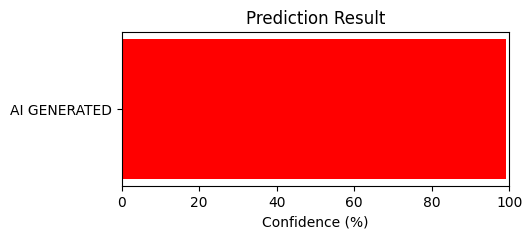

File: B025-024.png
Predicted: AI GENERATED
Confidence: 99.87 %


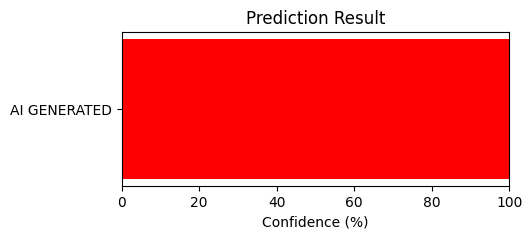

File: C003-005.png
Predicted: AI GENERATED
Confidence: 84.01 %


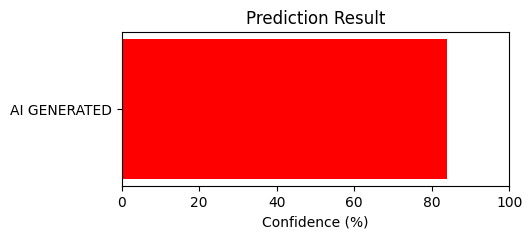

File: C015-355.png
Predicted: EDITED
Confidence: 74.64 %


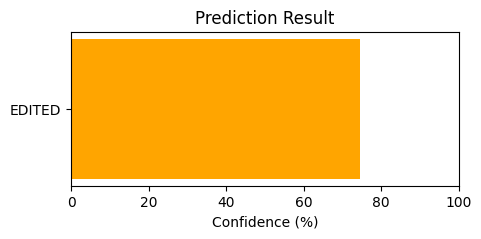

File: C031-041.png
Predicted: AI GENERATED
Confidence: 99.97 %


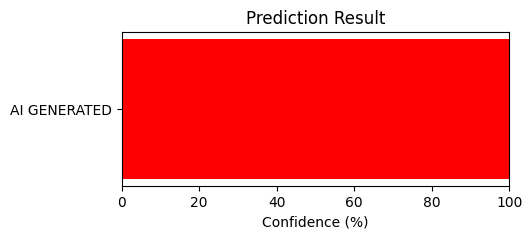

File: C016-039.png
Predicted: AI GENERATED
Confidence: 99.95 %


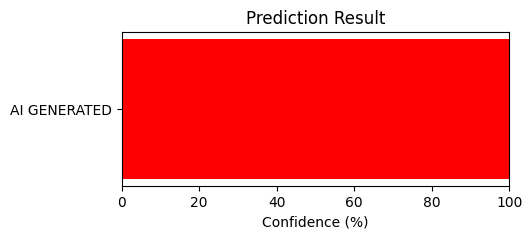

File: C013-302.png
Predicted: AI GENERATED
Confidence: 98.25 %


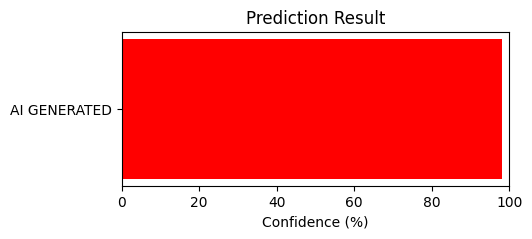

File: B028-034.png
Predicted: EDITED
Confidence: 49.19 %


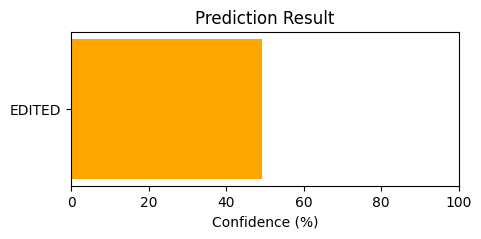

File: C049-005.png
Predicted: AI GENERATED
Confidence: 68.95 %


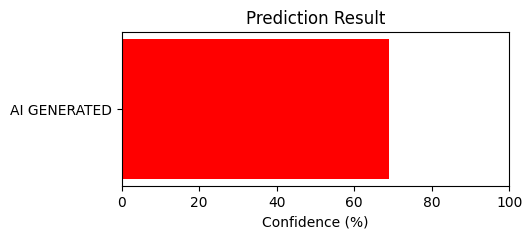

File: B035-247.png
Predicted: AI GENERATED
Confidence: 99.98 %


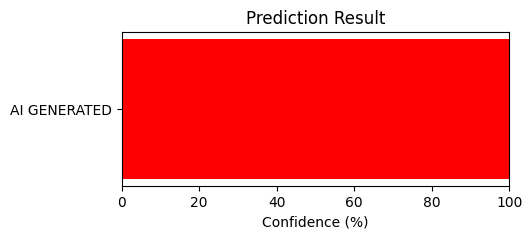

File: C021-038.png
Predicted: AI GENERATED
Confidence: 99.98 %


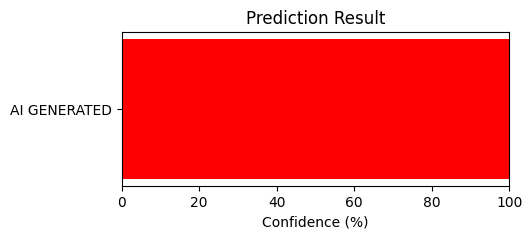

File: B023-048.png
Predicted: AI GENERATED
Confidence: 85.07 %


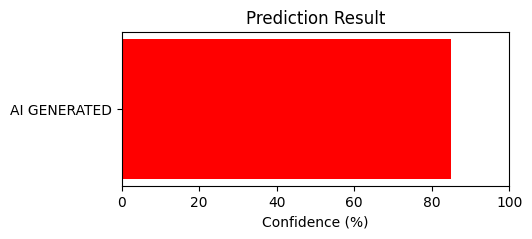

File: C029-029.png
Predicted: AI GENERATED
Confidence: 94.68 %


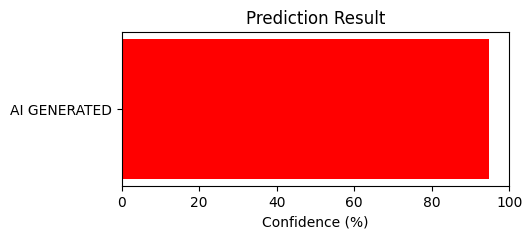

File: C009-009.png
Predicted: AI GENERATED
Confidence: 63.13 %


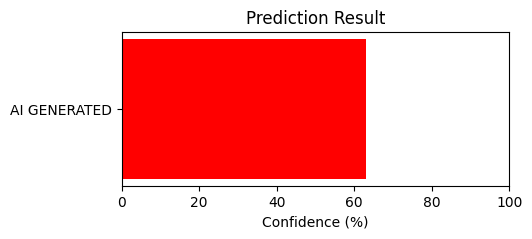

File: B037-012.png
Predicted: AI GENERATED
Confidence: 99.24 %


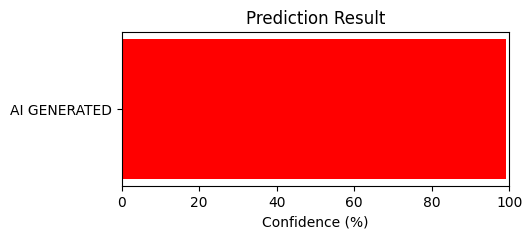

File: B049-327.png
Predicted: AI GENERATED
Confidence: 98.82 %


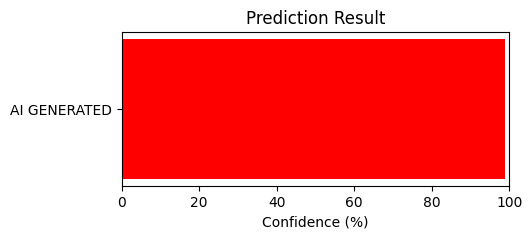

File: C010-120.png
Predicted: AI GENERATED
Confidence: 97.45 %


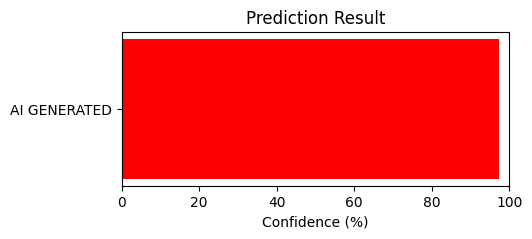

File: C052-041.png
Predicted: AI GENERATED
Confidence: 96.66 %


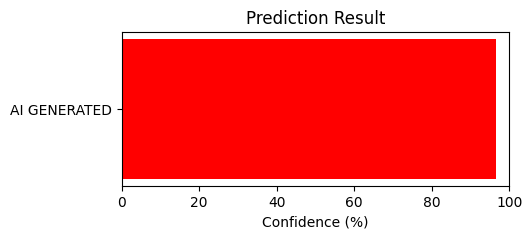

File: B043-118.png
Predicted: AI GENERATED
Confidence: 99.76 %


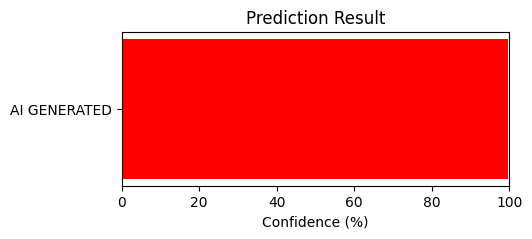

File: C027-105.png
Predicted: AI GENERATED
Confidence: 99.4 %


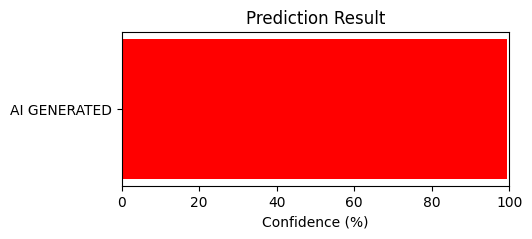

File: C007-209.png
Predicted: AI GENERATED
Confidence: 99.99 %


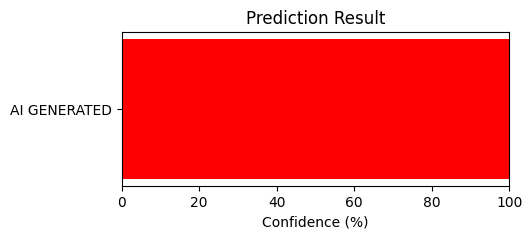

File: B026-215.png
Predicted: AI GENERATED
Confidence: 99.55 %


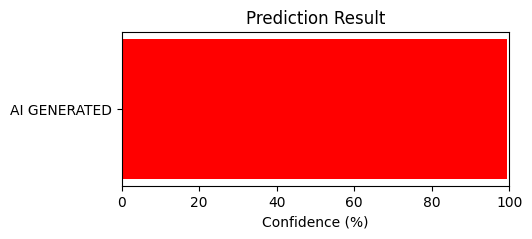

File: C028-106.png
Predicted: EDITED
Confidence: 80.67 %


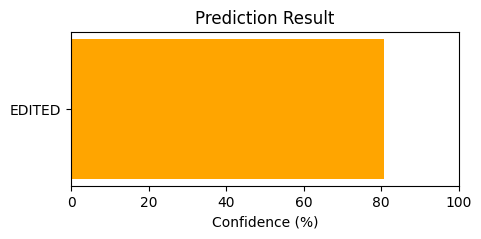

File: C022-159.png
Predicted: EDITED
Confidence: 54.9 %


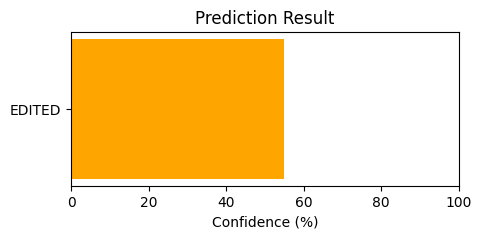

File: C042-301.png
Predicted: AI GENERATED
Confidence: 96.91 %


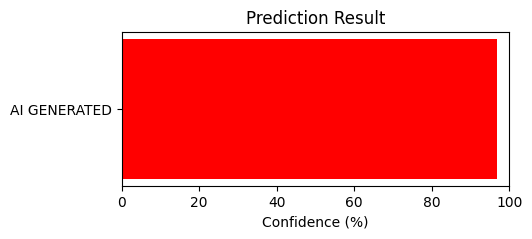

File: C008-011.png
Predicted: EDITED
Confidence: 83.66 %


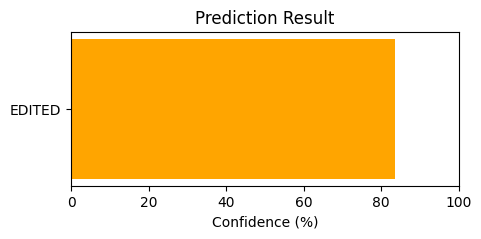

File: E029-004.png
Predicted: EDITED
Confidence: 85.11 %


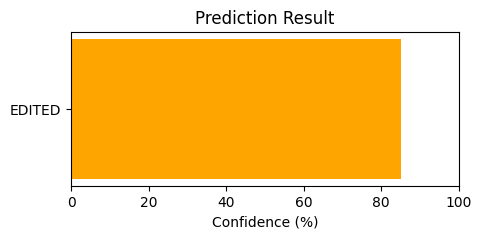

File: D010-142.png
Predicted: EDITED
Confidence: 88.73 %


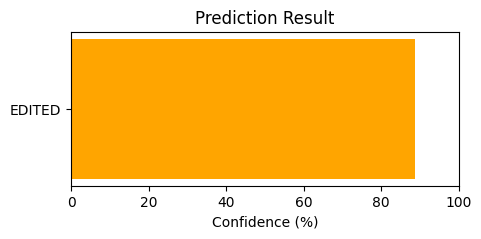

File: D020-114.png
Predicted: REAL
Confidence: 100.0 %


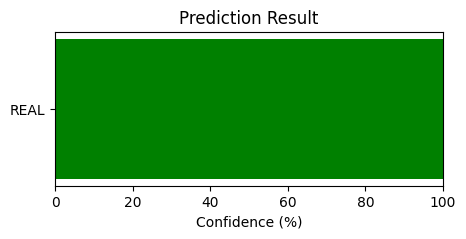

File: E032-020.png
Predicted: REAL
Confidence: 61.27 %


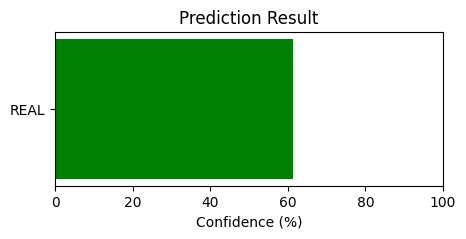

File: D016-121.png
Predicted: REAL
Confidence: 100.0 %


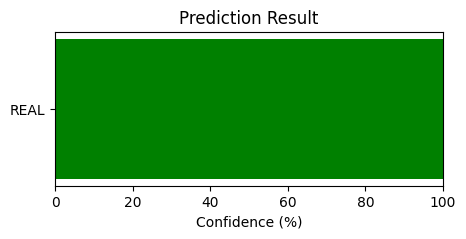

File: E030-036.png
Predicted: EDITED
Confidence: 98.51 %


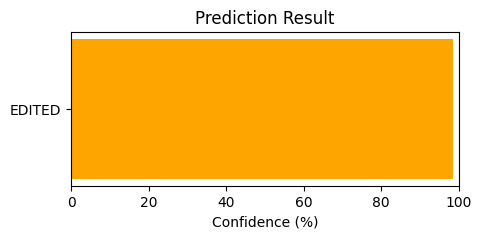

File: D031-112.png
Predicted: REAL
Confidence: 77.93 %


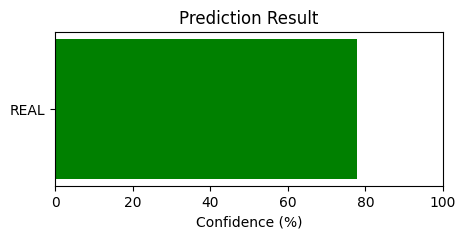

File: E004-005.png
Predicted: EDITED
Confidence: 93.96 %


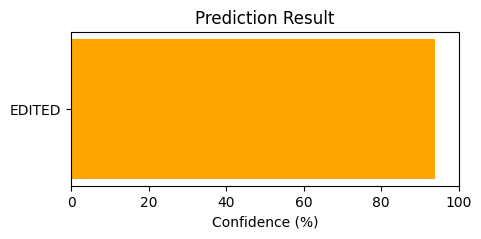

File: D004-015.png
Predicted: REAL
Confidence: 66.7 %


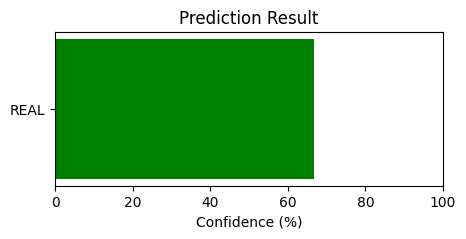

File: E002-010.png
Predicted: REAL
Confidence: 99.97 %


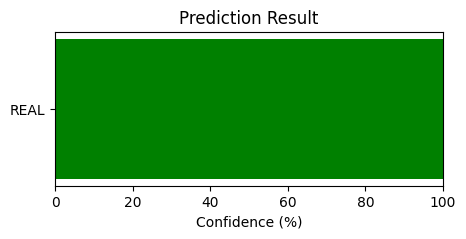

File: D027-036.png
Predicted: REAL
Confidence: 99.65 %


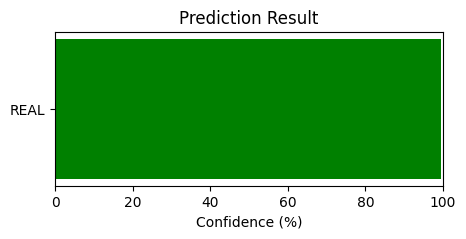

File: D012-025.png
Predicted: REAL
Confidence: 99.59 %


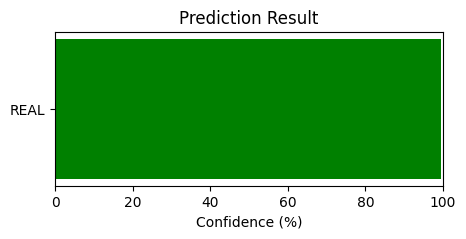

File: D048-025.png
Predicted: REAL
Confidence: 78.57 %


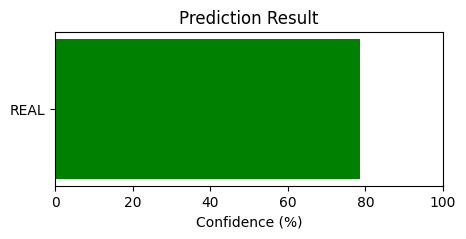

File: D022-114.png
Predicted: AI GENERATED
Confidence: 89.49 %


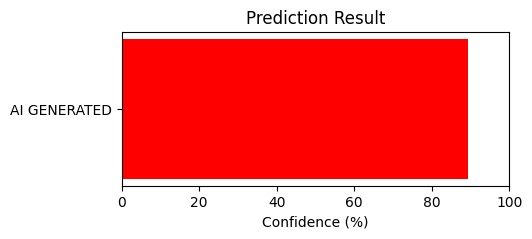

File: E011-009.png
Predicted: REAL
Confidence: 54.49 %


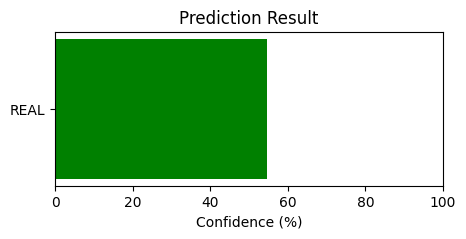

File: D019-008.png
Predicted: REAL
Confidence: 87.95 %


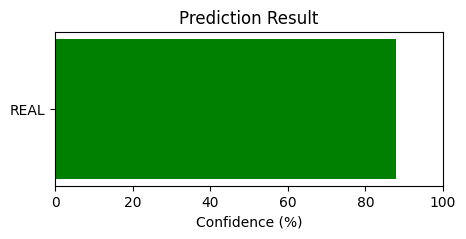

File: D006-331.png
Predicted: EDITED
Confidence: 39.75 %


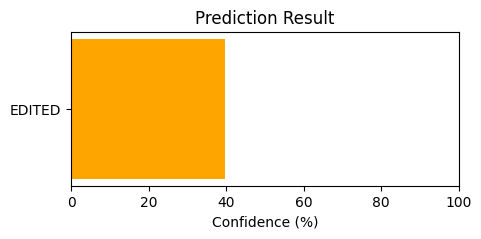

File: D007-030.png
Predicted: REAL
Confidence: 99.99 %


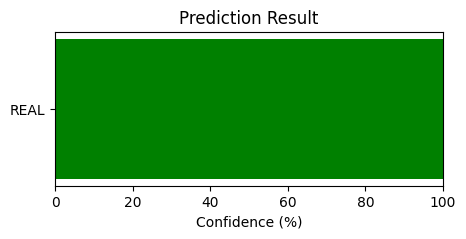

File: D017-047.png
Predicted: EDITED
Confidence: 89.95 %


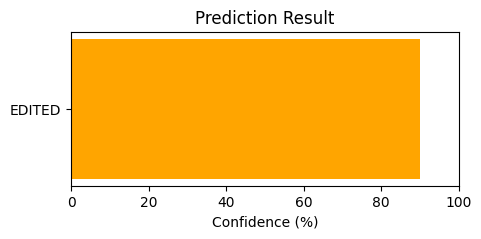

File: D045-215.png
Predicted: REAL
Confidence: 99.9 %


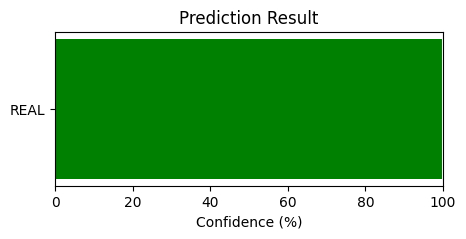

File: E012-009.png
Predicted: EDITED
Confidence: 95.45 %


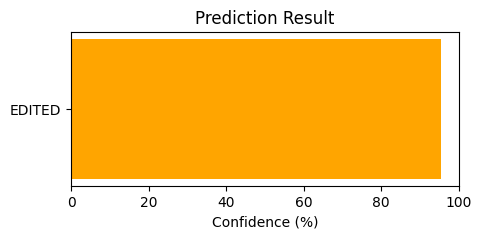

File: D046-053.png
Predicted: REAL
Confidence: 97.73 %


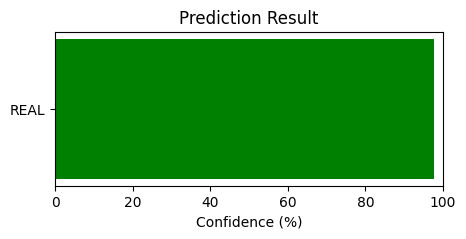

File: E019-027.png
Predicted: EDITED
Confidence: 93.17 %


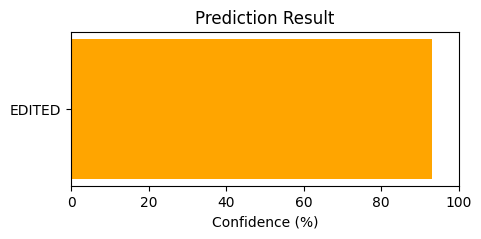

File: D026-037.png
Predicted: EDITED
Confidence: 82.29 %


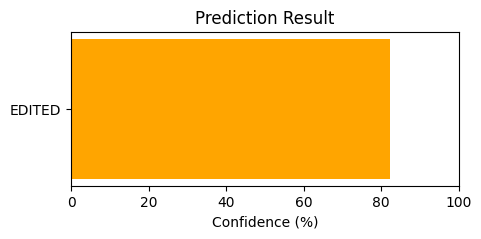

File: E013-015.png
Predicted: EDITED
Confidence: 46.67 %


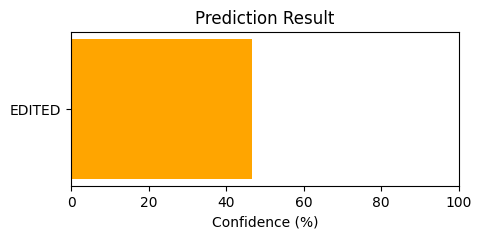

File: E027-003.png
Predicted: EDITED
Confidence: 92.28 %


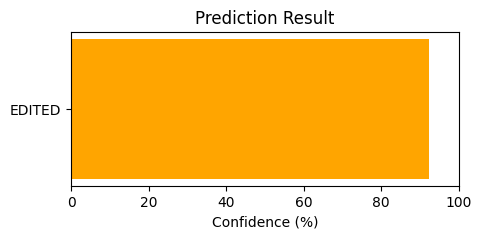

File: D013-029.png
Predicted: REAL
Confidence: 100.0 %


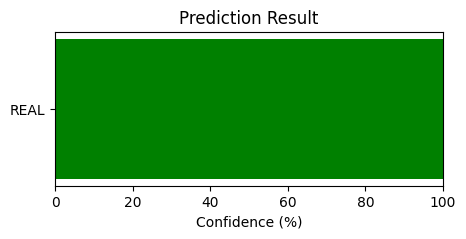

File: D021-040.png
Predicted: AI GENERATED
Confidence: 86.99 %


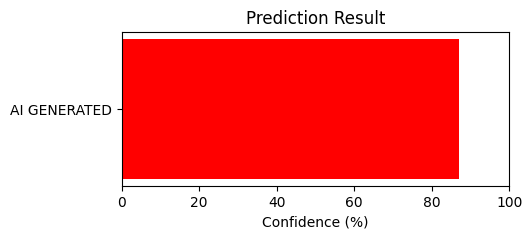

File: D009-033.png
Predicted: AI GENERATED
Confidence: 95.22 %


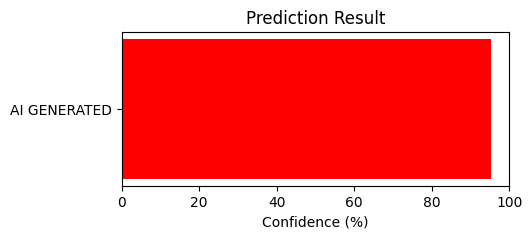

File: E020-022.png
Predicted: REAL
Confidence: 91.81 %


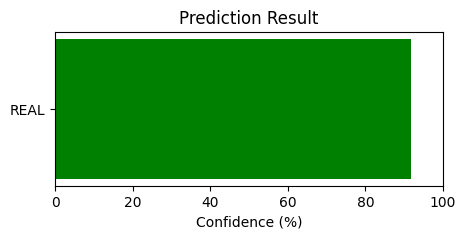

File: D002-128.png
Predicted: REAL
Confidence: 99.39 %


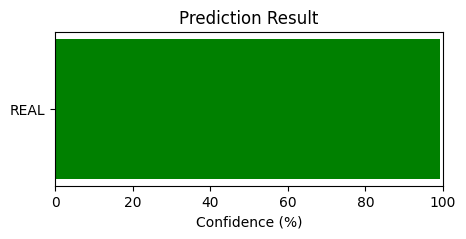

File: D001-049.png
Predicted: REAL
Confidence: 72.92 %


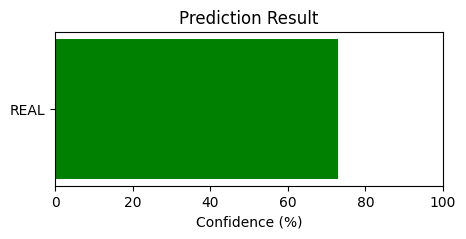

File: E028-016.png
Predicted: REAL
Confidence: 82.58 %


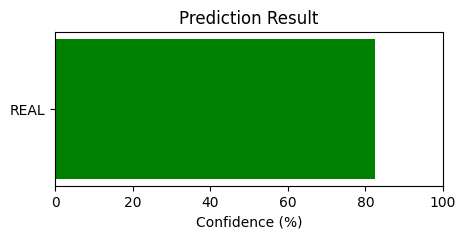

File: E021-002.png
Predicted: REAL
Confidence: 99.8 %


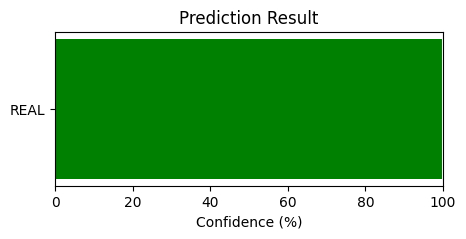

File: E010-008.png
Predicted: EDITED
Confidence: 84.15 %


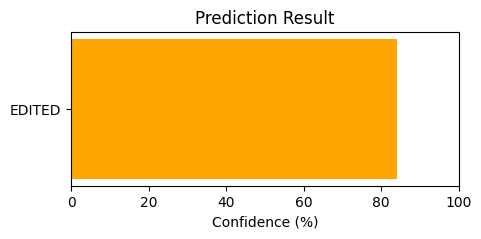

File: E031-002.png
Predicted: REAL
Confidence: 54.78 %


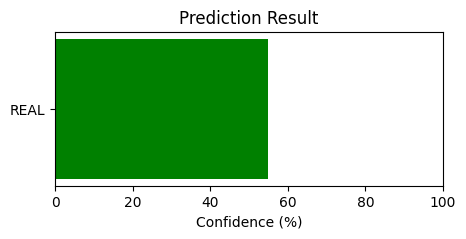

File: G010-028.png
Predicted: REAL
Confidence: 100.0 %


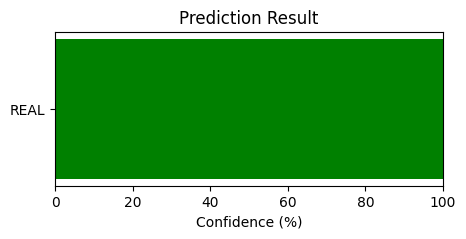

File: F028-009.png
Predicted: REAL
Confidence: 91.7 %


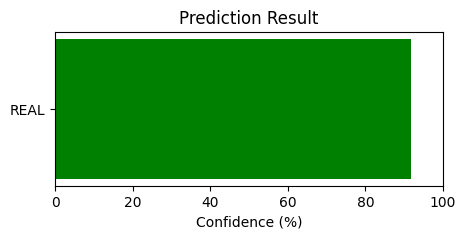

File: F023-012.png
Predicted: REAL
Confidence: 99.97 %


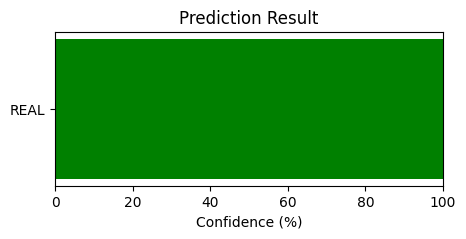

File: F031-045.png
Predicted: REAL
Confidence: 99.85 %


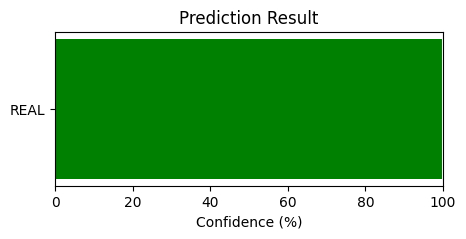

File: F017-021.png
Predicted: EDITED
Confidence: 92.69 %


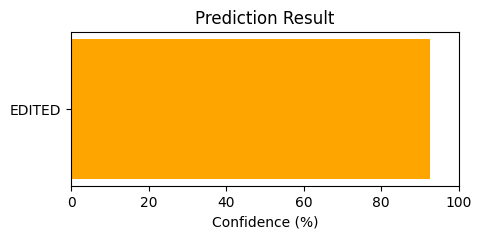

File: F039-023.png
Predicted: REAL
Confidence: 99.78 %


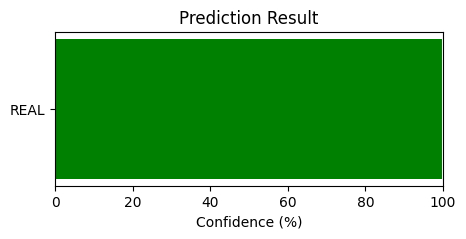

File: G016-023.png
Predicted: EDITED
Confidence: 95.82 %


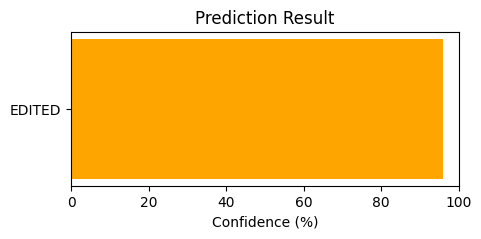

File: G008-253.png
Predicted: AI GENERATED
Confidence: 99.99 %


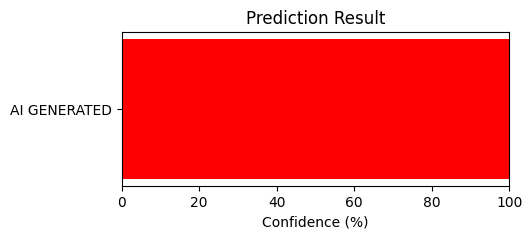

File: G020-119.png
Predicted: AI GENERATED
Confidence: 93.45 %


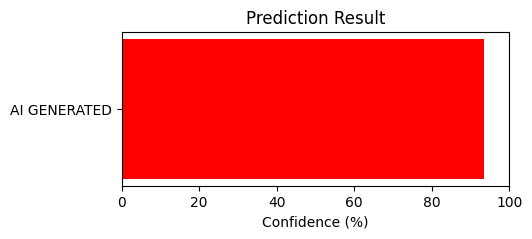

File: E035-002.png
Predicted: REAL
Confidence: 87.76 %


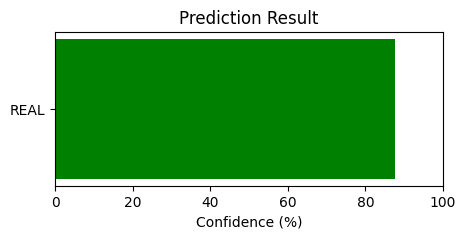

File: E146-014.png
Predicted: REAL
Confidence: 93.93 %


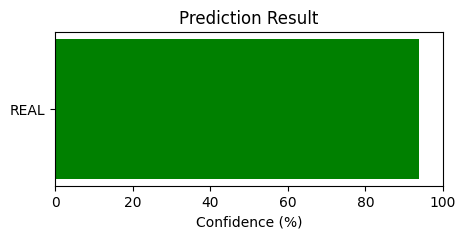

File: F041-019.png
Predicted: EDITED
Confidence: 72.91 %


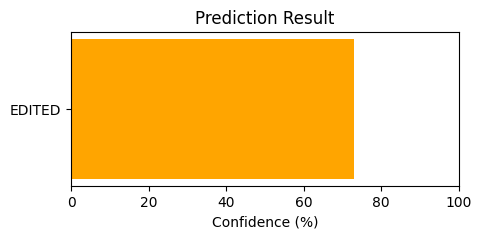

File: E127-113.png
Predicted: AI GENERATED
Confidence: 51.82 %


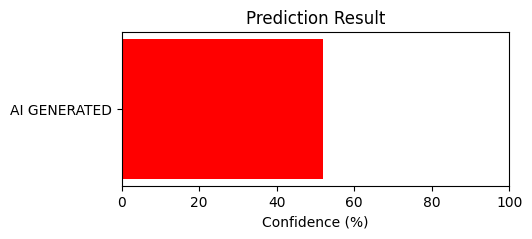

File: G001-101.png
Predicted: REAL
Confidence: 82.77 %


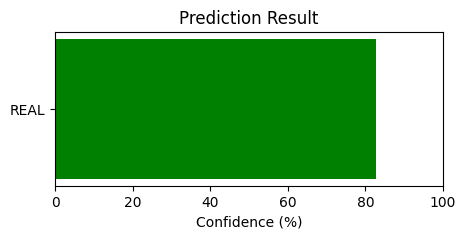

File: F014-310.png
Predicted: REAL
Confidence: 99.99 %


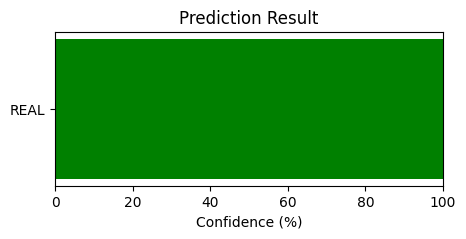

File: F019-037.png
Predicted: AI GENERATED
Confidence: 47.36 %


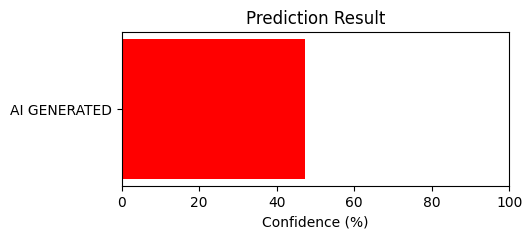

File: F011-109.png
Predicted: REAL
Confidence: 97.81 %


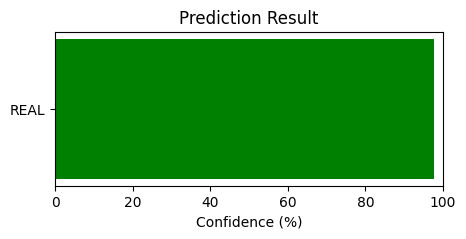

File: F026-002.png
Predicted: REAL
Confidence: 95.45 %


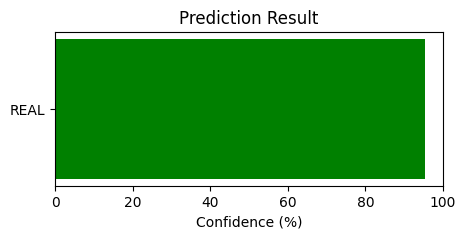

File: G009-227.png
Predicted: AI GENERATED
Confidence: 70.85 %


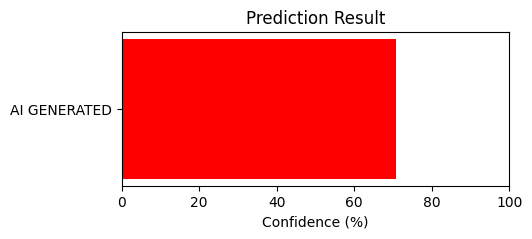

File: F030-024.png
Predicted: AI GENERATED
Confidence: 81.72 %


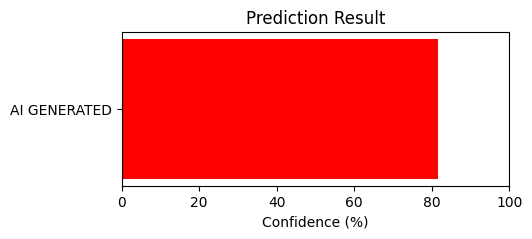

File: F013-030.png
Predicted: REAL
Confidence: 89.63 %


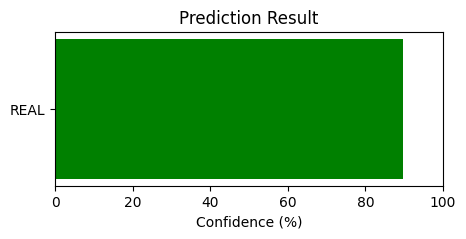

File: E034-008.png
Predicted: REAL
Confidence: 55.58 %


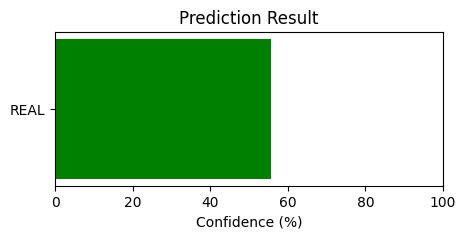

File: F054-005.png
Predicted: REAL
Confidence: 99.36 %


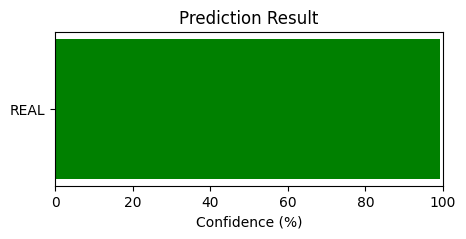

File: F004-022.png
Predicted: REAL
Confidence: 50.37 %


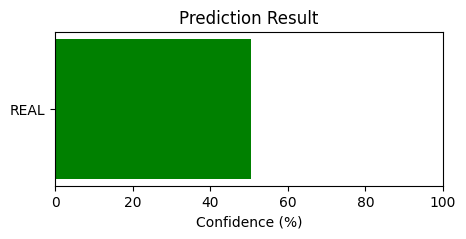

File: F020-208.png
Predicted: AI GENERATED
Confidence: 86.3 %


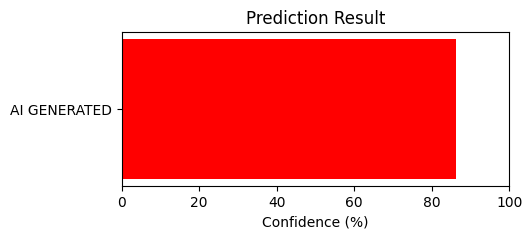

File: G005-028.png
Predicted: REAL
Confidence: 98.99 %


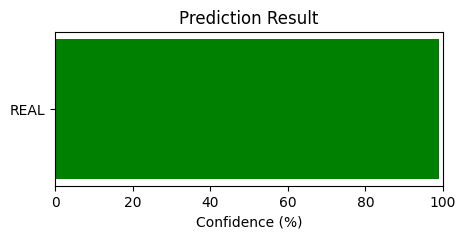

File: E039-002.png
Predicted: EDITED
Confidence: 97.43 %


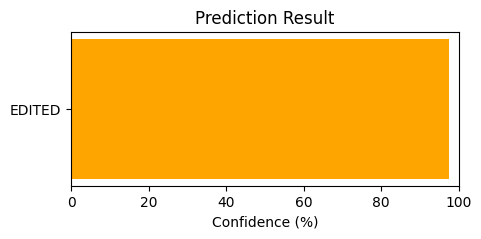

File: F025-045.png
Predicted: REAL
Confidence: 99.99 %


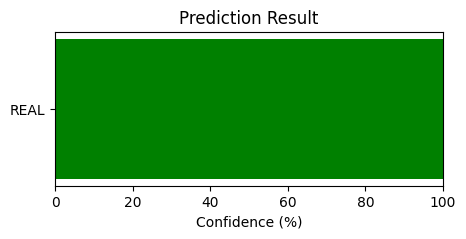

File: F048-048.png
Predicted: REAL
Confidence: 66.04 %


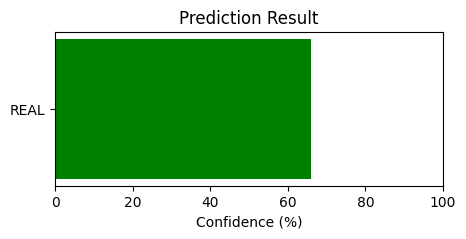

File: G015-110.png
Predicted: EDITED
Confidence: 90.54 %


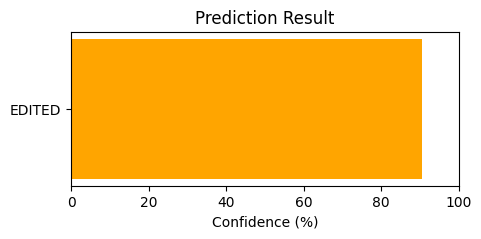

File: F022-137.png
Predicted: REAL
Confidence: 99.27 %


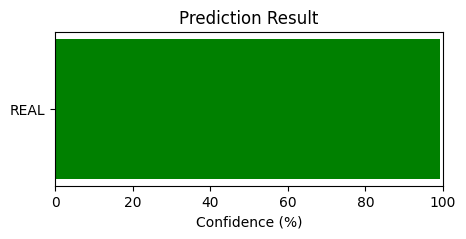

File: E145-014.png
Predicted: EDITED
Confidence: 81.3 %


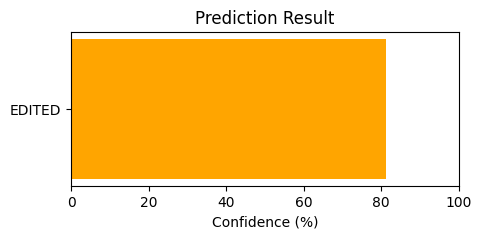

File: F036-121.png
Predicted: REAL
Confidence: 99.47 %


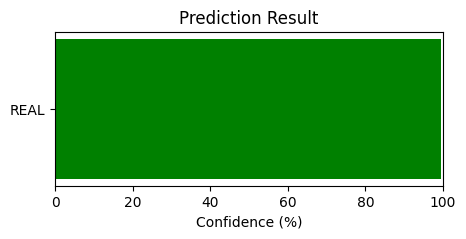

File: G019-009.png
Predicted: REAL
Confidence: 99.92 %


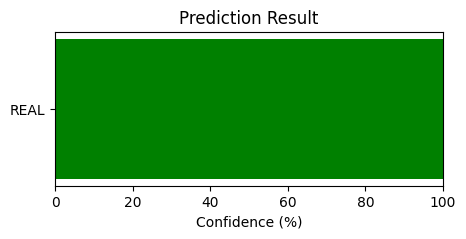

File: F018-029.png
Predicted: AI GENERATED
Confidence: 93.39 %


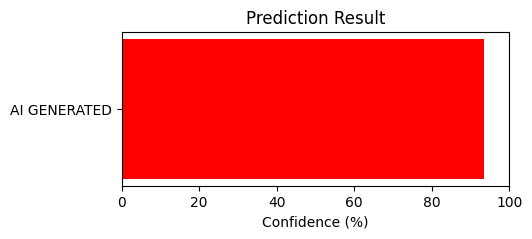

File: G017-013.png
Predicted: REAL
Confidence: 91.25 %


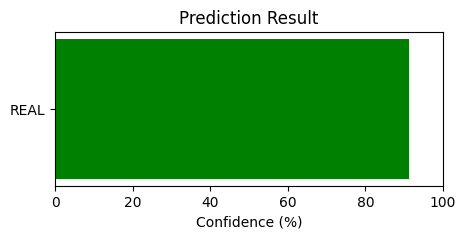

File: E075-004.png
Predicted: REAL
Confidence: 58.64 %


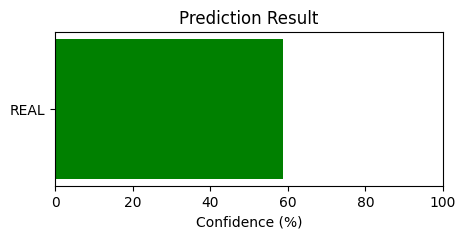

File: F033-430.png
Predicted: AI GENERATED
Confidence: 67.78 %


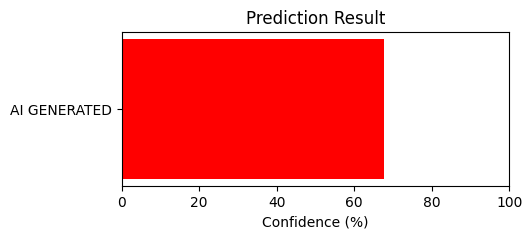

File: F050-056.png
Predicted: AI GENERATED
Confidence: 68.13 %


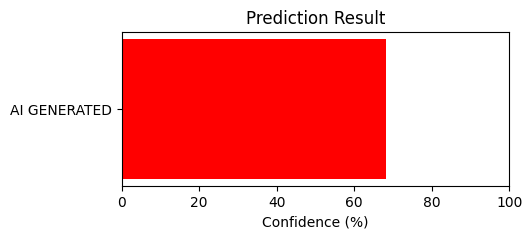

File: H022-144.png
Predicted: AI GENERATED
Confidence: 72.74 %


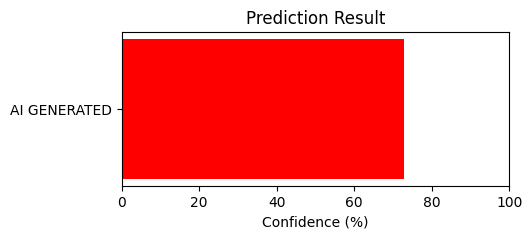

File: G021-111.png
Predicted: REAL
Confidence: 99.83 %


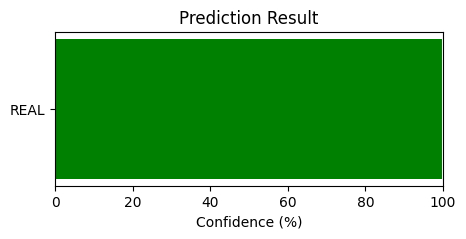

File: G029-038.png
Predicted: REAL
Confidence: 53.84 %


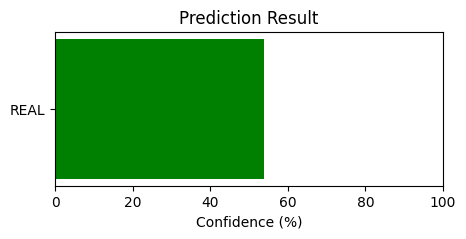

File: G040-445.png
Predicted: REAL
Confidence: 99.54 %


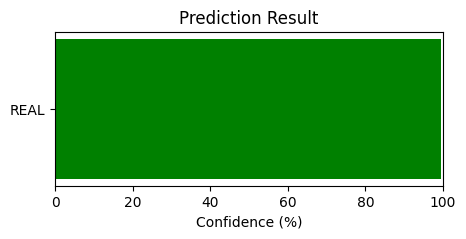

File: H013-115.png
Predicted: EDITED
Confidence: 88.43 %


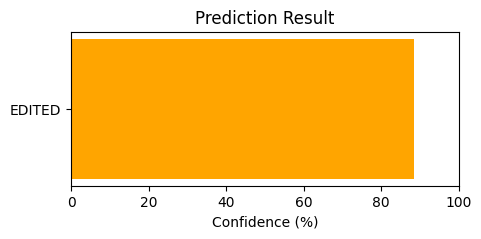

File: G048-008.png
Predicted: EDITED
Confidence: 83.43 %


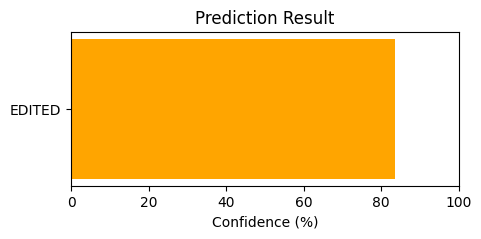

File: H031-028.png
Predicted: REAL
Confidence: 92.27 %


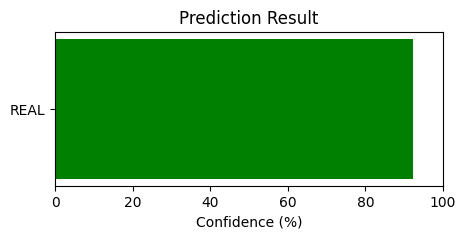

File: G052-133.png
Predicted: EDITED
Confidence: 97.21 %


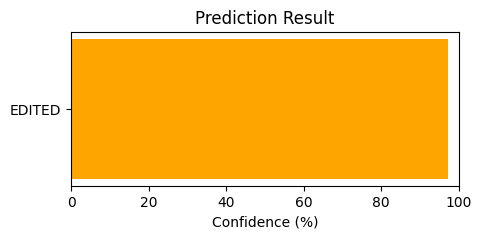

File: G042-129.png
Predicted: REAL
Confidence: 100.0 %


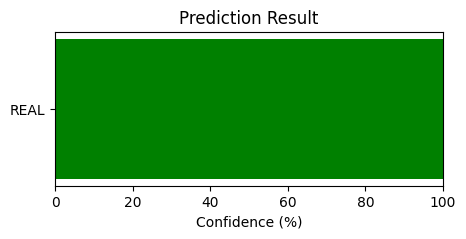

File: H018-037.png
Predicted: AI GENERATED
Confidence: 73.86 %


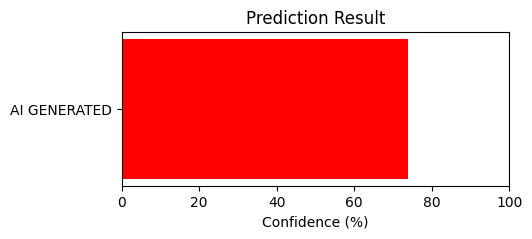

File: H035-013.png
Predicted: AI GENERATED
Confidence: 55.07 %


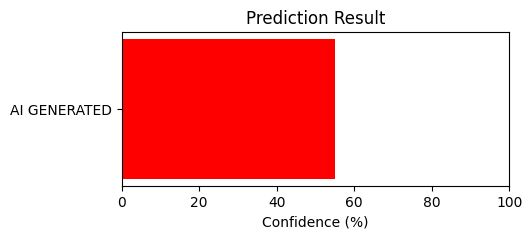

File: H027-015.png
Predicted: REAL
Confidence: 95.35 %


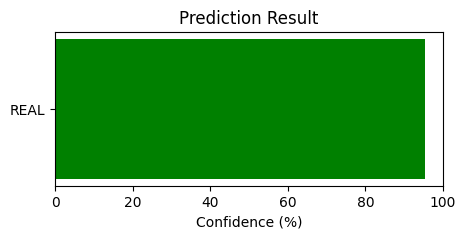

File: H043-140.png
Predicted: REAL
Confidence: 99.99 %


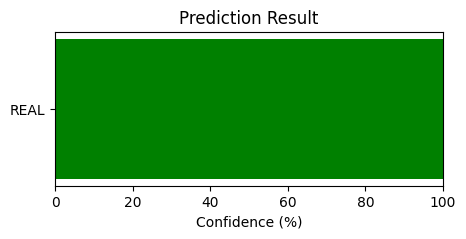

File: H026-018.png
Predicted: EDITED
Confidence: 92.66 %


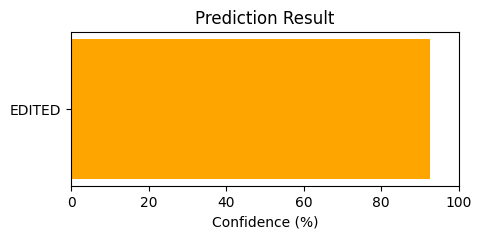

File: H049-208.png
Predicted: REAL
Confidence: 99.71 %


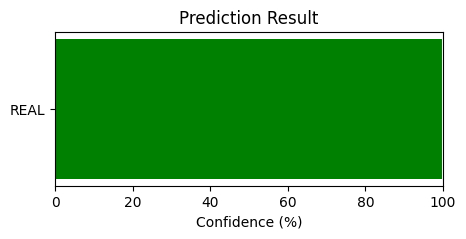

File: H023-301.png
Predicted: REAL
Confidence: 96.38 %


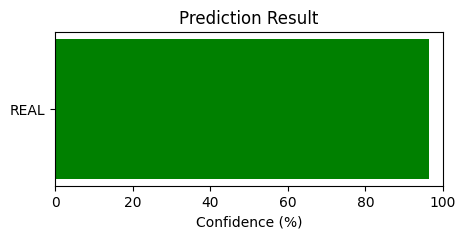

File: H011-037.png
Predicted: REAL
Confidence: 79.63 %


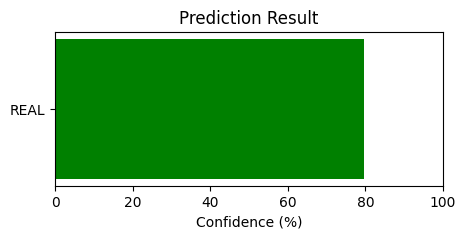

File: H008-146.png
Predicted: REAL
Confidence: 100.0 %


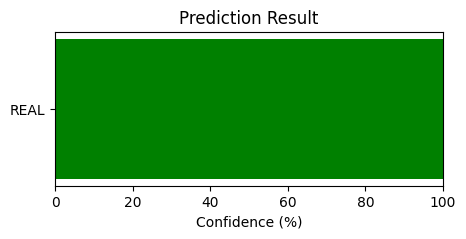

File: H042-138.png
Predicted: REAL
Confidence: 99.84 %


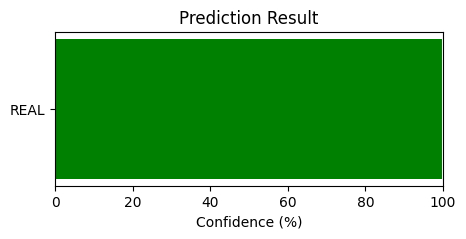

File: H014-005.png
Predicted: AI GENERATED
Confidence: 55.36 %


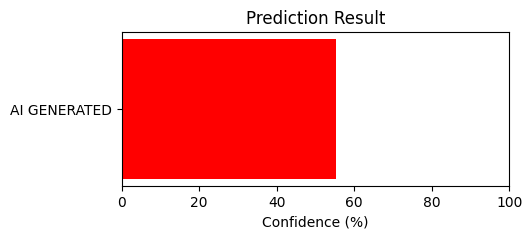

File: H048-206.png
Predicted: REAL
Confidence: 99.28 %


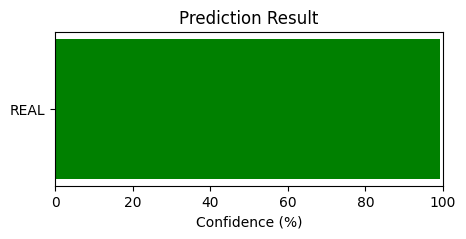

File: H036-022.png
Predicted: REAL
Confidence: 99.71 %


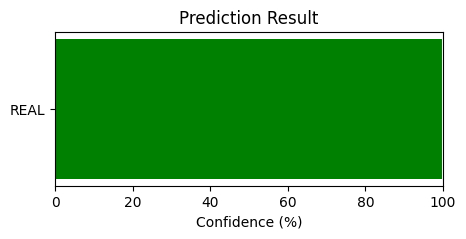

File: G044-612.png
Predicted: EDITED
Confidence: 88.4 %


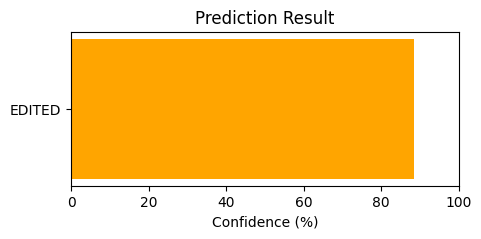

File: H010-113.png
Predicted: REAL
Confidence: 92.39 %


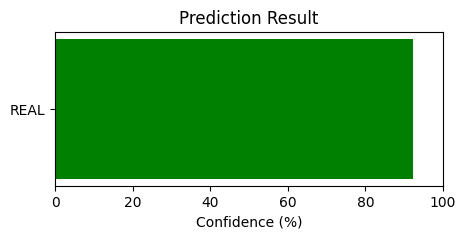

File: H040-008.png
Predicted: AI GENERATED
Confidence: 92.25 %


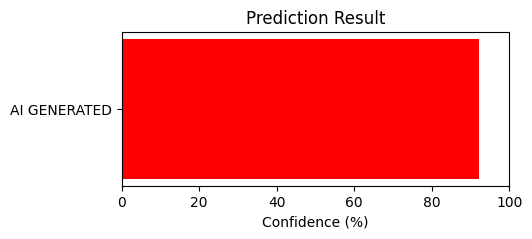

File: H024-023.png
Predicted: REAL
Confidence: 95.64 %


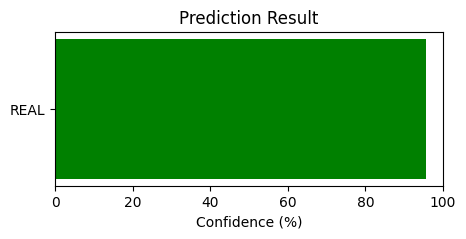

File: H028-123.png
Predicted: REAL
Confidence: 93.4 %


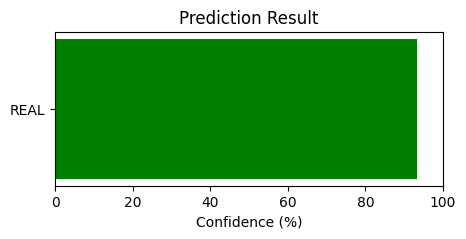

File: H017-011.png
Predicted: REAL
Confidence: 99.33 %


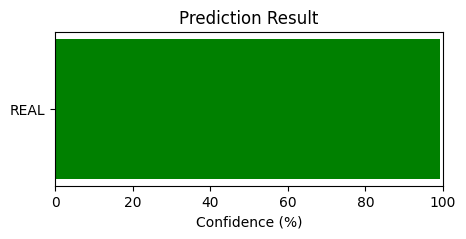

File: H015-113.png
Predicted: EDITED
Confidence: 49.93 %


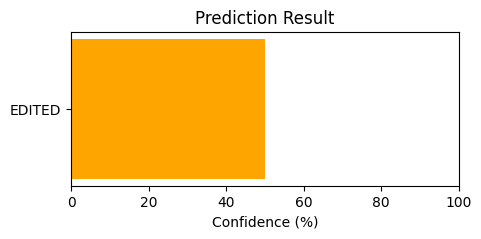

File: H033-019.png
Predicted: AI GENERATED
Confidence: 70.73 %


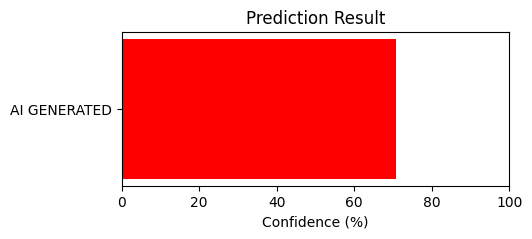

File: H020-018.png
Predicted: EDITED
Confidence: 49.82 %


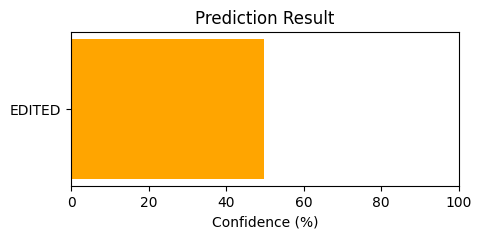

File: G031-007.png
Predicted: REAL
Confidence: 99.98 %


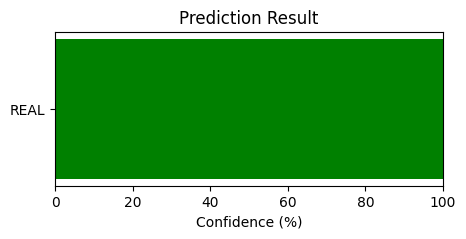

File: G049-036.png
Predicted: REAL
Confidence: 96.08 %


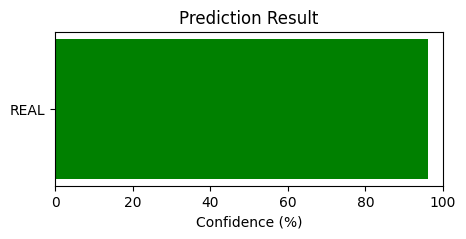

File: H034-044.png
Predicted: EDITED
Confidence: 77.31 %


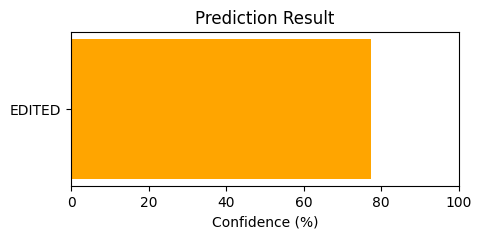

File: H001-042.png
Predicted: REAL
Confidence: 95.8 %


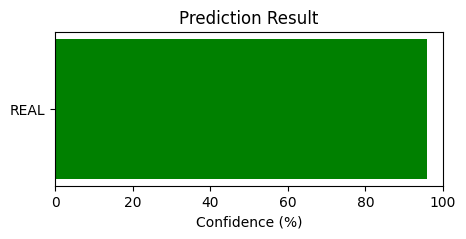

File: H012-020.png
Predicted: REAL
Confidence: 85.2 %


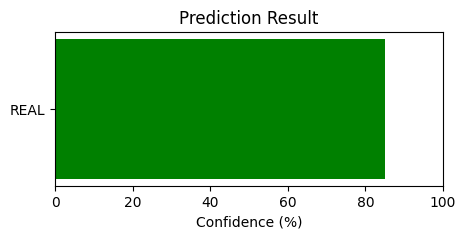

In [30]:
for true_class, folder in folders.items():

    print("\n==============================")
    print("ACTUAL CATEGORY:", true_class)
    print("==============================\n")

    images = os.listdir(folder)

    for img_name in images:

        img_path = os.path.join(folder, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        label, confidence = predict_image(img)

        print("File:", img_name)
        print("Predicted:", label)
        print("Confidence:", round(confidence, 2), "%")

        show_bar(label, confidence)